In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import MNIST
from torchvision import transforms
from scipy.stats import wasserstein_distance
import torchvision

In [2]:
# 设置随机种子以获得可重复结果
torch.manual_seed(42)
np.random.seed(42)

# 检查GPU可用性
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 加载MNIST数据集
transform = transforms.Compose([
    transforms.ToTensor(),
])

# 加载训练和测试数据
train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# 创建数据加载器
train_loader = DataLoader(train_dataset, batch_size=60, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=60, shuffle=False)

Using device: cuda:0


Training data shapes: X=torch.Size([10000, 1, 28, 28]), y=torch.Size([10000])
Testing data shapes: X=torch.Size([60, 1, 28, 28]), y=torch.Size([60])


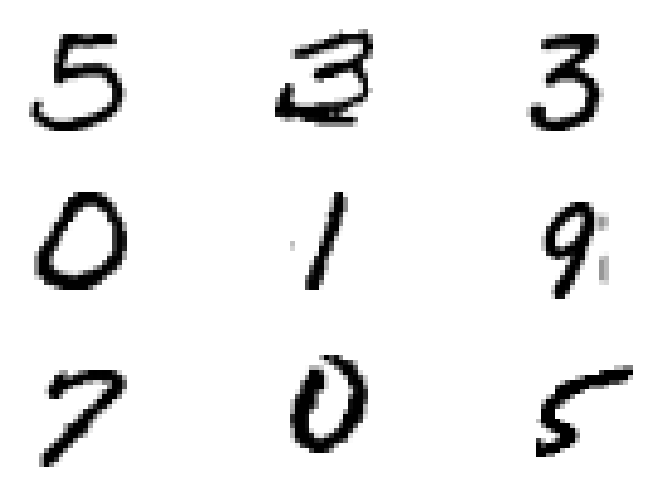

In [3]:
# 获取一些样本数据以进行可视化
trainX = []
trainY = []

for images, labels in train_loader:
    trainX.append(images)
    trainY.append(labels)
    if len(trainX) * images.shape[0] >= 10000:  # 只取前10000个图像
        break

trainX = torch.cat(trainX, dim=0)[:10000]  # 取前10000个图像
trainY = torch.cat(trainY, dim=0)[:10000]  # 取前10000个标签

print('Training data shapes: X=%s, y=%s' % (trainX.shape, trainY.shape))
testX = next(iter(test_loader))[0]
testY = next(iter(test_loader))[1]
print('Testing data shapes: X=%s, y=%s' % (testX.shape, testY.shape))

# 可视化一些训练图像
for k in range(1):  # 只显示一组图像，避免显示过多
    plt.figure(figsize=(9, 6))
    for j in range(9):
        i = np.random.randint(0, 10000)
        plt.subplot(3, 3, j+1)
        plt.imshow(trainX[i][0], cmap='gray_r')  # 索引[0]获取通道维度
        plt.axis('off')
    plt.show()


In [4]:
# 定义生成器网络
class Generator(nn.Module):
    def __init__(self, noise_size=2):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(noise_size, 64),
            nn.ReLU(True),
            nn.Linear(64, 28*28),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        x = self.main(x)
        return x.view(-1, 1, 28, 28)  # 调整形状为 (batch_size, 1, 28, 28)

# 定义判别器网络
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 64),
            nn.ReLU(True),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.main(x)

In [5]:
# 初始化网络
generator = Generator(noise_size=2).to(device)
discriminator = Discriminator().to(device)

# 打印网络结构
print(generator)
print(discriminator)

# 定义损失函数和优化器
criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.0001, betas=(0.5, 0.999))
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

# 生成随机噪声
def get_random_noise(batch_size, noise_size):
    return torch.randn(batch_size, noise_size, device=device)

# 获取假样本
def get_fake_samples(generator, batch_size, noise_size, noise_std):
    with torch.no_grad():
        random_noise_batch = get_random_noise(batch_size, noise_size)
        noise = torch.normal(0, noise_std, size=random_noise_batch.shape).to(device)
        noisy_noise_batch = random_noise_batch + noise
        fake_samples = generator(noisy_noise_batch)
    return fake_samples

# 获取真实样本
def get_real_samples(batch_size):
    random_indices = np.random.choice(range(len(trainX)), size=batch_size)
    real_images = trainX[random_indices].to(device)
    return real_images

# 展示生成器结果
def show_generator_results(generator, noise_std):
    generator.eval()  # 设置为评估模式
    fake_samples = get_fake_samples(generator, 9, 2, noise_std)
    plt.figure(figsize=(9, 6))
    for j in range(9):
        plt.subplot(3, 3, j+1)
        plt.imshow(fake_samples[j, 0].cpu().numpy(), cmap='gray_r')
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    generator.train()  # 恢复训练模式

Generator(
  (main): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=784, bias=True)
    (3): Sigmoid()
  )
)
Discriminator(
  (main): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=64, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


In [6]:
# 训练参数
epochs = 500
batch_size = 60
steps = 50  # 在每个epoch中的训练步数
noise_size = 2
noise_std = 0.05
noise_std_min = 0.01
noise_std_max = 0.2
noise_increase_factor = 1.05
noise_decrease_factor = 0.95
noise_change_threshold = 1e-3



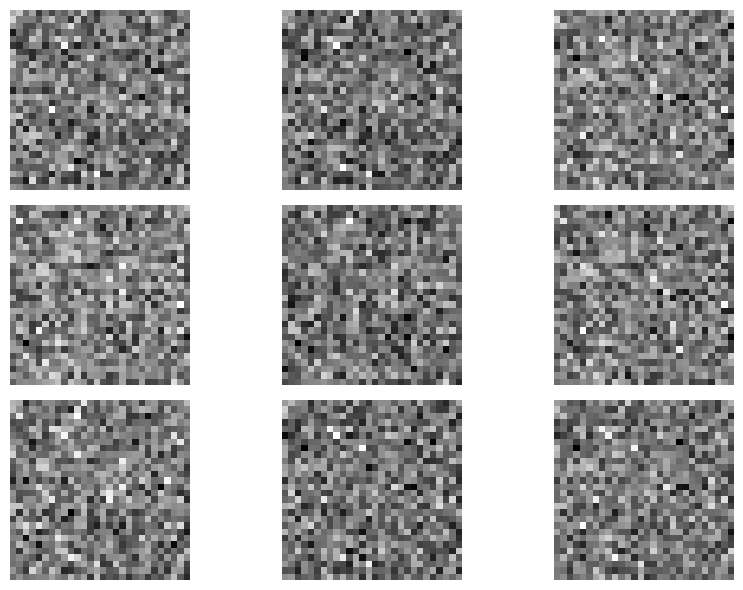

Epoch:0, Step:0, D-Loss:1.454, D-Acc:50.000, G-Loss:0.622, Wasserstein Dist:0.443
Epoch:0, Step:10, D-Loss:1.161, D-Acc:100.000, G-Loss:0.940, Wasserstein Dist:0.443
Epoch:0, Step:20, D-Loss:1.015, D-Acc:100.000, G-Loss:1.089, Wasserstein Dist:0.442
Epoch:0, Step:30, D-Loss:0.893, D-Acc:100.000, G-Loss:1.222, Wasserstein Dist:0.442
Epoch:0, Step:40, D-Loss:0.771, D-Acc:100.000, G-Loss:1.352, Wasserstein Dist:0.439
Epoch:1, Step:0, D-Loss:0.655, D-Acc:100.000, G-Loss:1.481, Wasserstein Dist:0.436
Epoch:1, Step:10, D-Loss:0.563, D-Acc:100.000, G-Loss:1.608, Wasserstein Dist:0.434
Epoch:1, Step:20, D-Loss:0.522, D-Acc:100.000, G-Loss:1.748, Wasserstein Dist:0.431
Epoch:1, Step:30, D-Loss:0.422, D-Acc:100.000, G-Loss:1.856, Wasserstein Dist:0.427
Epoch:1, Step:40, D-Loss:0.398, D-Acc:100.000, G-Loss:1.974, Wasserstein Dist:0.423
Epoch:2, Step:0, D-Loss:0.354, D-Acc:100.000, G-Loss:2.075, Wasserstein Dist:0.421
Epoch:2, Step:10, D-Loss:0.306, D-Acc:100.000, G-Loss:2.146, Wasserstein Dist:0.

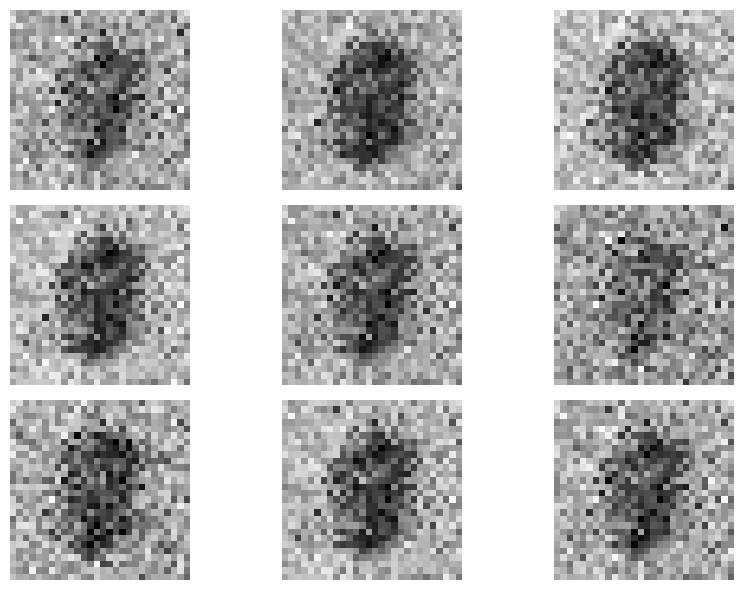

Epoch:5, Step:0, D-Loss:0.160, D-Acc:98.333, G-Loss:3.115, Wasserstein Dist:0.341
Epoch:5, Step:10, D-Loss:0.163, D-Acc:100.000, G-Loss:3.371, Wasserstein Dist:0.338
Epoch:5, Step:20, D-Loss:0.173, D-Acc:98.333, G-Loss:3.302, Wasserstein Dist:0.332
Epoch:5, Step:30, D-Loss:0.217, D-Acc:98.333, G-Loss:3.343, Wasserstein Dist:0.325
Epoch:5, Step:40, D-Loss:0.245, D-Acc:96.667, G-Loss:3.452, Wasserstein Dist:0.322
Epoch:6, Step:0, D-Loss:0.232, D-Acc:98.333, G-Loss:3.497, Wasserstein Dist:0.316
Epoch:6, Step:10, D-Loss:0.224, D-Acc:96.667, G-Loss:3.581, Wasserstein Dist:0.310
Epoch:6, Step:20, D-Loss:0.161, D-Acc:98.333, G-Loss:3.361, Wasserstein Dist:0.305
Epoch:6, Step:30, D-Loss:0.263, D-Acc:95.000, G-Loss:3.796, Wasserstein Dist:0.298
Epoch:6, Step:40, D-Loss:0.225, D-Acc:96.667, G-Loss:3.865, Wasserstein Dist:0.294
Epoch:7, Step:0, D-Loss:0.282, D-Acc:96.667, G-Loss:3.593, Wasserstein Dist:0.290
Epoch:7, Step:10, D-Loss:0.234, D-Acc:96.667, G-Loss:3.874, Wasserstein Dist:0.285
Epoch:

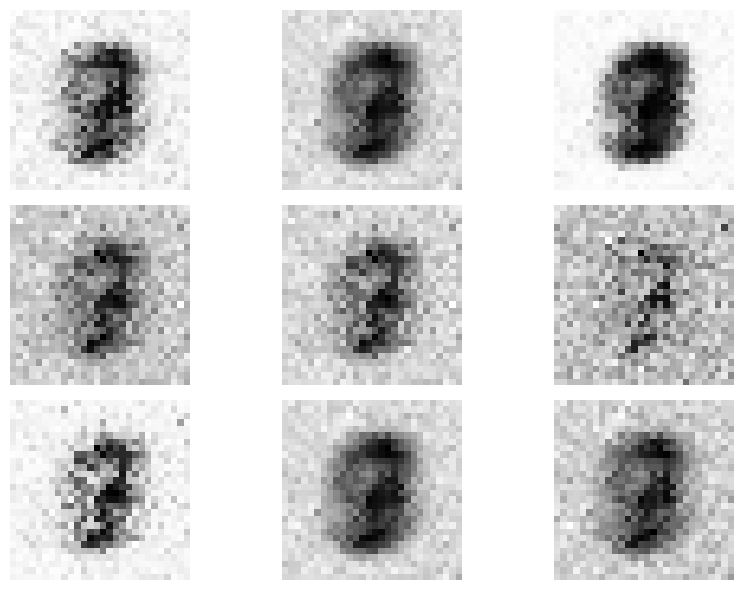

Epoch:10, Step:0, D-Loss:0.304, D-Acc:96.667, G-Loss:3.565, Wasserstein Dist:0.235
Epoch:10, Step:10, D-Loss:0.304, D-Acc:96.667, G-Loss:3.592, Wasserstein Dist:0.226
Epoch:10, Step:20, D-Loss:0.383, D-Acc:96.667, G-Loss:4.106, Wasserstein Dist:0.224
Epoch:10, Step:30, D-Loss:0.451, D-Acc:91.667, G-Loss:3.778, Wasserstein Dist:0.222
Epoch:10, Step:40, D-Loss:0.420, D-Acc:93.333, G-Loss:4.066, Wasserstein Dist:0.219
Epoch:11, Step:0, D-Loss:0.237, D-Acc:98.333, G-Loss:3.393, Wasserstein Dist:0.214
Epoch:11, Step:10, D-Loss:0.417, D-Acc:93.333, G-Loss:3.773, Wasserstein Dist:0.208
Epoch:11, Step:20, D-Loss:0.557, D-Acc:90.000, G-Loss:3.911, Wasserstein Dist:0.210
Epoch:11, Step:30, D-Loss:0.367, D-Acc:96.667, G-Loss:3.836, Wasserstein Dist:0.207
Epoch:11, Step:40, D-Loss:0.660, D-Acc:90.000, G-Loss:3.492, Wasserstein Dist:0.205
Epoch:12, Step:0, D-Loss:0.441, D-Acc:93.333, G-Loss:3.636, Wasserstein Dist:0.204
Epoch:12, Step:10, D-Loss:0.825, D-Acc:83.333, G-Loss:3.136, Wasserstein Dist:0

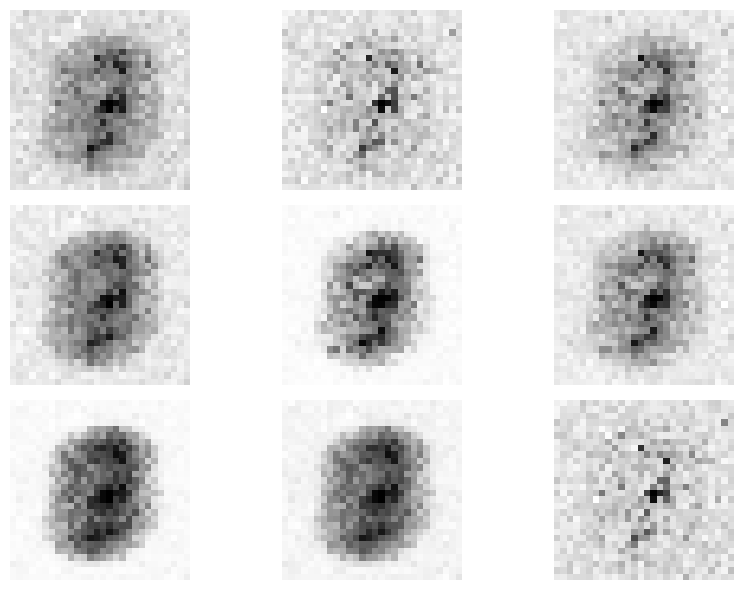

Epoch:15, Step:0, D-Loss:0.464, D-Acc:93.333, G-Loss:3.162, Wasserstein Dist:0.175
Epoch:15, Step:10, D-Loss:0.414, D-Acc:95.000, G-Loss:3.353, Wasserstein Dist:0.171
Epoch:15, Step:20, D-Loss:0.418, D-Acc:96.667, G-Loss:2.944, Wasserstein Dist:0.168
Epoch:15, Step:30, D-Loss:0.472, D-Acc:93.333, G-Loss:3.005, Wasserstein Dist:0.168
Epoch:15, Step:40, D-Loss:0.493, D-Acc:93.333, G-Loss:3.485, Wasserstein Dist:0.167
Epoch:16, Step:0, D-Loss:0.481, D-Acc:95.000, G-Loss:2.911, Wasserstein Dist:0.167
Epoch:16, Step:10, D-Loss:0.493, D-Acc:93.333, G-Loss:3.093, Wasserstein Dist:0.164
Epoch:16, Step:20, D-Loss:0.465, D-Acc:93.333, G-Loss:2.997, Wasserstein Dist:0.163
Epoch:16, Step:30, D-Loss:0.512, D-Acc:95.000, G-Loss:2.739, Wasserstein Dist:0.161
Epoch:16, Step:40, D-Loss:0.445, D-Acc:93.333, G-Loss:3.046, Wasserstein Dist:0.163
Epoch:17, Step:0, D-Loss:0.511, D-Acc:93.333, G-Loss:3.218, Wasserstein Dist:0.161
Epoch:17, Step:10, D-Loss:0.453, D-Acc:95.000, G-Loss:3.040, Wasserstein Dist:0

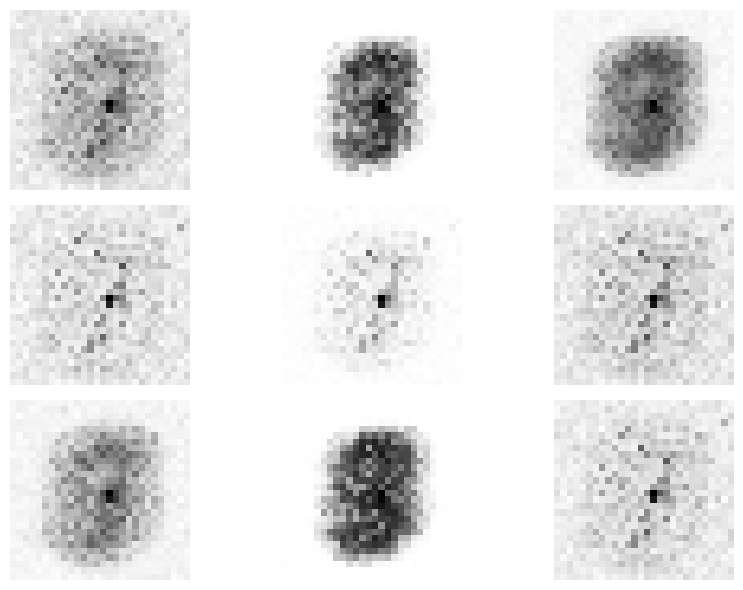

Epoch:20, Step:0, D-Loss:0.869, D-Acc:81.667, G-Loss:2.762, Wasserstein Dist:0.141
Epoch:20, Step:10, D-Loss:0.692, D-Acc:83.333, G-Loss:2.757, Wasserstein Dist:0.139
Epoch:20, Step:20, D-Loss:0.652, D-Acc:86.667, G-Loss:2.519, Wasserstein Dist:0.139
Epoch:20, Step:30, D-Loss:0.537, D-Acc:93.333, G-Loss:3.046, Wasserstein Dist:0.137
Epoch:20, Step:40, D-Loss:0.651, D-Acc:86.667, G-Loss:2.712, Wasserstein Dist:0.135
Epoch:21, Step:0, D-Loss:0.499, D-Acc:93.333, G-Loss:2.297, Wasserstein Dist:0.134
Epoch:21, Step:10, D-Loss:0.627, D-Acc:86.667, G-Loss:2.336, Wasserstein Dist:0.137
Epoch:21, Step:20, D-Loss:0.519, D-Acc:90.000, G-Loss:2.385, Wasserstein Dist:0.135
Epoch:21, Step:30, D-Loss:0.727, D-Acc:85.000, G-Loss:2.726, Wasserstein Dist:0.136
Epoch:21, Step:40, D-Loss:0.473, D-Acc:93.333, G-Loss:2.275, Wasserstein Dist:0.134
Epoch:22, Step:0, D-Loss:0.628, D-Acc:88.333, G-Loss:2.113, Wasserstein Dist:0.131
Epoch:22, Step:10, D-Loss:0.680, D-Acc:85.000, G-Loss:2.169, Wasserstein Dist:0

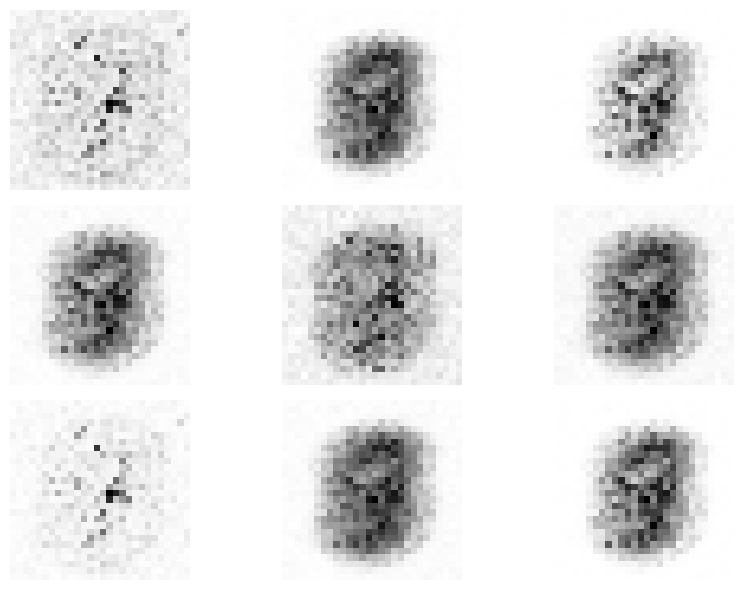

Epoch:25, Step:0, D-Loss:0.684, D-Acc:85.000, G-Loss:1.913, Wasserstein Dist:0.121
Epoch:25, Step:10, D-Loss:0.640, D-Acc:85.000, G-Loss:1.699, Wasserstein Dist:0.121
Epoch:25, Step:20, D-Loss:0.655, D-Acc:90.000, G-Loss:2.001, Wasserstein Dist:0.119
Epoch:25, Step:30, D-Loss:0.792, D-Acc:80.000, G-Loss:1.894, Wasserstein Dist:0.121
Epoch:25, Step:40, D-Loss:0.699, D-Acc:81.667, G-Loss:1.869, Wasserstein Dist:0.119
Epoch:26, Step:0, D-Loss:0.553, D-Acc:93.333, G-Loss:2.109, Wasserstein Dist:0.120
Epoch:26, Step:10, D-Loss:0.768, D-Acc:83.333, G-Loss:1.789, Wasserstein Dist:0.120
Epoch:26, Step:20, D-Loss:0.760, D-Acc:81.667, G-Loss:1.799, Wasserstein Dist:0.119
Epoch:26, Step:30, D-Loss:0.625, D-Acc:88.333, G-Loss:1.801, Wasserstein Dist:0.119
Epoch:26, Step:40, D-Loss:0.694, D-Acc:85.000, G-Loss:1.980, Wasserstein Dist:0.117
Epoch:27, Step:0, D-Loss:0.698, D-Acc:86.667, G-Loss:1.819, Wasserstein Dist:0.117
Epoch:27, Step:10, D-Loss:0.702, D-Acc:86.667, G-Loss:1.776, Wasserstein Dist:0

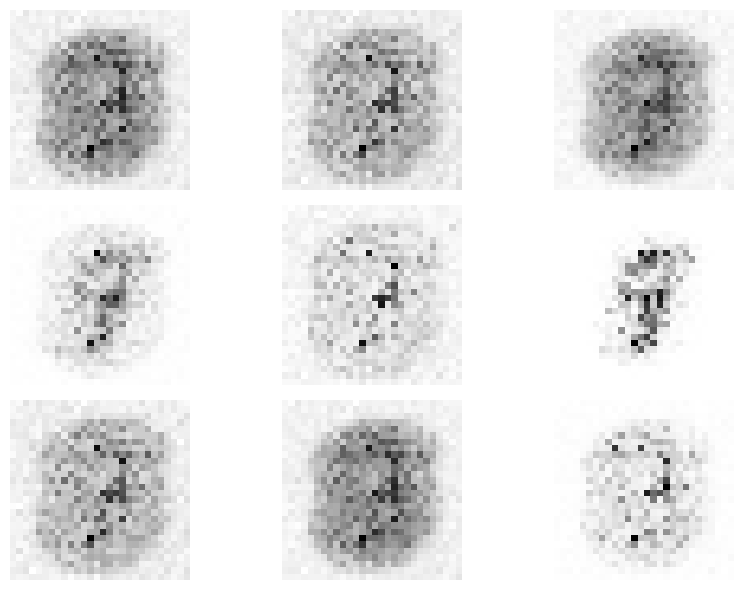

Epoch:30, Step:0, D-Loss:0.653, D-Acc:86.667, G-Loss:1.668, Wasserstein Dist:0.113
Epoch:30, Step:10, D-Loss:0.630, D-Acc:85.000, G-Loss:1.694, Wasserstein Dist:0.112
Epoch:30, Step:20, D-Loss:0.818, D-Acc:81.667, G-Loss:1.820, Wasserstein Dist:0.112
Epoch:30, Step:30, D-Loss:0.821, D-Acc:81.667, G-Loss:1.757, Wasserstein Dist:0.111
Epoch:30, Step:40, D-Loss:0.729, D-Acc:83.333, G-Loss:1.471, Wasserstein Dist:0.112
Epoch:31, Step:0, D-Loss:0.620, D-Acc:85.000, G-Loss:1.343, Wasserstein Dist:0.111
Epoch:31, Step:10, D-Loss:0.741, D-Acc:81.667, G-Loss:1.899, Wasserstein Dist:0.110
Epoch:31, Step:20, D-Loss:0.670, D-Acc:88.333, G-Loss:1.435, Wasserstein Dist:0.110
Epoch:31, Step:30, D-Loss:0.723, D-Acc:83.333, G-Loss:1.645, Wasserstein Dist:0.112
Epoch:31, Step:40, D-Loss:0.701, D-Acc:83.333, G-Loss:1.418, Wasserstein Dist:0.109
Epoch:32, Step:0, D-Loss:0.743, D-Acc:81.667, G-Loss:1.528, Wasserstein Dist:0.112
Epoch:32, Step:10, D-Loss:0.717, D-Acc:85.000, G-Loss:1.513, Wasserstein Dist:0

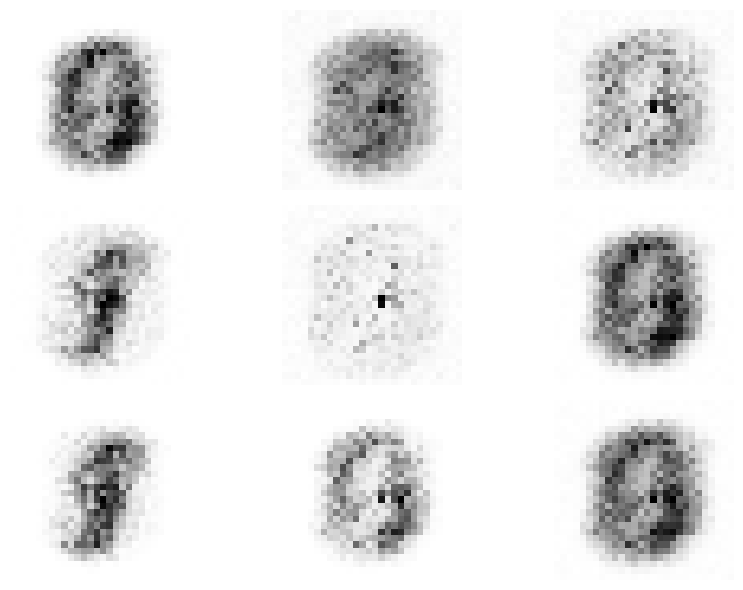

Epoch:35, Step:0, D-Loss:0.788, D-Acc:81.667, G-Loss:1.318, Wasserstein Dist:0.104
Epoch:35, Step:10, D-Loss:0.761, D-Acc:76.667, G-Loss:1.483, Wasserstein Dist:0.103
Epoch:35, Step:20, D-Loss:0.702, D-Acc:88.333, G-Loss:1.578, Wasserstein Dist:0.105
Epoch:35, Step:30, D-Loss:0.714, D-Acc:90.000, G-Loss:1.100, Wasserstein Dist:0.102
Epoch:35, Step:40, D-Loss:0.768, D-Acc:86.667, G-Loss:1.335, Wasserstein Dist:0.101
Epoch:36, Step:0, D-Loss:0.758, D-Acc:83.333, G-Loss:1.288, Wasserstein Dist:0.102
Epoch:36, Step:10, D-Loss:0.693, D-Acc:85.000, G-Loss:1.416, Wasserstein Dist:0.099
Epoch:36, Step:20, D-Loss:0.851, D-Acc:78.333, G-Loss:1.404, Wasserstein Dist:0.102
Epoch:36, Step:30, D-Loss:0.900, D-Acc:75.000, G-Loss:1.324, Wasserstein Dist:0.100
Epoch:36, Step:40, D-Loss:0.867, D-Acc:76.667, G-Loss:1.463, Wasserstein Dist:0.099
Epoch:37, Step:0, D-Loss:0.677, D-Acc:85.000, G-Loss:1.437, Wasserstein Dist:0.103
Epoch:37, Step:10, D-Loss:0.917, D-Acc:73.333, G-Loss:1.533, Wasserstein Dist:0

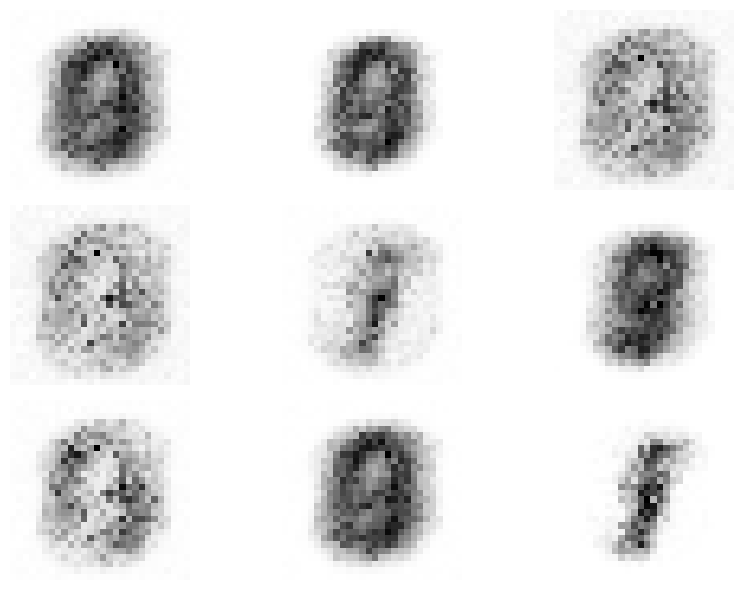

Epoch:40, Step:0, D-Loss:0.761, D-Acc:86.667, G-Loss:1.307, Wasserstein Dist:0.097
Epoch:40, Step:10, D-Loss:0.814, D-Acc:81.667, G-Loss:1.199, Wasserstein Dist:0.096
Epoch:40, Step:20, D-Loss:0.631, D-Acc:93.333, G-Loss:1.131, Wasserstein Dist:0.096
Epoch:40, Step:30, D-Loss:0.781, D-Acc:88.333, G-Loss:1.107, Wasserstein Dist:0.097
Epoch:40, Step:40, D-Loss:0.896, D-Acc:71.667, G-Loss:1.126, Wasserstein Dist:0.095
Epoch:41, Step:0, D-Loss:0.809, D-Acc:76.667, G-Loss:1.334, Wasserstein Dist:0.093
Epoch:41, Step:10, D-Loss:0.686, D-Acc:85.000, G-Loss:1.190, Wasserstein Dist:0.097
Epoch:41, Step:20, D-Loss:0.849, D-Acc:86.667, G-Loss:1.328, Wasserstein Dist:0.094
Epoch:41, Step:30, D-Loss:0.807, D-Acc:80.000, G-Loss:1.219, Wasserstein Dist:0.095
Epoch:41, Step:40, D-Loss:0.822, D-Acc:90.000, G-Loss:1.128, Wasserstein Dist:0.091
Epoch:42, Step:0, D-Loss:0.741, D-Acc:88.333, G-Loss:1.261, Wasserstein Dist:0.094
Epoch:42, Step:10, D-Loss:0.802, D-Acc:86.667, G-Loss:1.193, Wasserstein Dist:0

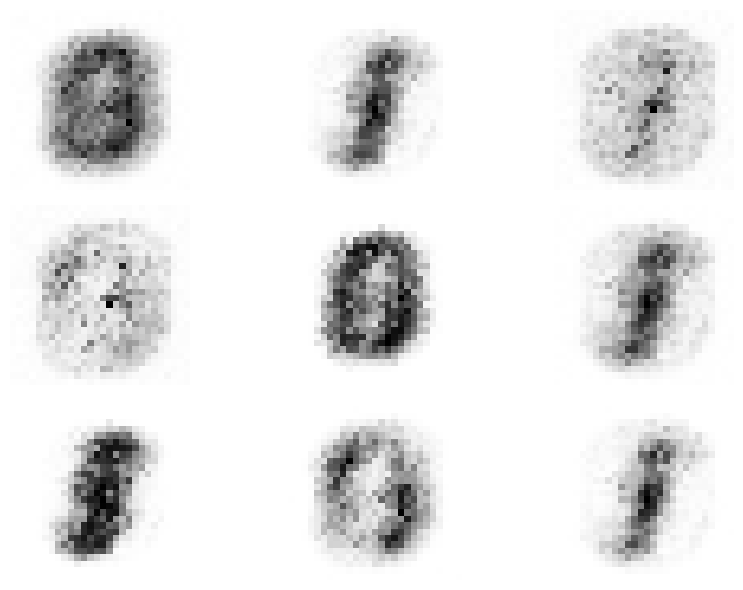

Epoch:45, Step:0, D-Loss:0.741, D-Acc:93.333, G-Loss:1.076, Wasserstein Dist:0.087
Epoch:45, Step:10, D-Loss:0.699, D-Acc:91.667, G-Loss:0.967, Wasserstein Dist:0.089
Epoch:45, Step:20, D-Loss:0.775, D-Acc:86.667, G-Loss:1.247, Wasserstein Dist:0.088
Epoch:45, Step:30, D-Loss:0.792, D-Acc:91.667, G-Loss:1.042, Wasserstein Dist:0.087
Epoch:45, Step:40, D-Loss:0.625, D-Acc:91.667, G-Loss:1.204, Wasserstein Dist:0.086
Epoch:46, Step:0, D-Loss:0.679, D-Acc:95.000, G-Loss:1.103, Wasserstein Dist:0.085
Epoch:46, Step:10, D-Loss:0.755, D-Acc:90.000, G-Loss:1.196, Wasserstein Dist:0.089
Epoch:46, Step:20, D-Loss:0.755, D-Acc:86.667, G-Loss:1.183, Wasserstein Dist:0.088
Epoch:46, Step:30, D-Loss:0.731, D-Acc:90.000, G-Loss:1.074, Wasserstein Dist:0.087
Epoch:46, Step:40, D-Loss:0.705, D-Acc:91.667, G-Loss:1.163, Wasserstein Dist:0.088
Epoch:47, Step:0, D-Loss:0.611, D-Acc:95.000, G-Loss:1.178, Wasserstein Dist:0.085
Epoch:47, Step:10, D-Loss:0.737, D-Acc:95.000, G-Loss:1.186, Wasserstein Dist:0

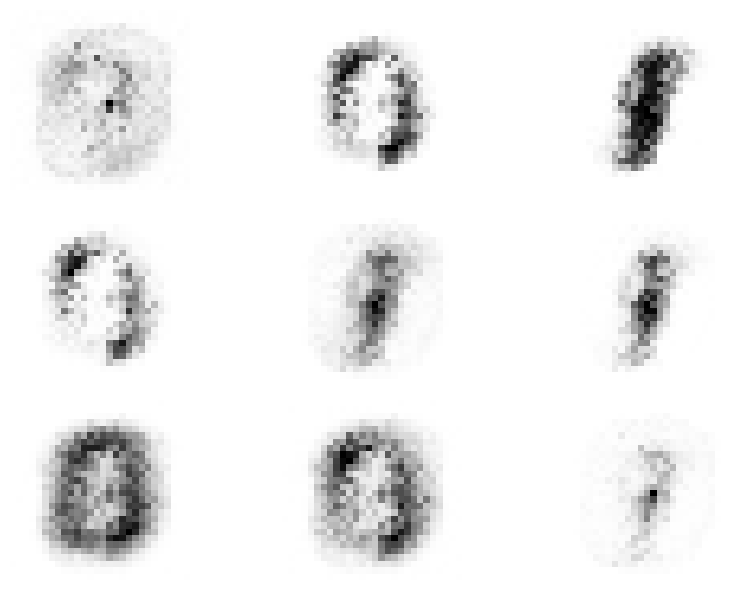

Epoch:50, Step:0, D-Loss:0.808, D-Acc:88.333, G-Loss:1.193, Wasserstein Dist:0.084
Epoch:50, Step:10, D-Loss:0.770, D-Acc:90.000, G-Loss:1.098, Wasserstein Dist:0.082
Epoch:50, Step:20, D-Loss:0.755, D-Acc:93.333, G-Loss:1.270, Wasserstein Dist:0.081
Epoch:50, Step:30, D-Loss:0.795, D-Acc:90.000, G-Loss:1.114, Wasserstein Dist:0.081
Epoch:50, Step:40, D-Loss:0.681, D-Acc:96.667, G-Loss:1.272, Wasserstein Dist:0.082
Epoch:51, Step:0, D-Loss:0.699, D-Acc:91.667, G-Loss:1.209, Wasserstein Dist:0.080
Epoch:51, Step:10, D-Loss:0.702, D-Acc:91.667, G-Loss:1.210, Wasserstein Dist:0.079
Epoch:51, Step:20, D-Loss:0.712, D-Acc:95.000, G-Loss:1.248, Wasserstein Dist:0.082
Epoch:51, Step:30, D-Loss:0.755, D-Acc:96.667, G-Loss:1.065, Wasserstein Dist:0.083
Epoch:51, Step:40, D-Loss:0.789, D-Acc:86.667, G-Loss:1.214, Wasserstein Dist:0.081
Epoch:52, Step:0, D-Loss:0.850, D-Acc:88.333, G-Loss:1.055, Wasserstein Dist:0.082
Epoch:52, Step:10, D-Loss:0.754, D-Acc:93.333, G-Loss:1.213, Wasserstein Dist:0

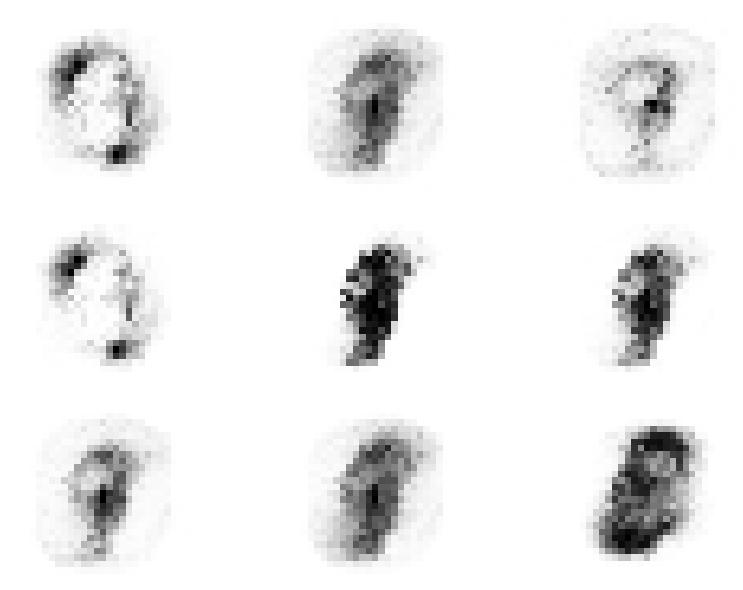

Epoch:55, Step:0, D-Loss:0.740, D-Acc:88.333, G-Loss:1.169, Wasserstein Dist:0.078
Epoch:55, Step:10, D-Loss:0.749, D-Acc:90.000, G-Loss:1.192, Wasserstein Dist:0.079
Epoch:55, Step:20, D-Loss:0.803, D-Acc:90.000, G-Loss:1.102, Wasserstein Dist:0.077
Epoch:55, Step:30, D-Loss:0.747, D-Acc:91.667, G-Loss:1.202, Wasserstein Dist:0.078
Epoch:55, Step:40, D-Loss:0.801, D-Acc:91.667, G-Loss:1.218, Wasserstein Dist:0.078
Epoch:56, Step:0, D-Loss:0.776, D-Acc:91.667, G-Loss:1.175, Wasserstein Dist:0.078
Epoch:56, Step:10, D-Loss:0.699, D-Acc:91.667, G-Loss:1.122, Wasserstein Dist:0.078
Epoch:56, Step:20, D-Loss:0.770, D-Acc:93.333, G-Loss:1.087, Wasserstein Dist:0.078
Epoch:56, Step:30, D-Loss:0.774, D-Acc:91.667, G-Loss:1.226, Wasserstein Dist:0.077
Epoch:56, Step:40, D-Loss:0.718, D-Acc:93.333, G-Loss:1.172, Wasserstein Dist:0.076
Epoch:57, Step:0, D-Loss:0.692, D-Acc:96.667, G-Loss:1.108, Wasserstein Dist:0.075
Epoch:57, Step:10, D-Loss:0.806, D-Acc:88.333, G-Loss:1.190, Wasserstein Dist:0

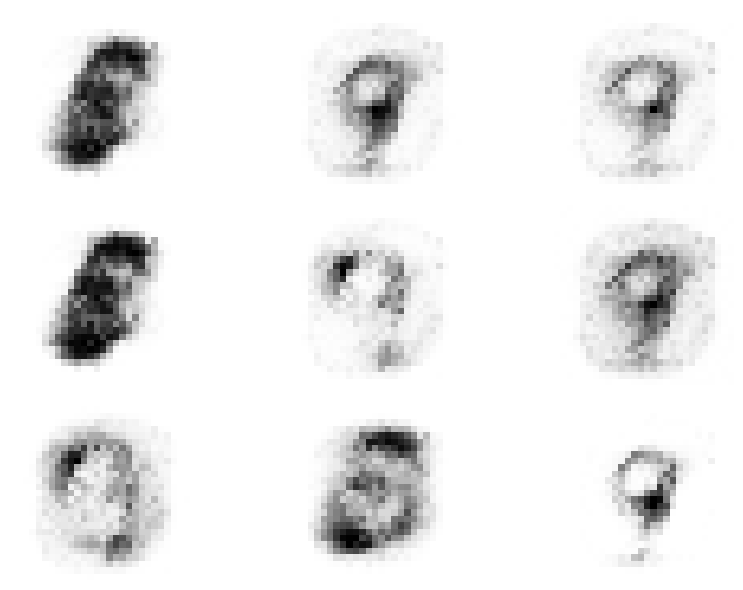

Epoch:60, Step:0, D-Loss:0.707, D-Acc:95.000, G-Loss:1.285, Wasserstein Dist:0.073
Epoch:60, Step:10, D-Loss:0.620, D-Acc:96.667, G-Loss:1.193, Wasserstein Dist:0.075
Epoch:60, Step:20, D-Loss:0.713, D-Acc:93.333, G-Loss:1.256, Wasserstein Dist:0.075
Epoch:60, Step:30, D-Loss:0.718, D-Acc:93.333, G-Loss:1.178, Wasserstein Dist:0.077
Epoch:60, Step:40, D-Loss:0.772, D-Acc:91.667, G-Loss:1.256, Wasserstein Dist:0.075
Epoch:61, Step:0, D-Loss:0.684, D-Acc:95.000, G-Loss:1.203, Wasserstein Dist:0.072
Epoch:61, Step:10, D-Loss:0.660, D-Acc:95.000, G-Loss:1.302, Wasserstein Dist:0.074
Epoch:61, Step:20, D-Loss:0.699, D-Acc:90.000, G-Loss:1.235, Wasserstein Dist:0.076
Epoch:61, Step:30, D-Loss:0.625, D-Acc:96.667, G-Loss:1.236, Wasserstein Dist:0.074
Epoch:61, Step:40, D-Loss:0.617, D-Acc:96.667, G-Loss:1.278, Wasserstein Dist:0.074
Epoch:62, Step:0, D-Loss:0.612, D-Acc:95.000, G-Loss:1.285, Wasserstein Dist:0.074
Epoch:62, Step:10, D-Loss:0.646, D-Acc:96.667, G-Loss:1.239, Wasserstein Dist:0

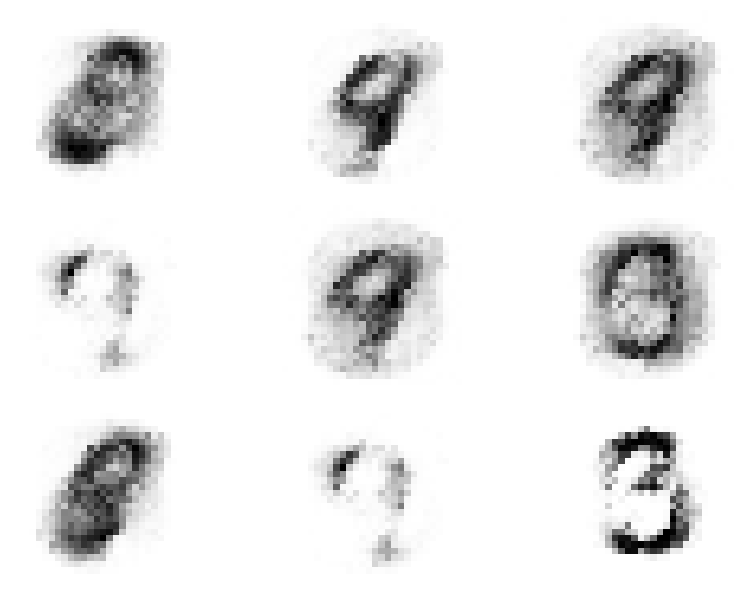

Epoch:65, Step:0, D-Loss:0.563, D-Acc:100.000, G-Loss:1.271, Wasserstein Dist:0.072
Epoch:65, Step:10, D-Loss:0.661, D-Acc:96.667, G-Loss:1.347, Wasserstein Dist:0.071
Epoch:65, Step:20, D-Loss:0.616, D-Acc:96.667, G-Loss:1.221, Wasserstein Dist:0.073
Epoch:65, Step:30, D-Loss:0.599, D-Acc:96.667, G-Loss:1.347, Wasserstein Dist:0.072
Epoch:65, Step:40, D-Loss:0.557, D-Acc:100.000, G-Loss:1.387, Wasserstein Dist:0.072
Epoch:66, Step:0, D-Loss:0.548, D-Acc:96.667, G-Loss:1.403, Wasserstein Dist:0.072
Epoch:66, Step:10, D-Loss:0.603, D-Acc:95.000, G-Loss:1.400, Wasserstein Dist:0.071
Epoch:66, Step:20, D-Loss:0.567, D-Acc:100.000, G-Loss:1.326, Wasserstein Dist:0.072
Epoch:66, Step:30, D-Loss:0.532, D-Acc:96.667, G-Loss:1.292, Wasserstein Dist:0.073
Epoch:66, Step:40, D-Loss:0.670, D-Acc:91.667, G-Loss:1.317, Wasserstein Dist:0.072
Epoch:67, Step:0, D-Loss:0.612, D-Acc:93.333, G-Loss:1.343, Wasserstein Dist:0.071
Epoch:67, Step:10, D-Loss:0.579, D-Acc:91.667, G-Loss:1.366, Wasserstein Dis

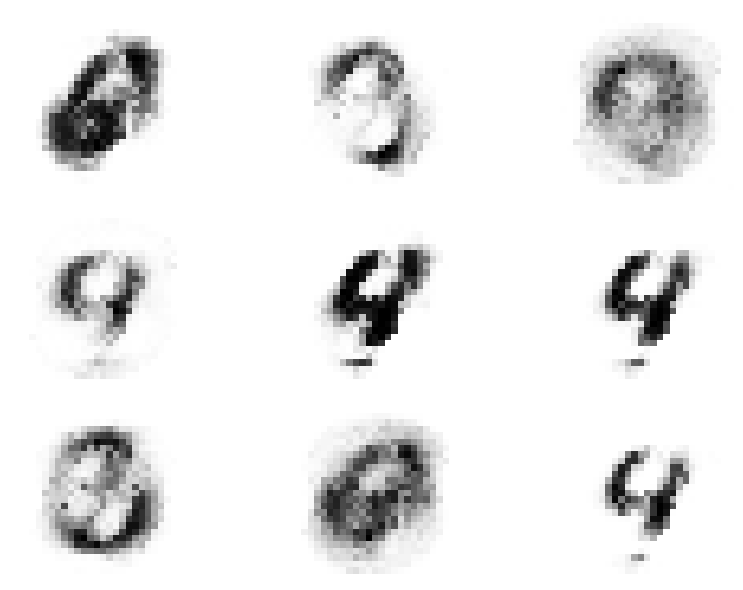

Epoch:70, Step:0, D-Loss:0.560, D-Acc:91.667, G-Loss:1.495, Wasserstein Dist:0.072
Epoch:70, Step:10, D-Loss:0.618, D-Acc:88.333, G-Loss:1.518, Wasserstein Dist:0.072
Epoch:70, Step:20, D-Loss:0.590, D-Acc:88.333, G-Loss:1.443, Wasserstein Dist:0.072
Epoch:70, Step:30, D-Loss:0.551, D-Acc:93.333, G-Loss:1.428, Wasserstein Dist:0.070
Epoch:70, Step:40, D-Loss:0.521, D-Acc:93.333, G-Loss:1.566, Wasserstein Dist:0.070
Epoch:71, Step:0, D-Loss:0.512, D-Acc:95.000, G-Loss:1.499, Wasserstein Dist:0.070
Epoch:71, Step:10, D-Loss:0.479, D-Acc:93.333, G-Loss:1.594, Wasserstein Dist:0.072
Epoch:71, Step:20, D-Loss:0.555, D-Acc:91.667, G-Loss:1.556, Wasserstein Dist:0.072
Epoch:71, Step:30, D-Loss:0.628, D-Acc:90.000, G-Loss:1.486, Wasserstein Dist:0.073
Epoch:71, Step:40, D-Loss:0.585, D-Acc:90.000, G-Loss:1.564, Wasserstein Dist:0.072
Epoch:72, Step:0, D-Loss:0.570, D-Acc:90.000, G-Loss:1.496, Wasserstein Dist:0.071
Epoch:72, Step:10, D-Loss:0.506, D-Acc:95.000, G-Loss:1.386, Wasserstein Dist:0

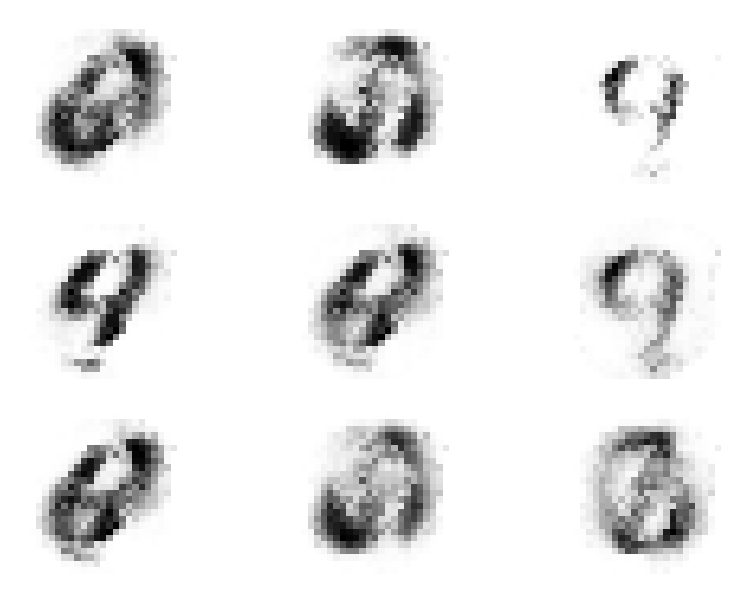

Epoch:75, Step:0, D-Loss:0.485, D-Acc:95.000, G-Loss:1.656, Wasserstein Dist:0.071
Epoch:75, Step:10, D-Loss:0.419, D-Acc:96.667, G-Loss:1.460, Wasserstein Dist:0.071
Epoch:75, Step:20, D-Loss:0.503, D-Acc:93.333, G-Loss:1.509, Wasserstein Dist:0.069
Epoch:75, Step:30, D-Loss:0.543, D-Acc:91.667, G-Loss:1.670, Wasserstein Dist:0.070
Epoch:75, Step:40, D-Loss:0.559, D-Acc:91.667, G-Loss:1.528, Wasserstein Dist:0.070
Epoch:76, Step:0, D-Loss:0.658, D-Acc:88.333, G-Loss:1.586, Wasserstein Dist:0.070
Epoch:76, Step:10, D-Loss:0.578, D-Acc:95.000, G-Loss:1.496, Wasserstein Dist:0.069
Epoch:76, Step:20, D-Loss:0.500, D-Acc:93.333, G-Loss:1.544, Wasserstein Dist:0.070
Epoch:76, Step:30, D-Loss:0.546, D-Acc:91.667, G-Loss:1.524, Wasserstein Dist:0.071
Epoch:76, Step:40, D-Loss:0.447, D-Acc:96.667, G-Loss:1.580, Wasserstein Dist:0.070
Epoch:77, Step:0, D-Loss:0.586, D-Acc:90.000, G-Loss:1.671, Wasserstein Dist:0.072
Epoch:77, Step:10, D-Loss:0.596, D-Acc:90.000, G-Loss:1.531, Wasserstein Dist:0

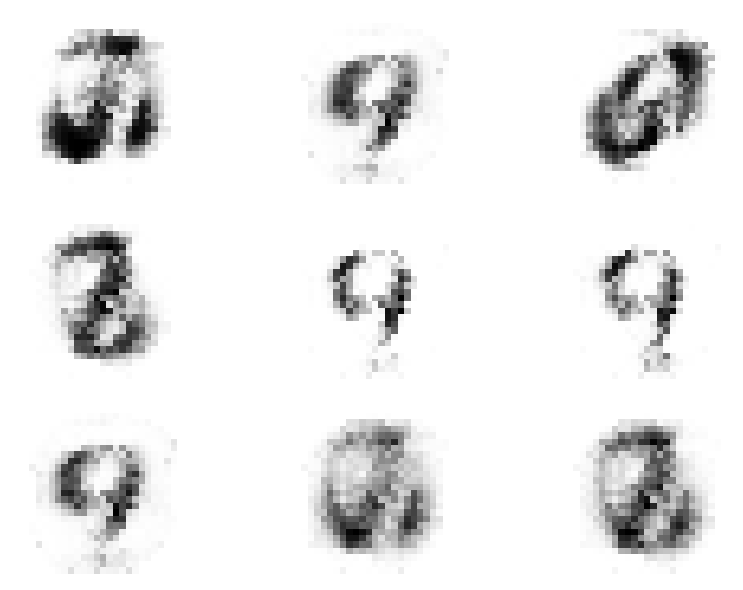

Epoch:80, Step:0, D-Loss:0.667, D-Acc:88.333, G-Loss:1.522, Wasserstein Dist:0.071
Epoch:80, Step:10, D-Loss:0.623, D-Acc:86.667, G-Loss:1.504, Wasserstein Dist:0.071
Epoch:80, Step:20, D-Loss:0.740, D-Acc:86.667, G-Loss:1.441, Wasserstein Dist:0.070
Epoch:80, Step:30, D-Loss:0.420, D-Acc:93.333, G-Loss:1.575, Wasserstein Dist:0.070
Epoch:80, Step:40, D-Loss:0.555, D-Acc:91.667, G-Loss:1.530, Wasserstein Dist:0.069
Epoch:81, Step:0, D-Loss:0.426, D-Acc:96.667, G-Loss:1.512, Wasserstein Dist:0.069
Epoch:81, Step:10, D-Loss:0.540, D-Acc:91.667, G-Loss:1.429, Wasserstein Dist:0.070
Epoch:81, Step:20, D-Loss:0.579, D-Acc:93.333, G-Loss:1.513, Wasserstein Dist:0.070
Epoch:81, Step:30, D-Loss:0.585, D-Acc:91.667, G-Loss:1.513, Wasserstein Dist:0.070
Epoch:81, Step:40, D-Loss:0.519, D-Acc:91.667, G-Loss:1.584, Wasserstein Dist:0.070
Epoch:82, Step:0, D-Loss:0.489, D-Acc:93.333, G-Loss:1.569, Wasserstein Dist:0.071
Epoch:82, Step:10, D-Loss:0.490, D-Acc:96.667, G-Loss:1.617, Wasserstein Dist:0

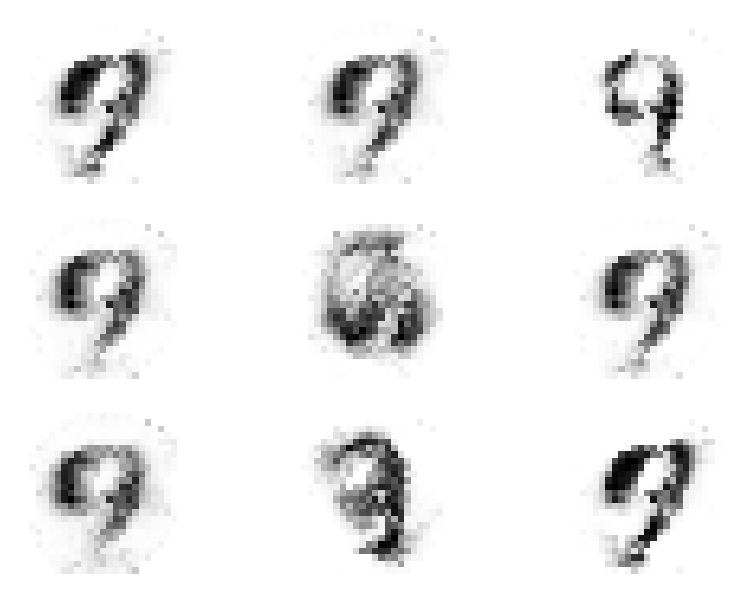

Epoch:85, Step:0, D-Loss:0.500, D-Acc:93.333, G-Loss:1.664, Wasserstein Dist:0.068
Epoch:85, Step:10, D-Loss:0.379, D-Acc:96.667, G-Loss:1.745, Wasserstein Dist:0.068
Epoch:85, Step:20, D-Loss:0.591, D-Acc:91.667, G-Loss:1.658, Wasserstein Dist:0.069
Epoch:85, Step:30, D-Loss:0.656, D-Acc:88.333, G-Loss:1.673, Wasserstein Dist:0.070
Epoch:85, Step:40, D-Loss:0.379, D-Acc:98.333, G-Loss:1.610, Wasserstein Dist:0.068
Epoch:86, Step:0, D-Loss:0.366, D-Acc:100.000, G-Loss:1.630, Wasserstein Dist:0.069
Epoch:86, Step:10, D-Loss:0.564, D-Acc:90.000, G-Loss:1.673, Wasserstein Dist:0.067
Epoch:86, Step:20, D-Loss:0.623, D-Acc:90.000, G-Loss:1.526, Wasserstein Dist:0.069
Epoch:86, Step:30, D-Loss:0.615, D-Acc:90.000, G-Loss:1.595, Wasserstein Dist:0.071
Epoch:86, Step:40, D-Loss:0.466, D-Acc:95.000, G-Loss:1.497, Wasserstein Dist:0.067
Epoch:87, Step:0, D-Loss:0.526, D-Acc:96.667, G-Loss:1.618, Wasserstein Dist:0.069
Epoch:87, Step:10, D-Loss:0.500, D-Acc:93.333, G-Loss:1.705, Wasserstein Dist:

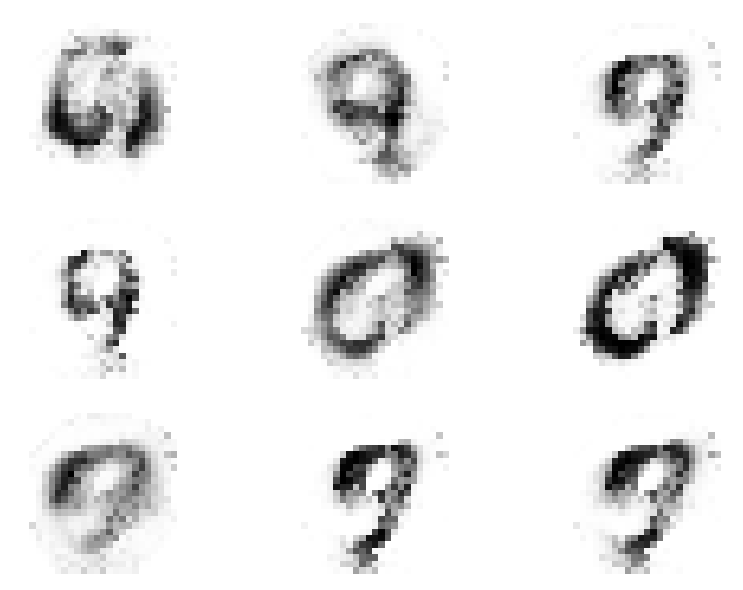

Epoch:90, Step:0, D-Loss:0.560, D-Acc:90.000, G-Loss:1.732, Wasserstein Dist:0.068
Epoch:90, Step:10, D-Loss:0.683, D-Acc:83.333, G-Loss:1.680, Wasserstein Dist:0.068
Epoch:90, Step:20, D-Loss:0.350, D-Acc:98.333, G-Loss:1.561, Wasserstein Dist:0.068
Epoch:90, Step:30, D-Loss:0.520, D-Acc:90.000, G-Loss:1.777, Wasserstein Dist:0.068
Epoch:90, Step:40, D-Loss:0.605, D-Acc:90.000, G-Loss:1.682, Wasserstein Dist:0.068
Epoch:91, Step:0, D-Loss:0.485, D-Acc:93.333, G-Loss:1.571, Wasserstein Dist:0.068
Epoch:91, Step:10, D-Loss:0.540, D-Acc:93.333, G-Loss:1.697, Wasserstein Dist:0.068
Epoch:91, Step:20, D-Loss:0.554, D-Acc:90.000, G-Loss:1.623, Wasserstein Dist:0.068
Epoch:91, Step:30, D-Loss:0.478, D-Acc:91.667, G-Loss:1.888, Wasserstein Dist:0.066
Epoch:91, Step:40, D-Loss:0.678, D-Acc:86.667, G-Loss:1.587, Wasserstein Dist:0.067
Epoch:92, Step:0, D-Loss:0.562, D-Acc:86.667, G-Loss:1.644, Wasserstein Dist:0.066
Epoch:92, Step:10, D-Loss:0.592, D-Acc:86.667, G-Loss:1.790, Wasserstein Dist:0

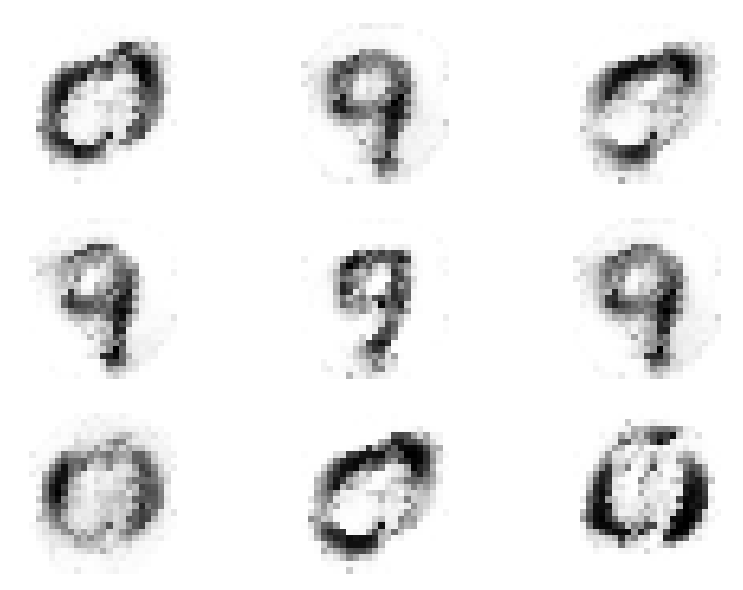

Epoch:95, Step:0, D-Loss:0.385, D-Acc:98.333, G-Loss:1.622, Wasserstein Dist:0.064
Epoch:95, Step:10, D-Loss:0.497, D-Acc:90.000, G-Loss:1.799, Wasserstein Dist:0.065
Epoch:95, Step:20, D-Loss:0.559, D-Acc:88.333, G-Loss:1.773, Wasserstein Dist:0.066
Epoch:95, Step:30, D-Loss:0.474, D-Acc:91.667, G-Loss:1.640, Wasserstein Dist:0.065
Epoch:95, Step:40, D-Loss:0.450, D-Acc:96.667, G-Loss:1.806, Wasserstein Dist:0.065
Epoch:96, Step:0, D-Loss:0.486, D-Acc:96.667, G-Loss:1.697, Wasserstein Dist:0.064
Epoch:96, Step:10, D-Loss:0.423, D-Acc:93.333, G-Loss:1.677, Wasserstein Dist:0.063
Epoch:96, Step:20, D-Loss:0.522, D-Acc:91.667, G-Loss:1.778, Wasserstein Dist:0.064
Epoch:96, Step:30, D-Loss:0.343, D-Acc:98.333, G-Loss:1.841, Wasserstein Dist:0.064
Epoch:96, Step:40, D-Loss:0.482, D-Acc:93.333, G-Loss:1.704, Wasserstein Dist:0.064
Epoch:97, Step:0, D-Loss:0.386, D-Acc:96.667, G-Loss:1.662, Wasserstein Dist:0.063
Epoch:97, Step:10, D-Loss:0.500, D-Acc:91.667, G-Loss:1.702, Wasserstein Dist:0

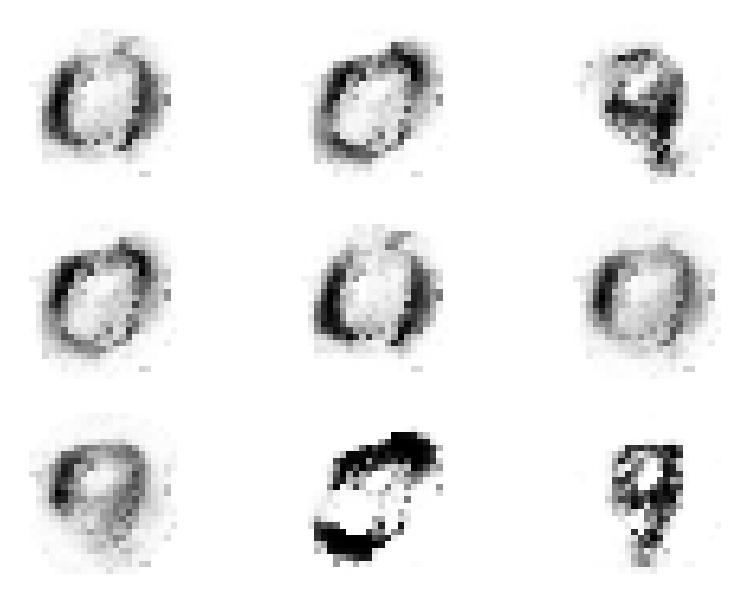

Epoch:100, Step:0, D-Loss:0.431, D-Acc:98.333, G-Loss:1.600, Wasserstein Dist:0.062
Epoch:100, Step:10, D-Loss:0.416, D-Acc:95.000, G-Loss:1.782, Wasserstein Dist:0.061
Epoch:100, Step:20, D-Loss:0.448, D-Acc:93.333, G-Loss:1.659, Wasserstein Dist:0.061
Epoch:100, Step:30, D-Loss:0.588, D-Acc:93.333, G-Loss:1.626, Wasserstein Dist:0.062
Epoch:100, Step:40, D-Loss:0.567, D-Acc:93.333, G-Loss:1.608, Wasserstein Dist:0.062
Epoch:101, Step:0, D-Loss:0.622, D-Acc:91.667, G-Loss:1.704, Wasserstein Dist:0.062
Epoch:101, Step:10, D-Loss:0.584, D-Acc:90.000, G-Loss:1.646, Wasserstein Dist:0.061
Epoch:101, Step:20, D-Loss:0.531, D-Acc:91.667, G-Loss:1.775, Wasserstein Dist:0.062
Epoch:101, Step:30, D-Loss:0.462, D-Acc:96.667, G-Loss:1.673, Wasserstein Dist:0.061
Epoch:101, Step:40, D-Loss:0.545, D-Acc:93.333, G-Loss:1.665, Wasserstein Dist:0.061
Epoch:102, Step:0, D-Loss:0.399, D-Acc:96.667, G-Loss:1.732, Wasserstein Dist:0.060
Epoch:102, Step:10, D-Loss:0.395, D-Acc:96.667, G-Loss:1.838, Wasser

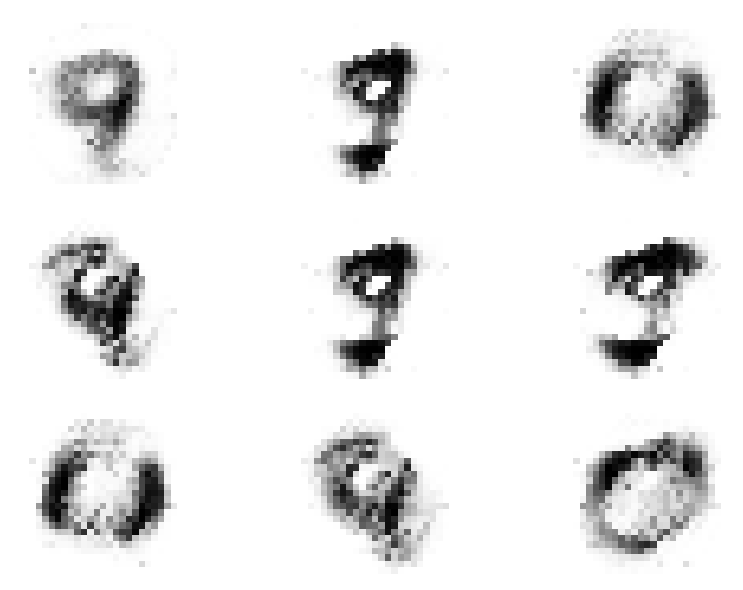

Epoch:105, Step:0, D-Loss:0.591, D-Acc:88.333, G-Loss:1.726, Wasserstein Dist:0.059
Epoch:105, Step:10, D-Loss:0.501, D-Acc:93.333, G-Loss:1.917, Wasserstein Dist:0.058
Epoch:105, Step:20, D-Loss:0.481, D-Acc:95.000, G-Loss:1.726, Wasserstein Dist:0.060
Epoch:105, Step:30, D-Loss:0.457, D-Acc:93.333, G-Loss:1.662, Wasserstein Dist:0.057
Epoch:105, Step:40, D-Loss:0.420, D-Acc:93.333, G-Loss:1.792, Wasserstein Dist:0.058
Epoch:106, Step:0, D-Loss:0.421, D-Acc:95.000, G-Loss:1.841, Wasserstein Dist:0.059
Epoch:106, Step:10, D-Loss:0.473, D-Acc:93.333, G-Loss:1.826, Wasserstein Dist:0.058
Epoch:106, Step:20, D-Loss:0.499, D-Acc:93.333, G-Loss:1.858, Wasserstein Dist:0.057
Epoch:106, Step:30, D-Loss:0.523, D-Acc:88.333, G-Loss:1.821, Wasserstein Dist:0.058
Epoch:106, Step:40, D-Loss:0.464, D-Acc:95.000, G-Loss:1.733, Wasserstein Dist:0.057
Epoch:107, Step:0, D-Loss:0.575, D-Acc:90.000, G-Loss:1.861, Wasserstein Dist:0.057
Epoch:107, Step:10, D-Loss:0.397, D-Acc:91.667, G-Loss:1.851, Wasser

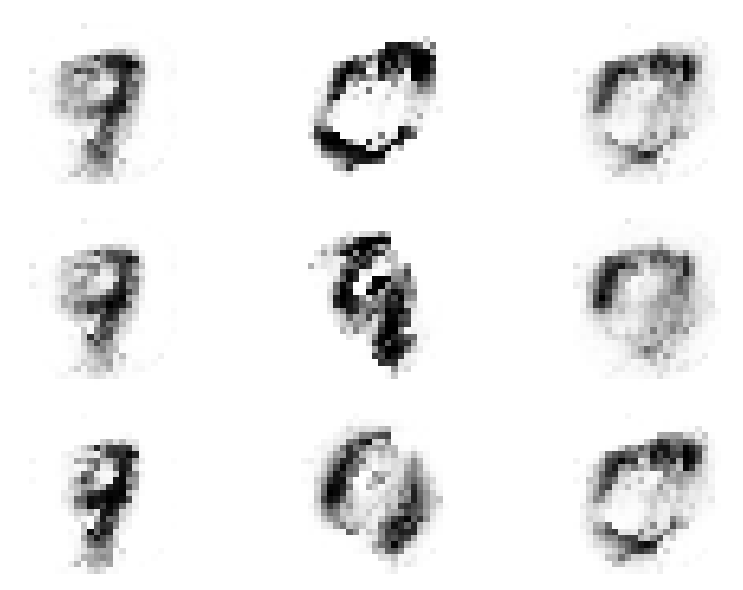

Epoch:110, Step:0, D-Loss:0.515, D-Acc:93.333, G-Loss:1.784, Wasserstein Dist:0.055
Epoch:110, Step:10, D-Loss:0.516, D-Acc:91.667, G-Loss:1.586, Wasserstein Dist:0.054
Epoch:110, Step:20, D-Loss:0.563, D-Acc:86.667, G-Loss:1.727, Wasserstein Dist:0.053
Epoch:110, Step:30, D-Loss:0.416, D-Acc:96.667, G-Loss:1.710, Wasserstein Dist:0.054
Epoch:110, Step:40, D-Loss:0.436, D-Acc:96.667, G-Loss:1.872, Wasserstein Dist:0.054
Epoch:111, Step:0, D-Loss:0.428, D-Acc:93.333, G-Loss:1.829, Wasserstein Dist:0.054
Epoch:111, Step:10, D-Loss:0.558, D-Acc:93.333, G-Loss:1.733, Wasserstein Dist:0.054
Epoch:111, Step:20, D-Loss:0.377, D-Acc:98.333, G-Loss:1.674, Wasserstein Dist:0.054
Epoch:111, Step:30, D-Loss:0.479, D-Acc:93.333, G-Loss:1.829, Wasserstein Dist:0.055
Epoch:111, Step:40, D-Loss:0.493, D-Acc:91.667, G-Loss:1.753, Wasserstein Dist:0.054
Epoch:112, Step:0, D-Loss:0.474, D-Acc:95.000, G-Loss:1.689, Wasserstein Dist:0.053
Epoch:112, Step:10, D-Loss:0.441, D-Acc:95.000, G-Loss:1.882, Wasser

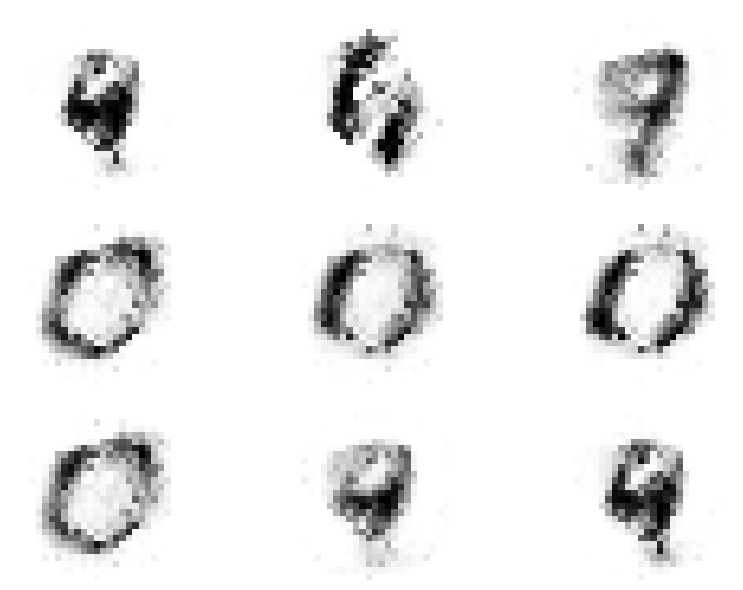

Epoch:115, Step:0, D-Loss:0.398, D-Acc:95.000, G-Loss:1.876, Wasserstein Dist:0.052
Epoch:115, Step:10, D-Loss:0.470, D-Acc:93.333, G-Loss:1.760, Wasserstein Dist:0.052
Epoch:115, Step:20, D-Loss:0.504, D-Acc:90.000, G-Loss:1.752, Wasserstein Dist:0.053
Epoch:115, Step:30, D-Loss:0.386, D-Acc:98.333, G-Loss:1.770, Wasserstein Dist:0.050
Epoch:115, Step:40, D-Loss:0.391, D-Acc:96.667, G-Loss:1.906, Wasserstein Dist:0.052
Epoch:116, Step:0, D-Loss:0.405, D-Acc:96.667, G-Loss:1.759, Wasserstein Dist:0.054
Epoch:116, Step:10, D-Loss:0.433, D-Acc:95.000, G-Loss:1.744, Wasserstein Dist:0.052
Epoch:116, Step:20, D-Loss:0.527, D-Acc:88.333, G-Loss:1.718, Wasserstein Dist:0.052
Epoch:116, Step:30, D-Loss:0.356, D-Acc:98.333, G-Loss:1.920, Wasserstein Dist:0.053
Epoch:116, Step:40, D-Loss:0.401, D-Acc:96.667, G-Loss:1.849, Wasserstein Dist:0.053
Epoch:117, Step:0, D-Loss:0.442, D-Acc:93.333, G-Loss:1.681, Wasserstein Dist:0.052
Epoch:117, Step:10, D-Loss:0.498, D-Acc:95.000, G-Loss:1.716, Wasser

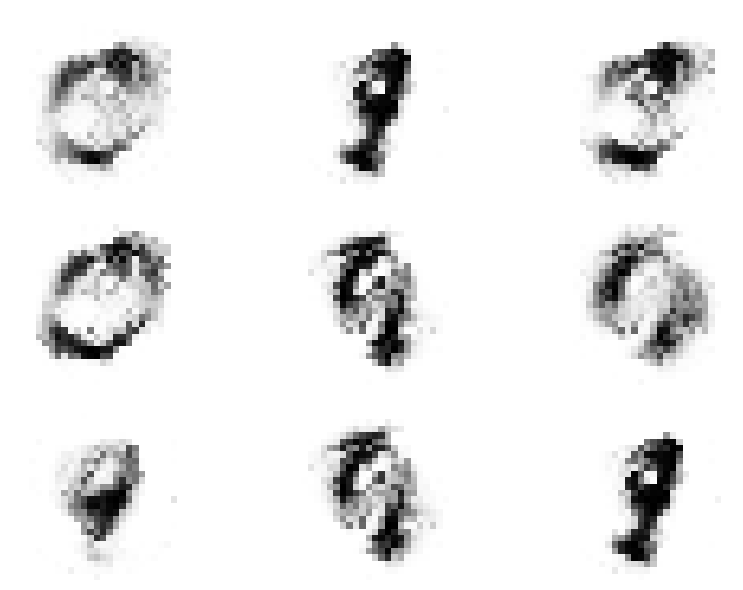

Epoch:120, Step:0, D-Loss:0.370, D-Acc:96.667, G-Loss:1.866, Wasserstein Dist:0.052
Epoch:120, Step:10, D-Loss:0.415, D-Acc:95.000, G-Loss:1.994, Wasserstein Dist:0.053
Epoch:120, Step:20, D-Loss:0.407, D-Acc:96.667, G-Loss:1.655, Wasserstein Dist:0.052
Epoch:120, Step:30, D-Loss:0.397, D-Acc:100.000, G-Loss:1.738, Wasserstein Dist:0.051
Epoch:120, Step:40, D-Loss:0.380, D-Acc:95.000, G-Loss:1.759, Wasserstein Dist:0.053
Epoch:121, Step:0, D-Loss:0.468, D-Acc:91.667, G-Loss:1.781, Wasserstein Dist:0.051
Epoch:121, Step:10, D-Loss:0.343, D-Acc:98.333, G-Loss:1.790, Wasserstein Dist:0.051
Epoch:121, Step:20, D-Loss:0.460, D-Acc:91.667, G-Loss:1.828, Wasserstein Dist:0.053
Epoch:121, Step:30, D-Loss:0.545, D-Acc:88.333, G-Loss:1.792, Wasserstein Dist:0.053
Epoch:121, Step:40, D-Loss:0.382, D-Acc:98.333, G-Loss:1.809, Wasserstein Dist:0.053
Epoch:122, Step:0, D-Loss:0.379, D-Acc:98.333, G-Loss:1.805, Wasserstein Dist:0.051
Epoch:122, Step:10, D-Loss:0.468, D-Acc:91.667, G-Loss:1.814, Wasse

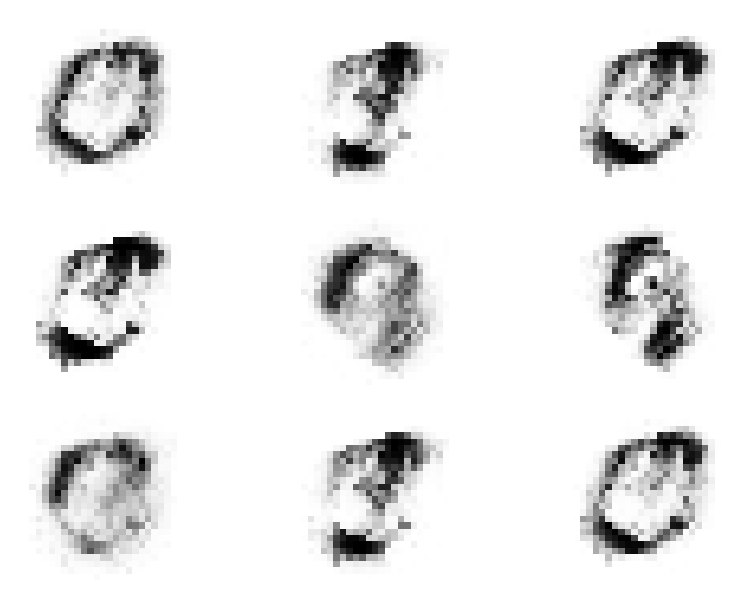

Epoch:125, Step:0, D-Loss:0.379, D-Acc:95.000, G-Loss:1.814, Wasserstein Dist:0.052
Epoch:125, Step:10, D-Loss:0.457, D-Acc:93.333, G-Loss:1.869, Wasserstein Dist:0.051
Epoch:125, Step:20, D-Loss:0.484, D-Acc:95.000, G-Loss:1.708, Wasserstein Dist:0.054
Epoch:125, Step:30, D-Loss:0.422, D-Acc:93.333, G-Loss:1.882, Wasserstein Dist:0.052
Epoch:125, Step:40, D-Loss:0.455, D-Acc:95.000, G-Loss:1.913, Wasserstein Dist:0.054
Epoch:126, Step:0, D-Loss:0.457, D-Acc:95.000, G-Loss:1.856, Wasserstein Dist:0.052
Epoch:126, Step:10, D-Loss:0.537, D-Acc:90.000, G-Loss:1.878, Wasserstein Dist:0.052
Epoch:126, Step:20, D-Loss:0.587, D-Acc:90.000, G-Loss:1.995, Wasserstein Dist:0.053
Epoch:126, Step:30, D-Loss:0.401, D-Acc:95.000, G-Loss:1.897, Wasserstein Dist:0.052
Epoch:126, Step:40, D-Loss:0.442, D-Acc:93.333, G-Loss:1.748, Wasserstein Dist:0.052
Epoch:127, Step:0, D-Loss:0.403, D-Acc:95.000, G-Loss:1.754, Wasserstein Dist:0.052
Epoch:127, Step:10, D-Loss:0.487, D-Acc:90.000, G-Loss:1.934, Wasser

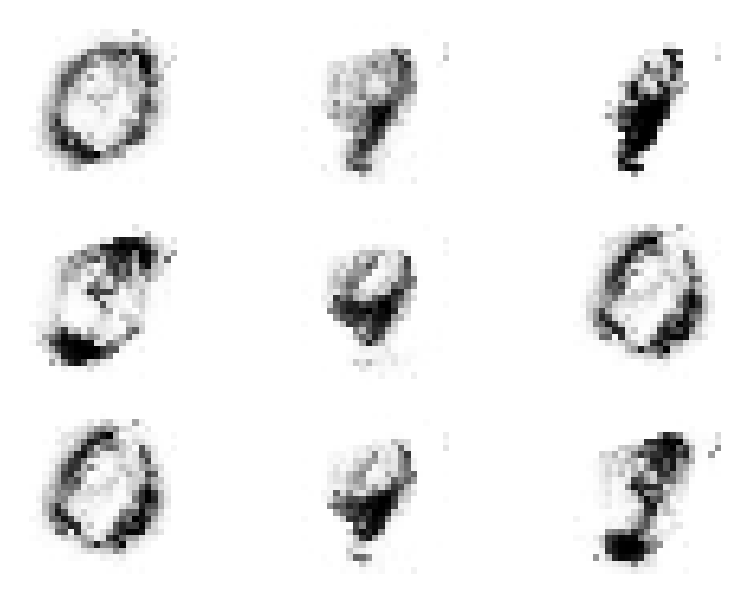

Epoch:130, Step:0, D-Loss:0.501, D-Acc:95.000, G-Loss:1.827, Wasserstein Dist:0.054
Epoch:130, Step:10, D-Loss:0.432, D-Acc:96.667, G-Loss:1.786, Wasserstein Dist:0.052
Epoch:130, Step:20, D-Loss:0.476, D-Acc:95.000, G-Loss:1.759, Wasserstein Dist:0.054
Epoch:130, Step:30, D-Loss:0.553, D-Acc:88.333, G-Loss:1.676, Wasserstein Dist:0.055
Epoch:130, Step:40, D-Loss:0.506, D-Acc:91.667, G-Loss:1.751, Wasserstein Dist:0.053
Epoch:131, Step:0, D-Loss:0.398, D-Acc:98.333, G-Loss:1.695, Wasserstein Dist:0.053
Epoch:131, Step:10, D-Loss:0.391, D-Acc:100.000, G-Loss:1.859, Wasserstein Dist:0.054
Epoch:131, Step:20, D-Loss:0.426, D-Acc:93.333, G-Loss:1.799, Wasserstein Dist:0.052
Epoch:131, Step:30, D-Loss:0.415, D-Acc:95.000, G-Loss:1.722, Wasserstein Dist:0.052
Epoch:131, Step:40, D-Loss:0.452, D-Acc:93.333, G-Loss:1.883, Wasserstein Dist:0.053
Epoch:132, Step:0, D-Loss:0.402, D-Acc:98.333, G-Loss:1.889, Wasserstein Dist:0.053
Epoch:132, Step:10, D-Loss:0.352, D-Acc:100.000, G-Loss:1.787, Wass

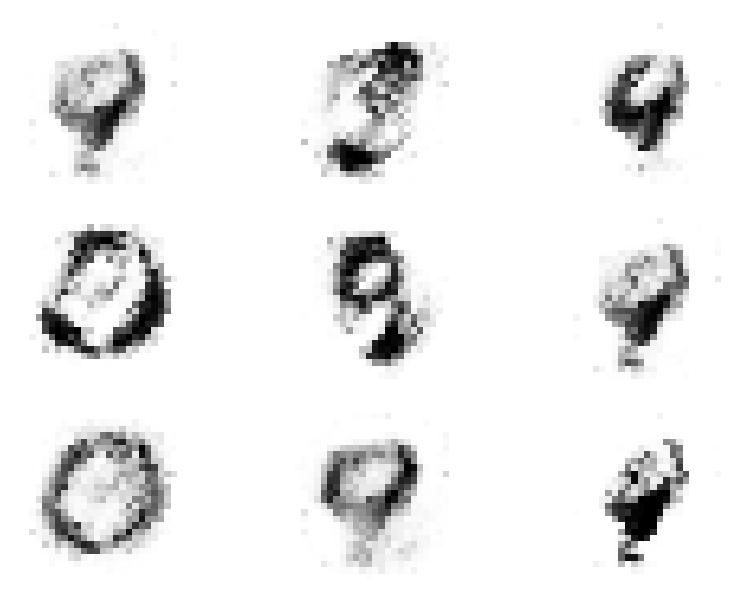

Epoch:135, Step:0, D-Loss:0.342, D-Acc:98.333, G-Loss:1.910, Wasserstein Dist:0.053
Epoch:135, Step:10, D-Loss:0.436, D-Acc:93.333, G-Loss:1.802, Wasserstein Dist:0.054
Epoch:135, Step:20, D-Loss:0.431, D-Acc:98.333, G-Loss:1.764, Wasserstein Dist:0.052
Epoch:135, Step:30, D-Loss:0.484, D-Acc:93.333, G-Loss:1.807, Wasserstein Dist:0.053
Epoch:135, Step:40, D-Loss:0.357, D-Acc:95.000, G-Loss:1.863, Wasserstein Dist:0.053
Epoch:136, Step:0, D-Loss:0.405, D-Acc:95.000, G-Loss:1.753, Wasserstein Dist:0.053
Epoch:136, Step:10, D-Loss:0.387, D-Acc:98.333, G-Loss:1.862, Wasserstein Dist:0.051
Epoch:136, Step:20, D-Loss:0.403, D-Acc:96.667, G-Loss:1.881, Wasserstein Dist:0.053
Epoch:136, Step:30, D-Loss:0.494, D-Acc:95.000, G-Loss:1.863, Wasserstein Dist:0.052
Epoch:136, Step:40, D-Loss:0.429, D-Acc:93.333, G-Loss:1.949, Wasserstein Dist:0.052
Epoch:137, Step:0, D-Loss:0.446, D-Acc:95.000, G-Loss:1.944, Wasserstein Dist:0.052
Epoch:137, Step:10, D-Loss:0.399, D-Acc:95.000, G-Loss:1.922, Wasser

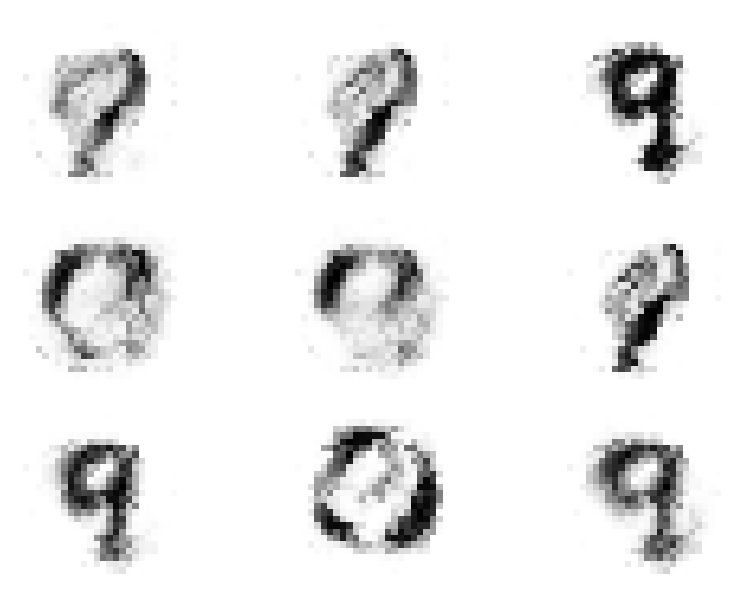

Epoch:140, Step:0, D-Loss:0.508, D-Acc:91.667, G-Loss:2.020, Wasserstein Dist:0.055
Epoch:140, Step:10, D-Loss:0.495, D-Acc:95.000, G-Loss:1.823, Wasserstein Dist:0.053
Epoch:140, Step:20, D-Loss:0.420, D-Acc:95.000, G-Loss:1.872, Wasserstein Dist:0.054
Epoch:140, Step:30, D-Loss:0.326, D-Acc:98.333, G-Loss:1.923, Wasserstein Dist:0.053
Epoch:140, Step:40, D-Loss:0.381, D-Acc:96.667, G-Loss:1.955, Wasserstein Dist:0.054
Epoch:141, Step:0, D-Loss:0.365, D-Acc:95.000, G-Loss:1.975, Wasserstein Dist:0.054
Epoch:141, Step:10, D-Loss:0.386, D-Acc:95.000, G-Loss:1.902, Wasserstein Dist:0.053
Epoch:141, Step:20, D-Loss:0.427, D-Acc:93.333, G-Loss:2.000, Wasserstein Dist:0.053
Epoch:141, Step:30, D-Loss:0.376, D-Acc:96.667, G-Loss:1.880, Wasserstein Dist:0.054
Epoch:141, Step:40, D-Loss:0.534, D-Acc:88.333, G-Loss:1.911, Wasserstein Dist:0.053
Epoch:142, Step:0, D-Loss:0.310, D-Acc:96.667, G-Loss:2.109, Wasserstein Dist:0.054
Epoch:142, Step:10, D-Loss:0.483, D-Acc:90.000, G-Loss:1.919, Wasser

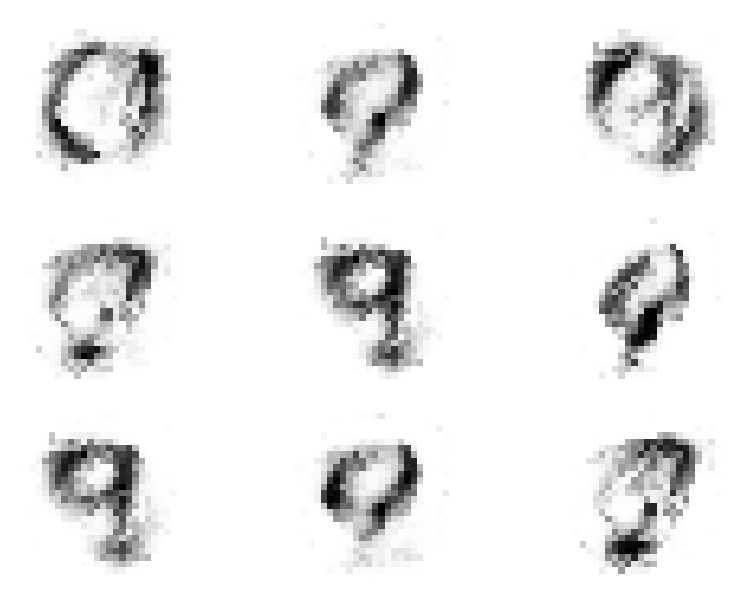

Epoch:145, Step:0, D-Loss:0.415, D-Acc:95.000, G-Loss:1.955, Wasserstein Dist:0.054
Epoch:145, Step:10, D-Loss:0.265, D-Acc:100.000, G-Loss:2.012, Wasserstein Dist:0.053
Epoch:145, Step:20, D-Loss:0.353, D-Acc:96.667, G-Loss:2.016, Wasserstein Dist:0.053
Epoch:145, Step:30, D-Loss:0.361, D-Acc:98.333, G-Loss:1.984, Wasserstein Dist:0.054
Epoch:145, Step:40, D-Loss:0.343, D-Acc:93.333, G-Loss:1.903, Wasserstein Dist:0.053
Epoch:146, Step:0, D-Loss:0.397, D-Acc:95.000, G-Loss:1.796, Wasserstein Dist:0.053
Epoch:146, Step:10, D-Loss:0.327, D-Acc:96.667, G-Loss:1.815, Wasserstein Dist:0.052
Epoch:146, Step:20, D-Loss:0.304, D-Acc:100.000, G-Loss:1.980, Wasserstein Dist:0.052
Epoch:146, Step:30, D-Loss:0.469, D-Acc:90.000, G-Loss:2.052, Wasserstein Dist:0.051
Epoch:146, Step:40, D-Loss:0.421, D-Acc:91.667, G-Loss:1.862, Wasserstein Dist:0.052
Epoch:147, Step:0, D-Loss:0.525, D-Acc:93.333, G-Loss:1.922, Wasserstein Dist:0.051
Epoch:147, Step:10, D-Loss:0.437, D-Acc:93.333, G-Loss:1.944, Wass

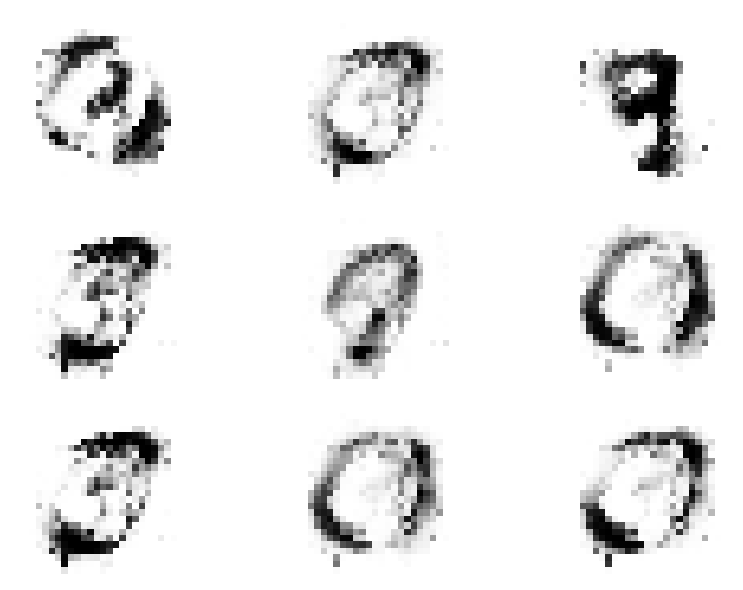

Epoch:150, Step:0, D-Loss:0.365, D-Acc:96.667, G-Loss:1.986, Wasserstein Dist:0.052
Epoch:150, Step:10, D-Loss:0.411, D-Acc:95.000, G-Loss:2.116, Wasserstein Dist:0.052
Epoch:150, Step:20, D-Loss:0.459, D-Acc:93.333, G-Loss:2.082, Wasserstein Dist:0.052
Epoch:150, Step:30, D-Loss:0.266, D-Acc:98.333, G-Loss:1.941, Wasserstein Dist:0.053
Epoch:150, Step:40, D-Loss:0.372, D-Acc:96.667, G-Loss:1.977, Wasserstein Dist:0.052
Epoch:151, Step:0, D-Loss:0.299, D-Acc:96.667, G-Loss:2.029, Wasserstein Dist:0.051
Epoch:151, Step:10, D-Loss:0.392, D-Acc:96.667, G-Loss:1.997, Wasserstein Dist:0.052
Epoch:151, Step:20, D-Loss:0.395, D-Acc:96.667, G-Loss:2.098, Wasserstein Dist:0.053
Epoch:151, Step:30, D-Loss:0.326, D-Acc:96.667, G-Loss:2.031, Wasserstein Dist:0.050
Epoch:151, Step:40, D-Loss:0.412, D-Acc:91.667, G-Loss:1.951, Wasserstein Dist:0.051
Epoch:152, Step:0, D-Loss:0.440, D-Acc:93.333, G-Loss:1.938, Wasserstein Dist:0.051
Epoch:152, Step:10, D-Loss:0.339, D-Acc:95.000, G-Loss:2.308, Wasser

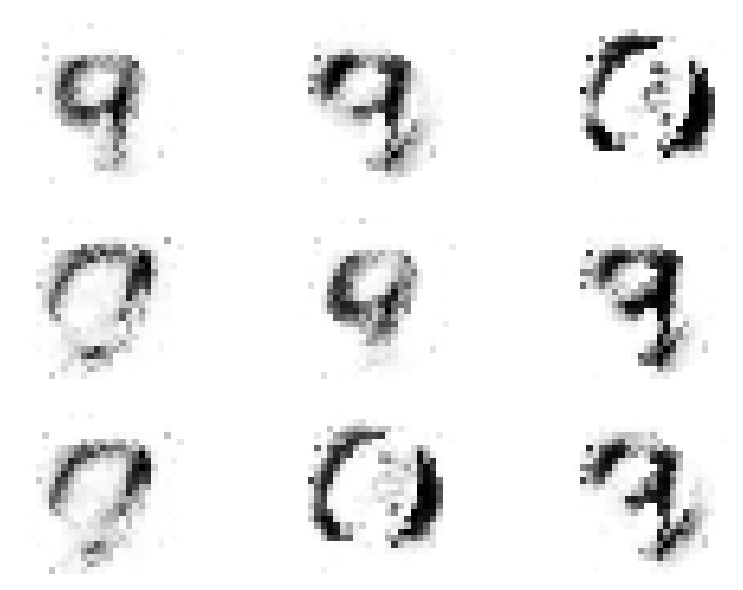

Epoch:155, Step:0, D-Loss:0.457, D-Acc:90.000, G-Loss:2.111, Wasserstein Dist:0.051
Epoch:155, Step:10, D-Loss:0.394, D-Acc:95.000, G-Loss:2.062, Wasserstein Dist:0.053
Epoch:155, Step:20, D-Loss:0.392, D-Acc:95.000, G-Loss:2.058, Wasserstein Dist:0.051
Epoch:155, Step:30, D-Loss:0.395, D-Acc:93.333, G-Loss:2.164, Wasserstein Dist:0.051
Epoch:155, Step:40, D-Loss:0.315, D-Acc:96.667, G-Loss:2.282, Wasserstein Dist:0.051
Epoch:156, Step:0, D-Loss:0.292, D-Acc:98.333, G-Loss:2.266, Wasserstein Dist:0.050
Epoch:156, Step:10, D-Loss:0.365, D-Acc:95.000, G-Loss:2.024, Wasserstein Dist:0.051
Epoch:156, Step:20, D-Loss:0.363, D-Acc:96.667, G-Loss:2.215, Wasserstein Dist:0.050
Epoch:156, Step:30, D-Loss:0.315, D-Acc:93.333, G-Loss:2.178, Wasserstein Dist:0.053
Epoch:156, Step:40, D-Loss:0.244, D-Acc:100.000, G-Loss:2.241, Wasserstein Dist:0.051
Epoch:157, Step:0, D-Loss:0.333, D-Acc:96.667, G-Loss:2.059, Wasserstein Dist:0.052
Epoch:157, Step:10, D-Loss:0.383, D-Acc:93.333, G-Loss:2.006, Wasse

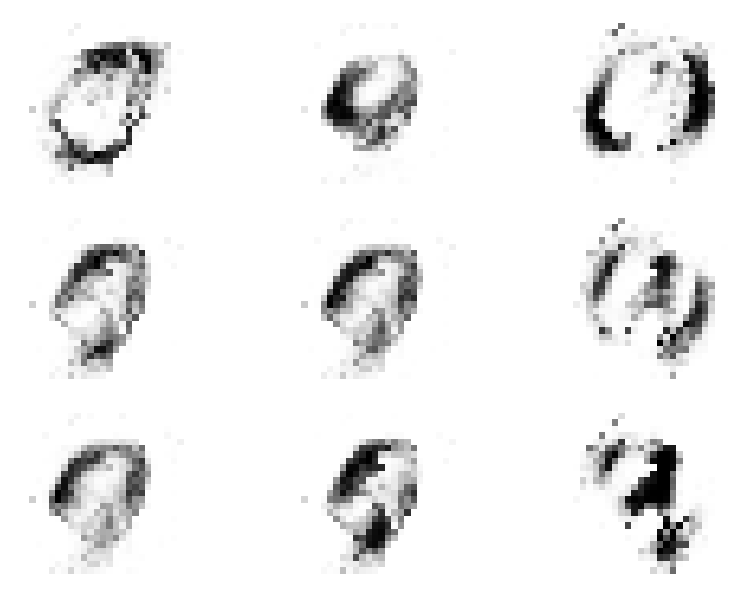

Epoch:160, Step:0, D-Loss:0.238, D-Acc:98.333, G-Loss:2.397, Wasserstein Dist:0.050
Epoch:160, Step:10, D-Loss:0.416, D-Acc:93.333, G-Loss:2.214, Wasserstein Dist:0.049
Epoch:160, Step:20, D-Loss:0.314, D-Acc:96.667, G-Loss:2.434, Wasserstein Dist:0.050
Epoch:160, Step:30, D-Loss:0.387, D-Acc:93.333, G-Loss:2.126, Wasserstein Dist:0.049
Epoch:160, Step:40, D-Loss:0.193, D-Acc:100.000, G-Loss:2.084, Wasserstein Dist:0.049
Epoch:161, Step:0, D-Loss:0.417, D-Acc:93.333, G-Loss:2.294, Wasserstein Dist:0.050
Epoch:161, Step:10, D-Loss:0.333, D-Acc:96.667, G-Loss:2.361, Wasserstein Dist:0.048
Epoch:161, Step:20, D-Loss:0.223, D-Acc:100.000, G-Loss:2.098, Wasserstein Dist:0.050
Epoch:161, Step:30, D-Loss:0.341, D-Acc:93.333, G-Loss:2.287, Wasserstein Dist:0.049
Epoch:161, Step:40, D-Loss:0.302, D-Acc:95.000, G-Loss:2.257, Wasserstein Dist:0.047
Epoch:162, Step:0, D-Loss:0.281, D-Acc:96.667, G-Loss:2.179, Wasserstein Dist:0.049
Epoch:162, Step:10, D-Loss:0.207, D-Acc:100.000, G-Loss:2.182, Was

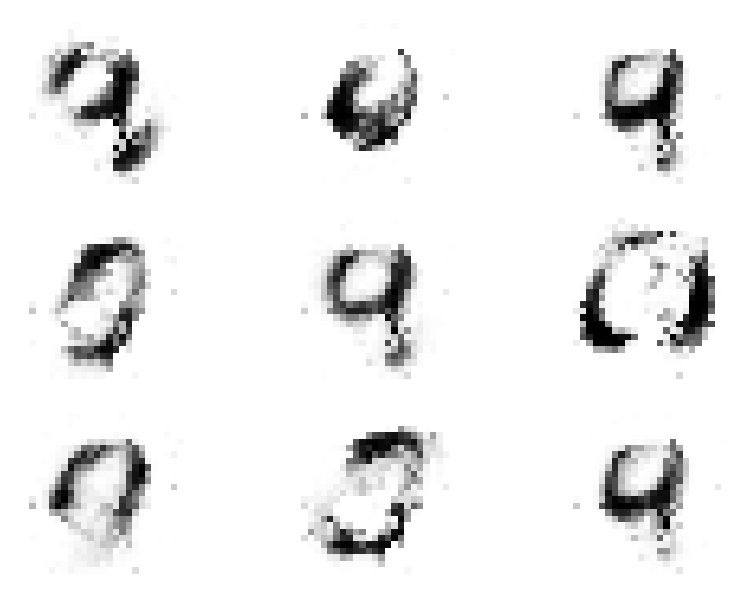

Epoch:165, Step:0, D-Loss:0.313, D-Acc:96.667, G-Loss:2.159, Wasserstein Dist:0.047
Epoch:165, Step:10, D-Loss:0.383, D-Acc:93.333, G-Loss:2.103, Wasserstein Dist:0.045
Epoch:165, Step:20, D-Loss:0.304, D-Acc:95.000, G-Loss:2.247, Wasserstein Dist:0.048
Epoch:165, Step:30, D-Loss:0.334, D-Acc:93.333, G-Loss:2.121, Wasserstein Dist:0.047
Epoch:165, Step:40, D-Loss:0.275, D-Acc:95.000, G-Loss:2.077, Wasserstein Dist:0.046
Epoch:166, Step:0, D-Loss:0.265, D-Acc:93.333, G-Loss:2.227, Wasserstein Dist:0.047
Epoch:166, Step:10, D-Loss:0.291, D-Acc:95.000, G-Loss:2.290, Wasserstein Dist:0.045
Epoch:166, Step:20, D-Loss:0.268, D-Acc:98.333, G-Loss:2.200, Wasserstein Dist:0.044
Epoch:166, Step:30, D-Loss:0.330, D-Acc:95.000, G-Loss:2.311, Wasserstein Dist:0.045
Epoch:166, Step:40, D-Loss:0.309, D-Acc:96.667, G-Loss:2.230, Wasserstein Dist:0.046
Epoch:167, Step:0, D-Loss:0.351, D-Acc:93.333, G-Loss:2.304, Wasserstein Dist:0.046
Epoch:167, Step:10, D-Loss:0.322, D-Acc:96.667, G-Loss:2.417, Wasser

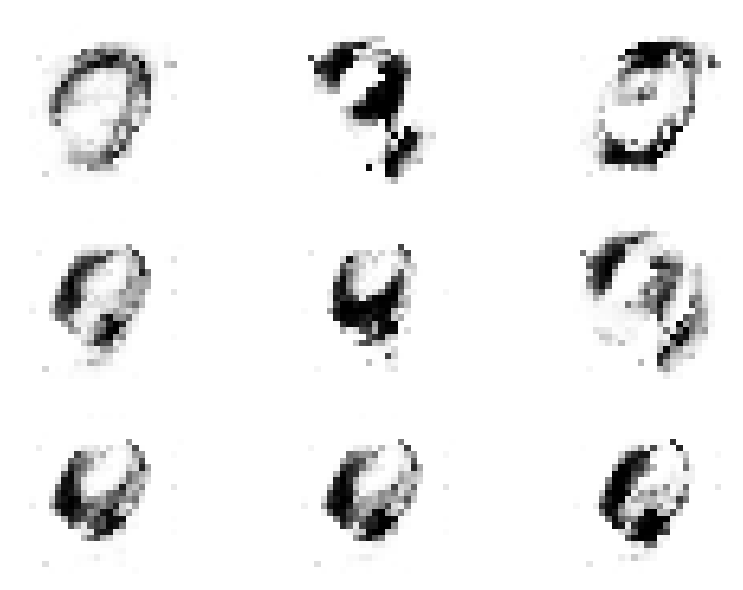

Epoch:170, Step:0, D-Loss:0.211, D-Acc:100.000, G-Loss:2.365, Wasserstein Dist:0.045
Epoch:170, Step:10, D-Loss:0.306, D-Acc:96.667, G-Loss:2.294, Wasserstein Dist:0.045
Epoch:170, Step:20, D-Loss:0.258, D-Acc:98.333, G-Loss:2.309, Wasserstein Dist:0.044
Epoch:170, Step:30, D-Loss:0.203, D-Acc:98.333, G-Loss:2.356, Wasserstein Dist:0.044
Epoch:170, Step:40, D-Loss:0.303, D-Acc:96.667, G-Loss:2.154, Wasserstein Dist:0.046
Epoch:171, Step:0, D-Loss:0.227, D-Acc:100.000, G-Loss:2.352, Wasserstein Dist:0.045
Epoch:171, Step:10, D-Loss:0.232, D-Acc:98.333, G-Loss:2.297, Wasserstein Dist:0.044
Epoch:171, Step:20, D-Loss:0.293, D-Acc:96.667, G-Loss:2.134, Wasserstein Dist:0.043
Epoch:171, Step:30, D-Loss:0.196, D-Acc:100.000, G-Loss:2.390, Wasserstein Dist:0.043
Epoch:171, Step:40, D-Loss:0.266, D-Acc:96.667, G-Loss:2.333, Wasserstein Dist:0.044
Epoch:172, Step:0, D-Loss:0.247, D-Acc:98.333, G-Loss:2.299, Wasserstein Dist:0.042
Epoch:172, Step:10, D-Loss:0.190, D-Acc:98.333, G-Loss:2.403, Was

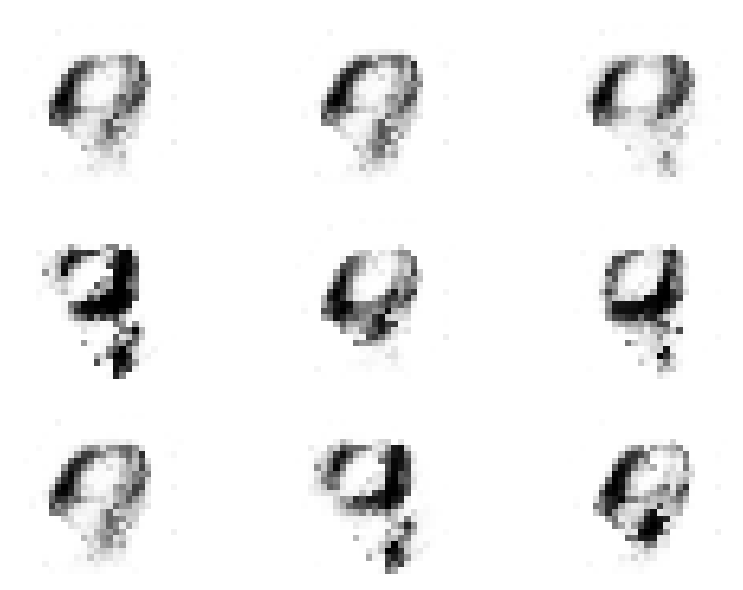

Epoch:175, Step:0, D-Loss:0.221, D-Acc:98.333, G-Loss:2.411, Wasserstein Dist:0.044
Epoch:175, Step:10, D-Loss:0.271, D-Acc:98.333, G-Loss:2.472, Wasserstein Dist:0.041
Epoch:175, Step:20, D-Loss:0.293, D-Acc:95.000, G-Loss:2.446, Wasserstein Dist:0.043
Epoch:175, Step:30, D-Loss:0.155, D-Acc:100.000, G-Loss:2.512, Wasserstein Dist:0.041
Epoch:175, Step:40, D-Loss:0.260, D-Acc:96.667, G-Loss:2.426, Wasserstein Dist:0.041
Epoch:176, Step:0, D-Loss:0.249, D-Acc:96.667, G-Loss:2.435, Wasserstein Dist:0.042
Epoch:176, Step:10, D-Loss:0.247, D-Acc:96.667, G-Loss:2.264, Wasserstein Dist:0.041
Epoch:176, Step:20, D-Loss:0.203, D-Acc:100.000, G-Loss:2.455, Wasserstein Dist:0.040
Epoch:176, Step:30, D-Loss:0.238, D-Acc:98.333, G-Loss:2.240, Wasserstein Dist:0.041
Epoch:176, Step:40, D-Loss:0.266, D-Acc:98.333, G-Loss:2.412, Wasserstein Dist:0.042
Epoch:177, Step:0, D-Loss:0.350, D-Acc:93.333, G-Loss:2.597, Wasserstein Dist:0.040
Epoch:177, Step:10, D-Loss:0.164, D-Acc:100.000, G-Loss:2.342, Was

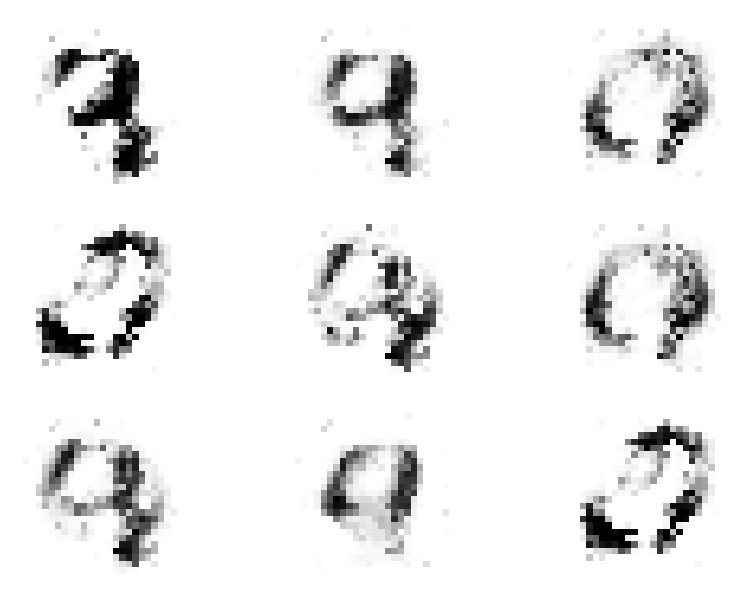

Epoch:180, Step:0, D-Loss:0.164, D-Acc:100.000, G-Loss:2.453, Wasserstein Dist:0.039
Epoch:180, Step:10, D-Loss:0.197, D-Acc:98.333, G-Loss:2.548, Wasserstein Dist:0.041
Epoch:180, Step:20, D-Loss:0.191, D-Acc:100.000, G-Loss:2.618, Wasserstein Dist:0.040
Epoch:180, Step:30, D-Loss:0.216, D-Acc:98.333, G-Loss:2.622, Wasserstein Dist:0.038
Epoch:180, Step:40, D-Loss:0.241, D-Acc:93.333, G-Loss:2.459, Wasserstein Dist:0.041
Epoch:181, Step:0, D-Loss:0.213, D-Acc:95.000, G-Loss:2.608, Wasserstein Dist:0.039
Epoch:181, Step:10, D-Loss:0.121, D-Acc:100.000, G-Loss:2.694, Wasserstein Dist:0.039
Epoch:181, Step:20, D-Loss:0.227, D-Acc:96.667, G-Loss:2.749, Wasserstein Dist:0.039
Epoch:181, Step:30, D-Loss:0.228, D-Acc:96.667, G-Loss:2.547, Wasserstein Dist:0.039
Epoch:181, Step:40, D-Loss:0.295, D-Acc:93.333, G-Loss:2.714, Wasserstein Dist:0.040
Epoch:182, Step:0, D-Loss:0.166, D-Acc:100.000, G-Loss:2.501, Wasserstein Dist:0.039
Epoch:182, Step:10, D-Loss:0.092, D-Acc:100.000, G-Loss:2.563, W

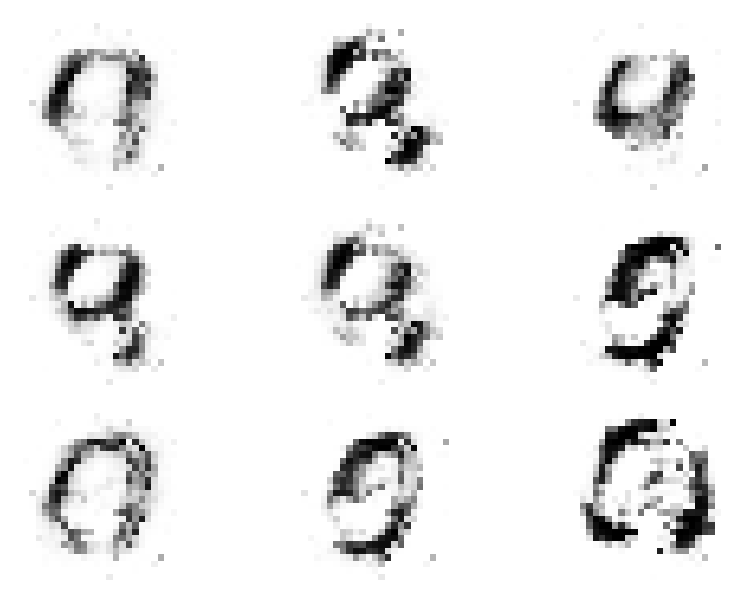

Epoch:185, Step:0, D-Loss:0.215, D-Acc:98.333, G-Loss:2.635, Wasserstein Dist:0.036
Epoch:185, Step:10, D-Loss:0.292, D-Acc:95.000, G-Loss:2.810, Wasserstein Dist:0.037
Epoch:185, Step:20, D-Loss:0.177, D-Acc:100.000, G-Loss:2.730, Wasserstein Dist:0.036
Epoch:185, Step:30, D-Loss:0.221, D-Acc:98.333, G-Loss:2.579, Wasserstein Dist:0.037
Epoch:185, Step:40, D-Loss:0.263, D-Acc:93.333, G-Loss:2.827, Wasserstein Dist:0.037
Epoch:186, Step:0, D-Loss:0.214, D-Acc:98.333, G-Loss:2.505, Wasserstein Dist:0.036
Epoch:186, Step:10, D-Loss:0.232, D-Acc:96.667, G-Loss:2.611, Wasserstein Dist:0.038
Epoch:186, Step:20, D-Loss:0.338, D-Acc:95.000, G-Loss:2.567, Wasserstein Dist:0.036
Epoch:186, Step:30, D-Loss:0.219, D-Acc:98.333, G-Loss:2.704, Wasserstein Dist:0.035
Epoch:186, Step:40, D-Loss:0.144, D-Acc:100.000, G-Loss:2.812, Wasserstein Dist:0.037
Epoch:187, Step:0, D-Loss:0.256, D-Acc:96.667, G-Loss:2.644, Wasserstein Dist:0.036
Epoch:187, Step:10, D-Loss:0.253, D-Acc:95.000, G-Loss:2.739, Wass

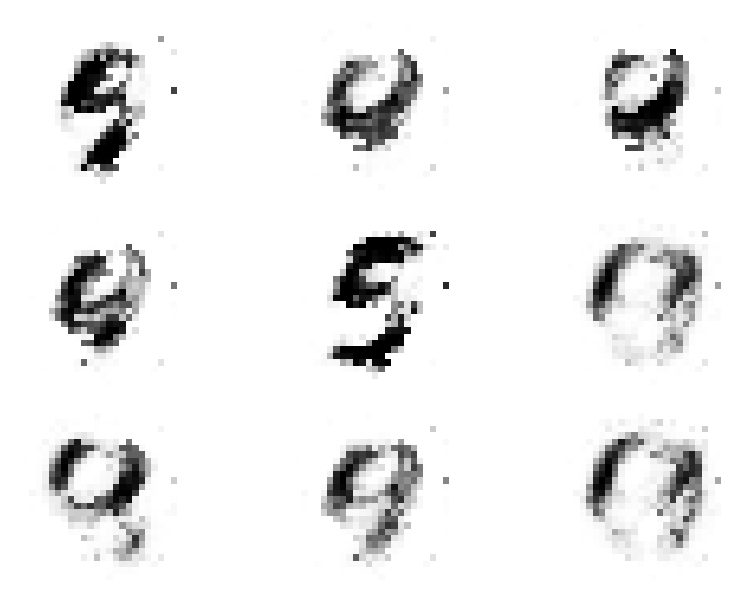

Epoch:190, Step:0, D-Loss:0.287, D-Acc:93.333, G-Loss:2.604, Wasserstein Dist:0.035
Epoch:190, Step:10, D-Loss:0.228, D-Acc:96.667, G-Loss:2.611, Wasserstein Dist:0.034
Epoch:190, Step:20, D-Loss:0.208, D-Acc:100.000, G-Loss:2.464, Wasserstein Dist:0.035
Epoch:190, Step:30, D-Loss:0.134, D-Acc:100.000, G-Loss:2.564, Wasserstein Dist:0.034
Epoch:190, Step:40, D-Loss:0.174, D-Acc:98.333, G-Loss:2.590, Wasserstein Dist:0.035
Epoch:191, Step:0, D-Loss:0.207, D-Acc:98.333, G-Loss:2.438, Wasserstein Dist:0.035
Epoch:191, Step:10, D-Loss:0.263, D-Acc:96.667, G-Loss:2.594, Wasserstein Dist:0.035
Epoch:191, Step:20, D-Loss:0.283, D-Acc:95.000, G-Loss:2.498, Wasserstein Dist:0.035
Epoch:191, Step:30, D-Loss:0.206, D-Acc:98.333, G-Loss:2.576, Wasserstein Dist:0.036
Epoch:191, Step:40, D-Loss:0.184, D-Acc:98.333, G-Loss:2.588, Wasserstein Dist:0.035
Epoch:192, Step:0, D-Loss:0.165, D-Acc:98.333, G-Loss:2.719, Wasserstein Dist:0.034
Epoch:192, Step:10, D-Loss:0.313, D-Acc:95.000, G-Loss:2.488, Wass

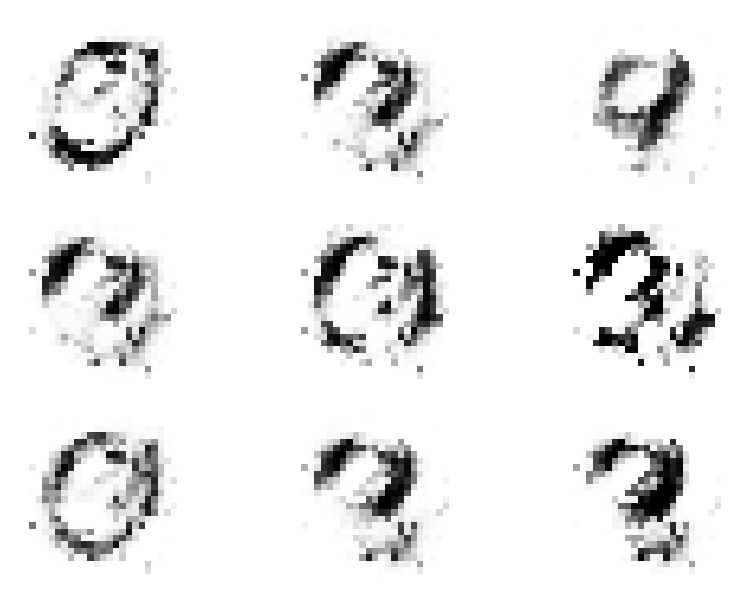

Epoch:195, Step:0, D-Loss:0.127, D-Acc:100.000, G-Loss:2.887, Wasserstein Dist:0.035
Epoch:195, Step:10, D-Loss:0.181, D-Acc:96.667, G-Loss:2.722, Wasserstein Dist:0.035
Epoch:195, Step:20, D-Loss:0.219, D-Acc:96.667, G-Loss:2.765, Wasserstein Dist:0.037
Epoch:195, Step:30, D-Loss:0.182, D-Acc:96.667, G-Loss:2.931, Wasserstein Dist:0.036
Epoch:195, Step:40, D-Loss:0.231, D-Acc:96.667, G-Loss:2.913, Wasserstein Dist:0.035
Epoch:196, Step:0, D-Loss:0.268, D-Acc:96.667, G-Loss:2.776, Wasserstein Dist:0.036
Epoch:196, Step:10, D-Loss:0.172, D-Acc:98.333, G-Loss:2.734, Wasserstein Dist:0.036
Epoch:196, Step:20, D-Loss:0.203, D-Acc:95.000, G-Loss:2.773, Wasserstein Dist:0.038
Epoch:196, Step:30, D-Loss:0.139, D-Acc:100.000, G-Loss:2.802, Wasserstein Dist:0.037
Epoch:196, Step:40, D-Loss:0.181, D-Acc:98.333, G-Loss:2.733, Wasserstein Dist:0.035
Epoch:197, Step:0, D-Loss:0.225, D-Acc:98.333, G-Loss:2.557, Wasserstein Dist:0.036
Epoch:197, Step:10, D-Loss:0.186, D-Acc:98.333, G-Loss:2.918, Wass

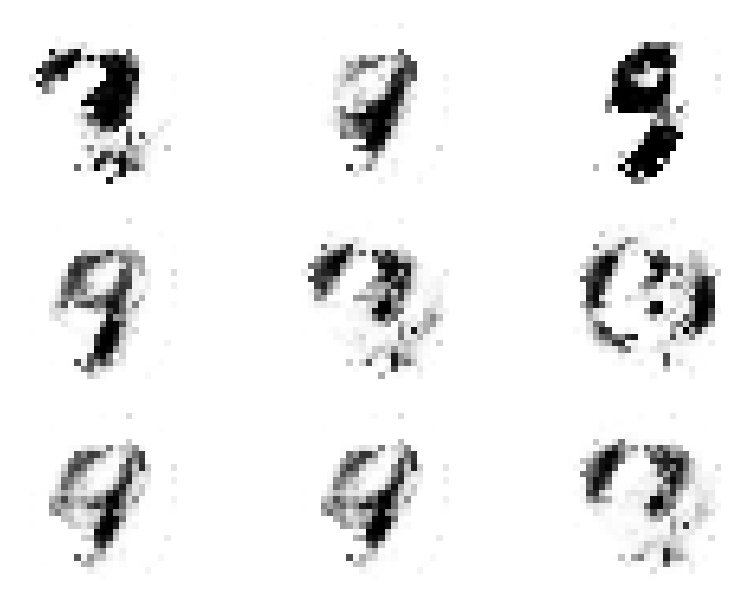

Epoch:200, Step:0, D-Loss:0.250, D-Acc:95.000, G-Loss:2.716, Wasserstein Dist:0.037
Epoch:200, Step:10, D-Loss:0.173, D-Acc:98.333, G-Loss:2.905, Wasserstein Dist:0.035
Epoch:200, Step:20, D-Loss:0.146, D-Acc:100.000, G-Loss:2.685, Wasserstein Dist:0.036
Epoch:200, Step:30, D-Loss:0.162, D-Acc:98.333, G-Loss:2.769, Wasserstein Dist:0.036
Epoch:200, Step:40, D-Loss:0.165, D-Acc:98.333, G-Loss:2.830, Wasserstein Dist:0.036
Epoch:201, Step:0, D-Loss:0.134, D-Acc:98.333, G-Loss:2.739, Wasserstein Dist:0.037
Epoch:201, Step:10, D-Loss:0.133, D-Acc:98.333, G-Loss:2.944, Wasserstein Dist:0.037
Epoch:201, Step:20, D-Loss:0.169, D-Acc:98.333, G-Loss:2.830, Wasserstein Dist:0.035
Epoch:201, Step:30, D-Loss:0.191, D-Acc:96.667, G-Loss:3.132, Wasserstein Dist:0.036
Epoch:201, Step:40, D-Loss:0.179, D-Acc:98.333, G-Loss:2.776, Wasserstein Dist:0.036
Epoch:202, Step:0, D-Loss:0.122, D-Acc:100.000, G-Loss:2.873, Wasserstein Dist:0.037
Epoch:202, Step:10, D-Loss:0.169, D-Acc:96.667, G-Loss:2.970, Wass

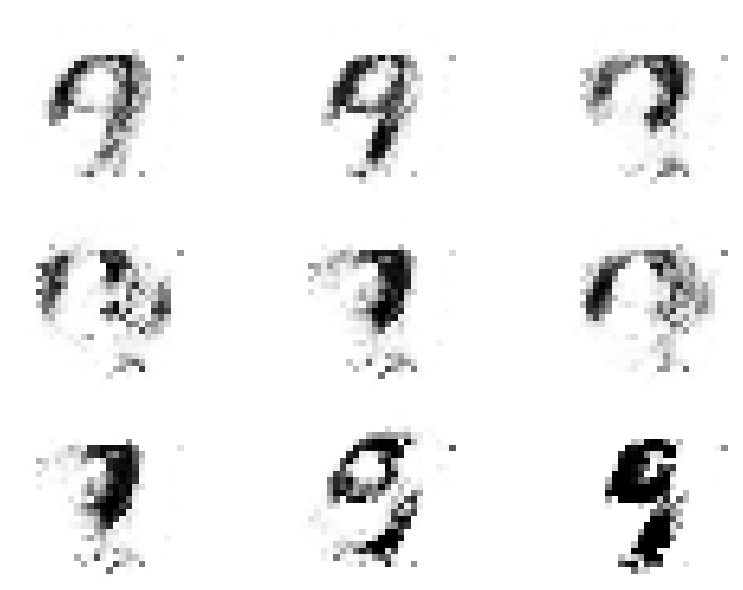

Epoch:205, Step:0, D-Loss:0.159, D-Acc:98.333, G-Loss:2.859, Wasserstein Dist:0.038
Epoch:205, Step:10, D-Loss:0.146, D-Acc:100.000, G-Loss:2.874, Wasserstein Dist:0.041
Epoch:205, Step:20, D-Loss:0.134, D-Acc:100.000, G-Loss:3.072, Wasserstein Dist:0.040
Epoch:205, Step:30, D-Loss:0.137, D-Acc:100.000, G-Loss:3.022, Wasserstein Dist:0.040
Epoch:205, Step:40, D-Loss:0.155, D-Acc:98.333, G-Loss:3.082, Wasserstein Dist:0.037
Epoch:206, Step:0, D-Loss:0.166, D-Acc:98.333, G-Loss:3.060, Wasserstein Dist:0.038
Epoch:206, Step:10, D-Loss:0.171, D-Acc:100.000, G-Loss:3.130, Wasserstein Dist:0.038
Epoch:206, Step:20, D-Loss:0.103, D-Acc:98.333, G-Loss:2.887, Wasserstein Dist:0.040
Epoch:206, Step:30, D-Loss:0.125, D-Acc:98.333, G-Loss:2.828, Wasserstein Dist:0.040
Epoch:206, Step:40, D-Loss:0.163, D-Acc:98.333, G-Loss:3.156, Wasserstein Dist:0.040
Epoch:207, Step:0, D-Loss:0.202, D-Acc:95.000, G-Loss:3.069, Wasserstein Dist:0.040
Epoch:207, Step:10, D-Loss:0.115, D-Acc:100.000, G-Loss:2.957, W

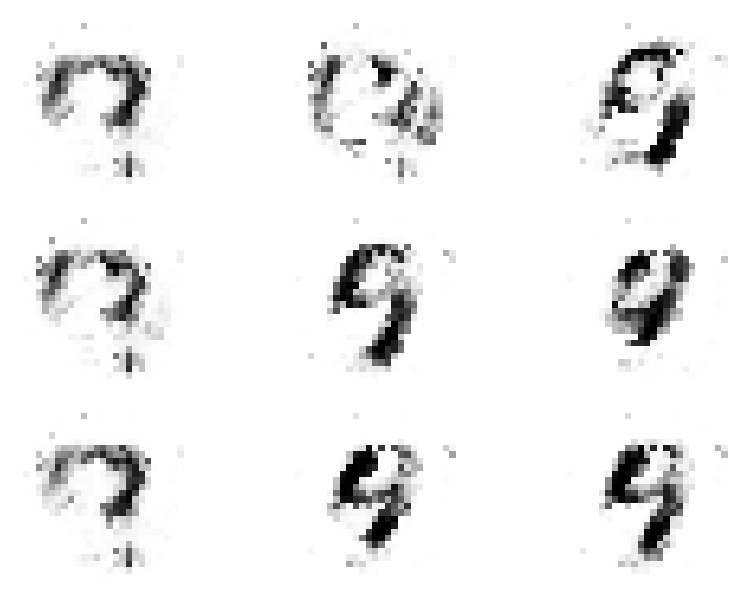

Epoch:210, Step:0, D-Loss:0.236, D-Acc:93.333, G-Loss:2.795, Wasserstein Dist:0.042
Epoch:210, Step:10, D-Loss:0.159, D-Acc:98.333, G-Loss:2.842, Wasserstein Dist:0.041
Epoch:210, Step:20, D-Loss:0.183, D-Acc:98.333, G-Loss:2.861, Wasserstein Dist:0.042
Epoch:210, Step:30, D-Loss:0.298, D-Acc:95.000, G-Loss:2.850, Wasserstein Dist:0.041
Epoch:210, Step:40, D-Loss:0.190, D-Acc:96.667, G-Loss:2.996, Wasserstein Dist:0.043
Epoch:211, Step:0, D-Loss:0.172, D-Acc:98.333, G-Loss:2.897, Wasserstein Dist:0.041
Epoch:211, Step:10, D-Loss:0.138, D-Acc:100.000, G-Loss:2.872, Wasserstein Dist:0.042
Epoch:211, Step:20, D-Loss:0.190, D-Acc:98.333, G-Loss:2.758, Wasserstein Dist:0.042
Epoch:211, Step:30, D-Loss:0.073, D-Acc:100.000, G-Loss:2.992, Wasserstein Dist:0.043
Epoch:211, Step:40, D-Loss:0.143, D-Acc:98.333, G-Loss:2.964, Wasserstein Dist:0.044
Epoch:212, Step:0, D-Loss:0.086, D-Acc:100.000, G-Loss:2.872, Wasserstein Dist:0.042
Epoch:212, Step:10, D-Loss:0.261, D-Acc:96.667, G-Loss:2.547, Was

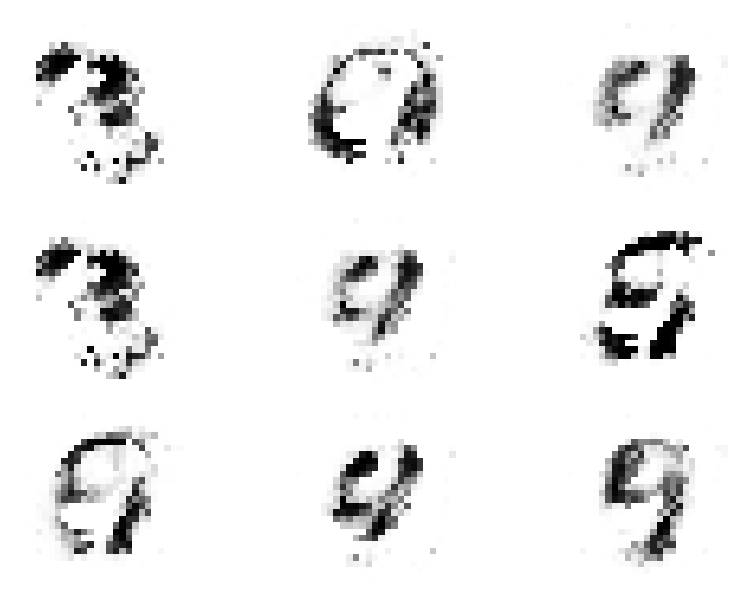

Epoch:215, Step:0, D-Loss:0.214, D-Acc:96.667, G-Loss:2.808, Wasserstein Dist:0.045
Epoch:215, Step:10, D-Loss:0.131, D-Acc:98.333, G-Loss:2.682, Wasserstein Dist:0.043
Epoch:215, Step:20, D-Loss:0.180, D-Acc:96.667, G-Loss:2.887, Wasserstein Dist:0.040
Epoch:215, Step:30, D-Loss:0.145, D-Acc:98.333, G-Loss:3.031, Wasserstein Dist:0.045
Epoch:215, Step:40, D-Loss:0.198, D-Acc:96.667, G-Loss:3.125, Wasserstein Dist:0.044
Epoch:216, Step:0, D-Loss:0.208, D-Acc:98.333, G-Loss:2.820, Wasserstein Dist:0.042
Epoch:216, Step:10, D-Loss:0.123, D-Acc:100.000, G-Loss:3.004, Wasserstein Dist:0.043
Epoch:216, Step:20, D-Loss:0.198, D-Acc:98.333, G-Loss:2.960, Wasserstein Dist:0.044
Epoch:216, Step:30, D-Loss:0.132, D-Acc:100.000, G-Loss:3.015, Wasserstein Dist:0.041
Epoch:216, Step:40, D-Loss:0.284, D-Acc:98.333, G-Loss:3.004, Wasserstein Dist:0.044
Epoch:217, Step:0, D-Loss:0.154, D-Acc:98.333, G-Loss:2.756, Wasserstein Dist:0.043
Epoch:217, Step:10, D-Loss:0.152, D-Acc:98.333, G-Loss:2.833, Wass

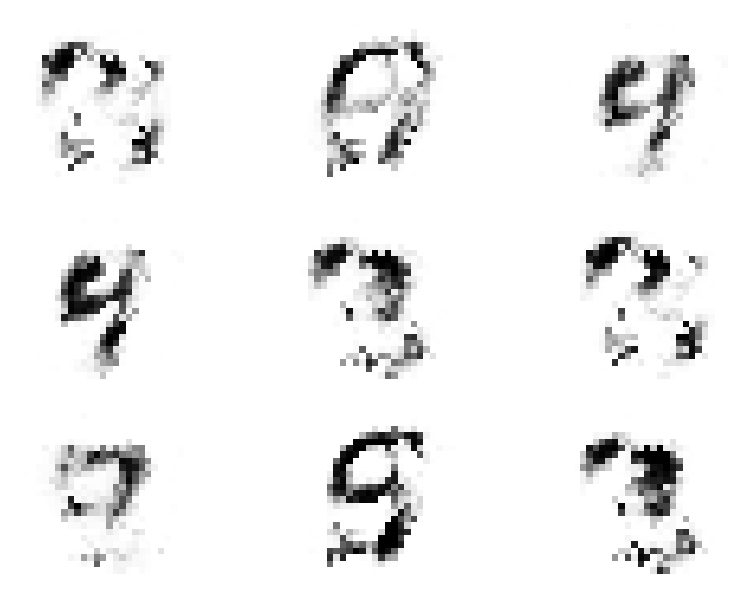

Epoch:220, Step:0, D-Loss:0.101, D-Acc:100.000, G-Loss:3.083, Wasserstein Dist:0.045
Epoch:220, Step:10, D-Loss:0.161, D-Acc:100.000, G-Loss:2.914, Wasserstein Dist:0.042
Epoch:220, Step:20, D-Loss:0.079, D-Acc:100.000, G-Loss:3.093, Wasserstein Dist:0.045
Epoch:220, Step:30, D-Loss:0.186, D-Acc:96.667, G-Loss:2.903, Wasserstein Dist:0.044
Epoch:220, Step:40, D-Loss:0.183, D-Acc:98.333, G-Loss:2.999, Wasserstein Dist:0.044
Epoch:221, Step:0, D-Loss:0.243, D-Acc:96.667, G-Loss:3.001, Wasserstein Dist:0.044
Epoch:221, Step:10, D-Loss:0.123, D-Acc:98.333, G-Loss:3.004, Wasserstein Dist:0.043
Epoch:221, Step:20, D-Loss:0.250, D-Acc:95.000, G-Loss:3.087, Wasserstein Dist:0.045
Epoch:221, Step:30, D-Loss:0.102, D-Acc:100.000, G-Loss:3.034, Wasserstein Dist:0.044
Epoch:221, Step:40, D-Loss:0.135, D-Acc:100.000, G-Loss:3.076, Wasserstein Dist:0.044
Epoch:222, Step:0, D-Loss:0.300, D-Acc:98.333, G-Loss:3.017, Wasserstein Dist:0.046
Epoch:222, Step:10, D-Loss:0.137, D-Acc:98.333, G-Loss:3.107, W

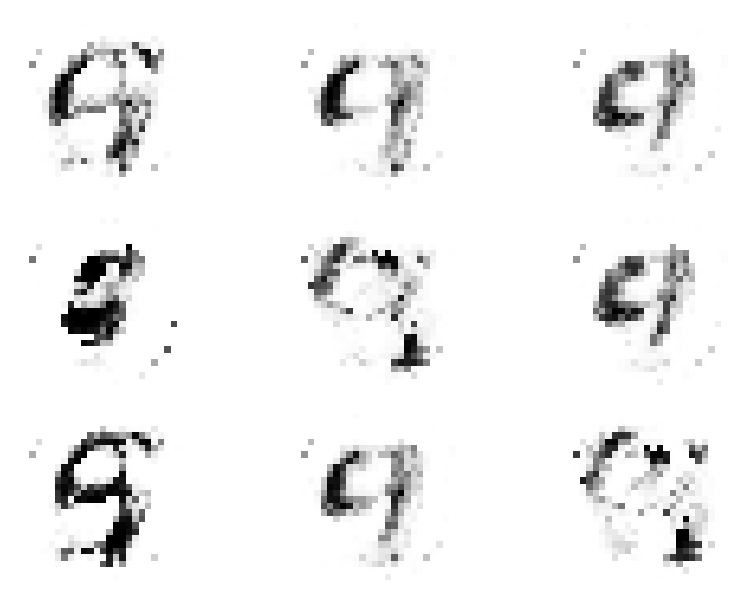

Epoch:225, Step:0, D-Loss:0.144, D-Acc:100.000, G-Loss:2.843, Wasserstein Dist:0.045
Epoch:225, Step:10, D-Loss:0.142, D-Acc:96.667, G-Loss:3.013, Wasserstein Dist:0.043
Epoch:225, Step:20, D-Loss:0.072, D-Acc:100.000, G-Loss:3.004, Wasserstein Dist:0.044
Epoch:225, Step:30, D-Loss:0.184, D-Acc:96.667, G-Loss:2.975, Wasserstein Dist:0.043
Epoch:225, Step:40, D-Loss:0.059, D-Acc:100.000, G-Loss:3.263, Wasserstein Dist:0.043
Epoch:226, Step:0, D-Loss:0.119, D-Acc:96.667, G-Loss:3.250, Wasserstein Dist:0.043
Epoch:226, Step:10, D-Loss:0.138, D-Acc:98.333, G-Loss:3.046, Wasserstein Dist:0.045
Epoch:226, Step:20, D-Loss:0.124, D-Acc:98.333, G-Loss:3.146, Wasserstein Dist:0.046
Epoch:226, Step:30, D-Loss:0.147, D-Acc:98.333, G-Loss:3.128, Wasserstein Dist:0.043
Epoch:226, Step:40, D-Loss:0.057, D-Acc:100.000, G-Loss:3.181, Wasserstein Dist:0.047
Epoch:227, Step:0, D-Loss:0.136, D-Acc:96.667, G-Loss:3.087, Wasserstein Dist:0.046
Epoch:227, Step:10, D-Loss:0.196, D-Acc:96.667, G-Loss:3.328, Wa

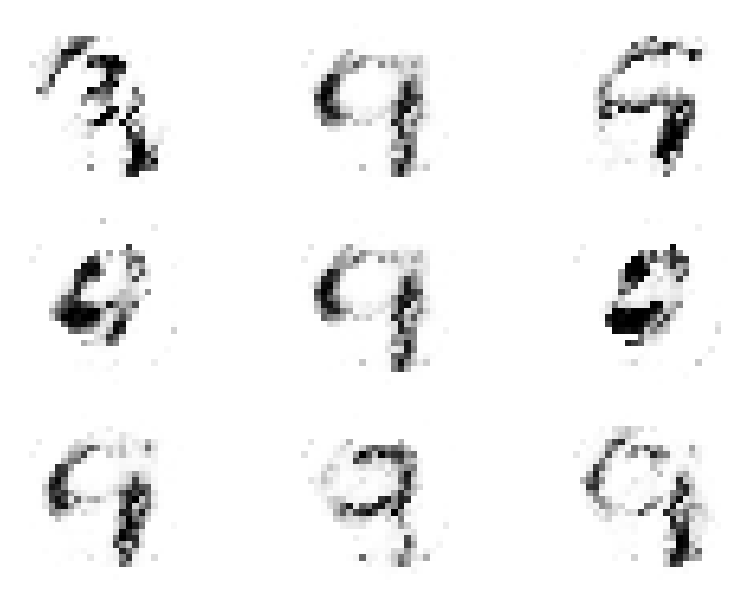

Epoch:230, Step:0, D-Loss:0.169, D-Acc:98.333, G-Loss:2.635, Wasserstein Dist:0.047
Epoch:230, Step:10, D-Loss:0.114, D-Acc:100.000, G-Loss:2.907, Wasserstein Dist:0.048
Epoch:230, Step:20, D-Loss:0.078, D-Acc:100.000, G-Loss:2.931, Wasserstein Dist:0.047
Epoch:230, Step:30, D-Loss:0.112, D-Acc:98.333, G-Loss:2.861, Wasserstein Dist:0.047
Epoch:230, Step:40, D-Loss:0.169, D-Acc:96.667, G-Loss:2.801, Wasserstein Dist:0.045
Epoch:231, Step:0, D-Loss:0.122, D-Acc:98.333, G-Loss:2.943, Wasserstein Dist:0.046
Epoch:231, Step:10, D-Loss:0.168, D-Acc:96.667, G-Loss:2.959, Wasserstein Dist:0.048
Epoch:231, Step:20, D-Loss:0.174, D-Acc:98.333, G-Loss:2.896, Wasserstein Dist:0.046
Epoch:231, Step:30, D-Loss:0.263, D-Acc:96.667, G-Loss:2.886, Wasserstein Dist:0.047
Epoch:231, Step:40, D-Loss:0.111, D-Acc:100.000, G-Loss:3.062, Wasserstein Dist:0.046
Epoch:232, Step:0, D-Loss:0.166, D-Acc:98.333, G-Loss:2.906, Wasserstein Dist:0.048
Epoch:232, Step:10, D-Loss:0.126, D-Acc:98.333, G-Loss:3.003, Was

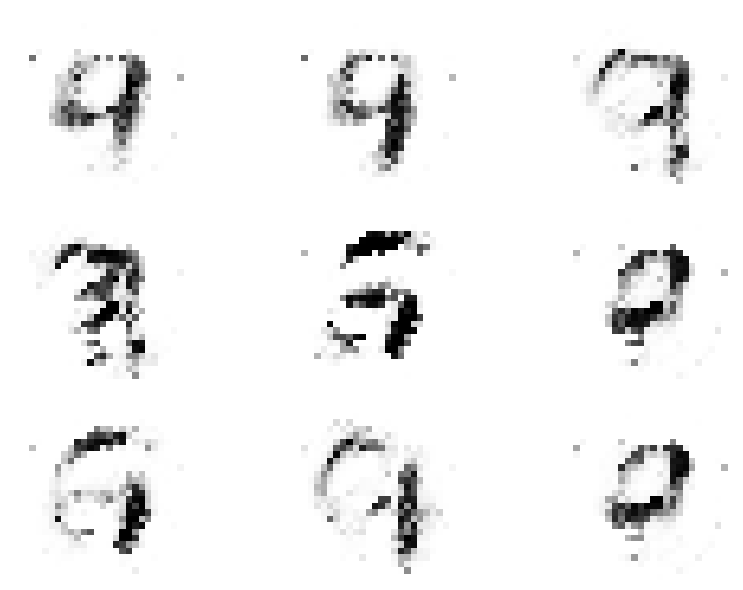

Epoch:235, Step:0, D-Loss:0.090, D-Acc:100.000, G-Loss:2.906, Wasserstein Dist:0.046
Epoch:235, Step:10, D-Loss:0.146, D-Acc:98.333, G-Loss:3.114, Wasserstein Dist:0.047
Epoch:235, Step:20, D-Loss:0.066, D-Acc:100.000, G-Loss:3.243, Wasserstein Dist:0.045
Epoch:235, Step:30, D-Loss:0.085, D-Acc:100.000, G-Loss:3.118, Wasserstein Dist:0.046
Epoch:235, Step:40, D-Loss:0.102, D-Acc:98.333, G-Loss:3.175, Wasserstein Dist:0.047
Epoch:236, Step:0, D-Loss:0.174, D-Acc:98.333, G-Loss:3.225, Wasserstein Dist:0.047
Epoch:236, Step:10, D-Loss:0.095, D-Acc:100.000, G-Loss:3.088, Wasserstein Dist:0.048
Epoch:236, Step:20, D-Loss:0.113, D-Acc:100.000, G-Loss:3.385, Wasserstein Dist:0.046
Epoch:236, Step:30, D-Loss:0.098, D-Acc:98.333, G-Loss:3.308, Wasserstein Dist:0.045
Epoch:236, Step:40, D-Loss:0.096, D-Acc:100.000, G-Loss:3.085, Wasserstein Dist:0.049
Epoch:237, Step:0, D-Loss:0.175, D-Acc:98.333, G-Loss:3.138, Wasserstein Dist:0.043
Epoch:237, Step:10, D-Loss:0.121, D-Acc:100.000, G-Loss:3.130,

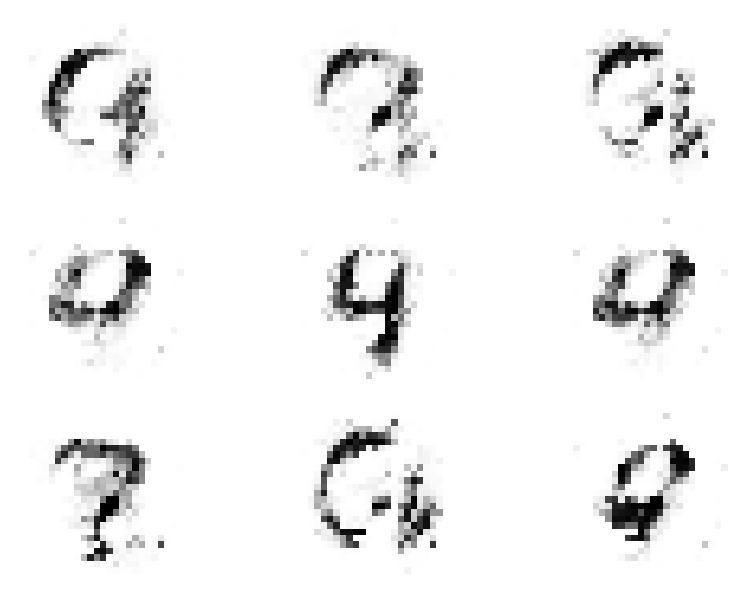

Epoch:240, Step:0, D-Loss:0.137, D-Acc:98.333, G-Loss:2.945, Wasserstein Dist:0.045
Epoch:240, Step:10, D-Loss:0.142, D-Acc:100.000, G-Loss:2.981, Wasserstein Dist:0.040
Epoch:240, Step:20, D-Loss:0.105, D-Acc:100.000, G-Loss:2.809, Wasserstein Dist:0.042
Epoch:240, Step:30, D-Loss:0.130, D-Acc:100.000, G-Loss:3.099, Wasserstein Dist:0.041
Epoch:240, Step:40, D-Loss:0.137, D-Acc:100.000, G-Loss:2.972, Wasserstein Dist:0.040
Epoch:241, Step:0, D-Loss:0.108, D-Acc:100.000, G-Loss:3.014, Wasserstein Dist:0.041
Epoch:241, Step:10, D-Loss:0.214, D-Acc:96.667, G-Loss:3.102, Wasserstein Dist:0.041
Epoch:241, Step:20, D-Loss:0.260, D-Acc:95.000, G-Loss:2.942, Wasserstein Dist:0.041
Epoch:241, Step:30, D-Loss:0.217, D-Acc:96.667, G-Loss:2.767, Wasserstein Dist:0.040
Epoch:241, Step:40, D-Loss:0.192, D-Acc:96.667, G-Loss:3.128, Wasserstein Dist:0.040
Epoch:242, Step:0, D-Loss:0.175, D-Acc:96.667, G-Loss:2.986, Wasserstein Dist:0.040
Epoch:242, Step:10, D-Loss:0.288, D-Acc:95.000, G-Loss:2.854, W

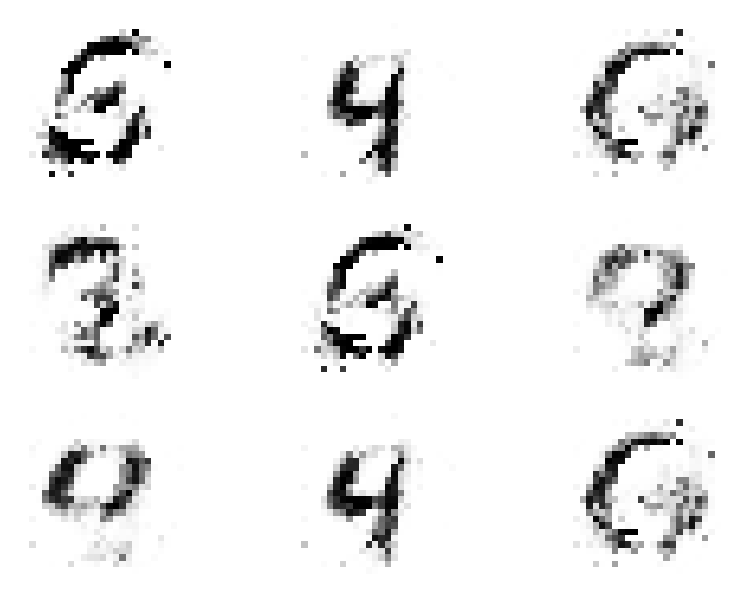

Epoch:245, Step:0, D-Loss:0.161, D-Acc:98.333, G-Loss:3.240, Wasserstein Dist:0.038
Epoch:245, Step:10, D-Loss:0.082, D-Acc:100.000, G-Loss:3.456, Wasserstein Dist:0.039
Epoch:245, Step:20, D-Loss:0.150, D-Acc:98.333, G-Loss:3.466, Wasserstein Dist:0.039
Epoch:245, Step:30, D-Loss:0.103, D-Acc:100.000, G-Loss:3.444, Wasserstein Dist:0.037
Epoch:245, Step:40, D-Loss:0.112, D-Acc:100.000, G-Loss:3.363, Wasserstein Dist:0.041
Epoch:246, Step:0, D-Loss:0.124, D-Acc:100.000, G-Loss:3.146, Wasserstein Dist:0.037
Epoch:246, Step:10, D-Loss:0.170, D-Acc:98.333, G-Loss:3.264, Wasserstein Dist:0.037
Epoch:246, Step:20, D-Loss:0.059, D-Acc:100.000, G-Loss:3.362, Wasserstein Dist:0.038
Epoch:246, Step:30, D-Loss:0.109, D-Acc:100.000, G-Loss:3.404, Wasserstein Dist:0.038
Epoch:246, Step:40, D-Loss:0.075, D-Acc:100.000, G-Loss:3.440, Wasserstein Dist:0.037
Epoch:247, Step:0, D-Loss:0.241, D-Acc:96.667, G-Loss:3.264, Wasserstein Dist:0.037
Epoch:247, Step:10, D-Loss:0.213, D-Acc:96.667, G-Loss:3.026,

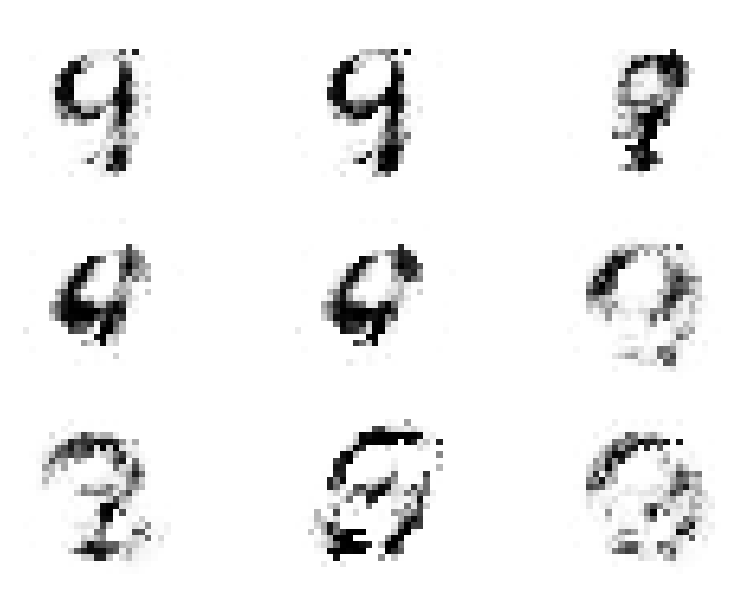

Epoch:250, Step:0, D-Loss:0.100, D-Acc:100.000, G-Loss:3.068, Wasserstein Dist:0.037
Epoch:250, Step:10, D-Loss:0.085, D-Acc:100.000, G-Loss:3.186, Wasserstein Dist:0.035
Epoch:250, Step:20, D-Loss:0.231, D-Acc:96.667, G-Loss:3.266, Wasserstein Dist:0.036
Epoch:250, Step:30, D-Loss:0.085, D-Acc:100.000, G-Loss:3.174, Wasserstein Dist:0.034
Epoch:250, Step:40, D-Loss:0.105, D-Acc:100.000, G-Loss:3.124, Wasserstein Dist:0.035
Epoch:251, Step:0, D-Loss:0.132, D-Acc:98.333, G-Loss:2.992, Wasserstein Dist:0.034
Epoch:251, Step:10, D-Loss:0.128, D-Acc:98.333, G-Loss:3.151, Wasserstein Dist:0.034
Epoch:251, Step:20, D-Loss:0.100, D-Acc:98.333, G-Loss:3.278, Wasserstein Dist:0.034
Epoch:251, Step:30, D-Loss:0.145, D-Acc:98.333, G-Loss:3.119, Wasserstein Dist:0.032
Epoch:251, Step:40, D-Loss:0.067, D-Acc:100.000, G-Loss:3.095, Wasserstein Dist:0.033
Epoch:252, Step:0, D-Loss:0.122, D-Acc:98.333, G-Loss:3.212, Wasserstein Dist:0.034
Epoch:252, Step:10, D-Loss:0.107, D-Acc:98.333, G-Loss:3.140, W

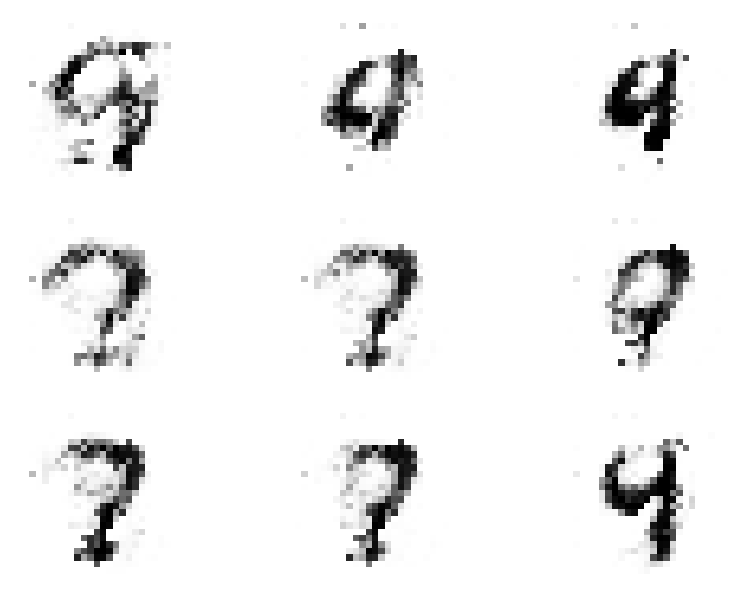

Epoch:255, Step:0, D-Loss:0.141, D-Acc:98.333, G-Loss:3.170, Wasserstein Dist:0.032
Epoch:255, Step:10, D-Loss:0.165, D-Acc:96.667, G-Loss:3.233, Wasserstein Dist:0.030
Epoch:255, Step:20, D-Loss:0.109, D-Acc:98.333, G-Loss:3.097, Wasserstein Dist:0.031
Epoch:255, Step:30, D-Loss:0.124, D-Acc:96.667, G-Loss:3.325, Wasserstein Dist:0.030
Epoch:255, Step:40, D-Loss:0.106, D-Acc:100.000, G-Loss:3.363, Wasserstein Dist:0.032
Epoch:256, Step:0, D-Loss:0.083, D-Acc:100.000, G-Loss:3.382, Wasserstein Dist:0.031
Epoch:256, Step:10, D-Loss:0.153, D-Acc:98.333, G-Loss:3.456, Wasserstein Dist:0.031
Epoch:256, Step:20, D-Loss:0.167, D-Acc:95.000, G-Loss:3.293, Wasserstein Dist:0.030
Epoch:256, Step:30, D-Loss:0.096, D-Acc:100.000, G-Loss:3.091, Wasserstein Dist:0.030
Epoch:256, Step:40, D-Loss:0.174, D-Acc:96.667, G-Loss:3.261, Wasserstein Dist:0.030
Epoch:257, Step:0, D-Loss:0.162, D-Acc:98.333, G-Loss:3.308, Wasserstein Dist:0.031
Epoch:257, Step:10, D-Loss:0.166, D-Acc:98.333, G-Loss:3.485, Was

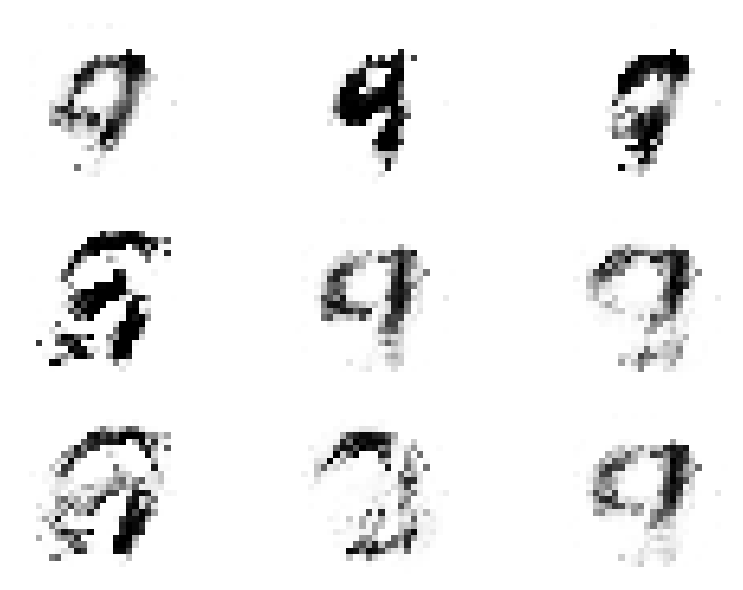

Epoch:260, Step:0, D-Loss:0.115, D-Acc:98.333, G-Loss:3.161, Wasserstein Dist:0.031
Epoch:260, Step:10, D-Loss:0.069, D-Acc:100.000, G-Loss:3.450, Wasserstein Dist:0.031
Epoch:260, Step:20, D-Loss:0.081, D-Acc:100.000, G-Loss:3.458, Wasserstein Dist:0.029
Epoch:260, Step:30, D-Loss:0.147, D-Acc:98.333, G-Loss:3.420, Wasserstein Dist:0.029
Epoch:260, Step:40, D-Loss:0.063, D-Acc:100.000, G-Loss:3.294, Wasserstein Dist:0.032
Epoch:261, Step:0, D-Loss:0.160, D-Acc:98.333, G-Loss:3.256, Wasserstein Dist:0.032
Epoch:261, Step:10, D-Loss:0.069, D-Acc:100.000, G-Loss:3.211, Wasserstein Dist:0.031
Epoch:261, Step:20, D-Loss:0.097, D-Acc:100.000, G-Loss:3.348, Wasserstein Dist:0.030
Epoch:261, Step:30, D-Loss:0.145, D-Acc:98.333, G-Loss:3.341, Wasserstein Dist:0.030
Epoch:261, Step:40, D-Loss:0.187, D-Acc:96.667, G-Loss:3.054, Wasserstein Dist:0.030
Epoch:262, Step:0, D-Loss:0.114, D-Acc:98.333, G-Loss:3.198, Wasserstein Dist:0.032
Epoch:262, Step:10, D-Loss:0.072, D-Acc:100.000, G-Loss:3.331, 

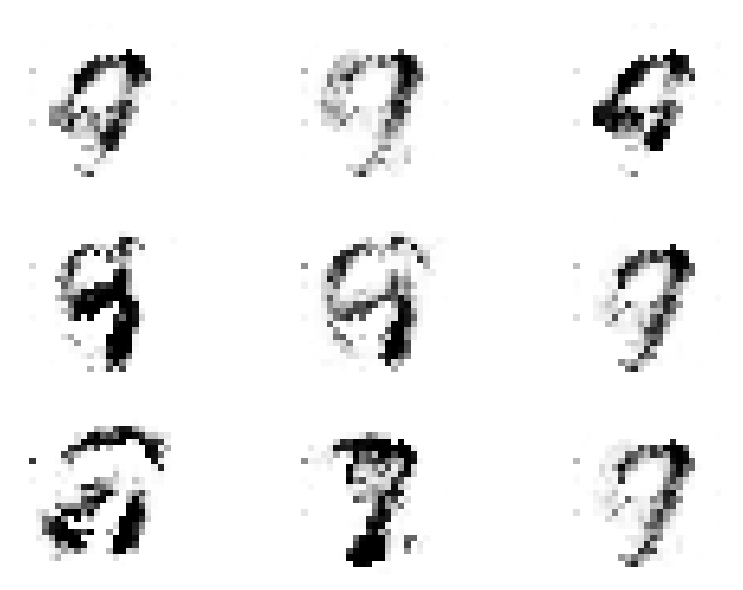

Epoch:265, Step:0, D-Loss:0.164, D-Acc:96.667, G-Loss:3.046, Wasserstein Dist:0.033
Epoch:265, Step:10, D-Loss:0.146, D-Acc:98.333, G-Loss:3.350, Wasserstein Dist:0.030
Epoch:265, Step:20, D-Loss:0.083, D-Acc:98.333, G-Loss:3.463, Wasserstein Dist:0.031
Epoch:265, Step:30, D-Loss:0.101, D-Acc:100.000, G-Loss:3.490, Wasserstein Dist:0.031
Epoch:265, Step:40, D-Loss:0.132, D-Acc:96.667, G-Loss:3.523, Wasserstein Dist:0.032
Epoch:266, Step:0, D-Loss:0.097, D-Acc:98.333, G-Loss:3.229, Wasserstein Dist:0.029
Epoch:266, Step:10, D-Loss:0.074, D-Acc:100.000, G-Loss:3.363, Wasserstein Dist:0.032
Epoch:266, Step:20, D-Loss:0.186, D-Acc:96.667, G-Loss:3.185, Wasserstein Dist:0.031
Epoch:266, Step:30, D-Loss:0.180, D-Acc:96.667, G-Loss:3.306, Wasserstein Dist:0.031
Epoch:266, Step:40, D-Loss:0.086, D-Acc:100.000, G-Loss:3.171, Wasserstein Dist:0.030
Epoch:267, Step:0, D-Loss:0.115, D-Acc:98.333, G-Loss:3.507, Wasserstein Dist:0.030
Epoch:267, Step:10, D-Loss:0.069, D-Acc:100.000, G-Loss:3.458, Wa

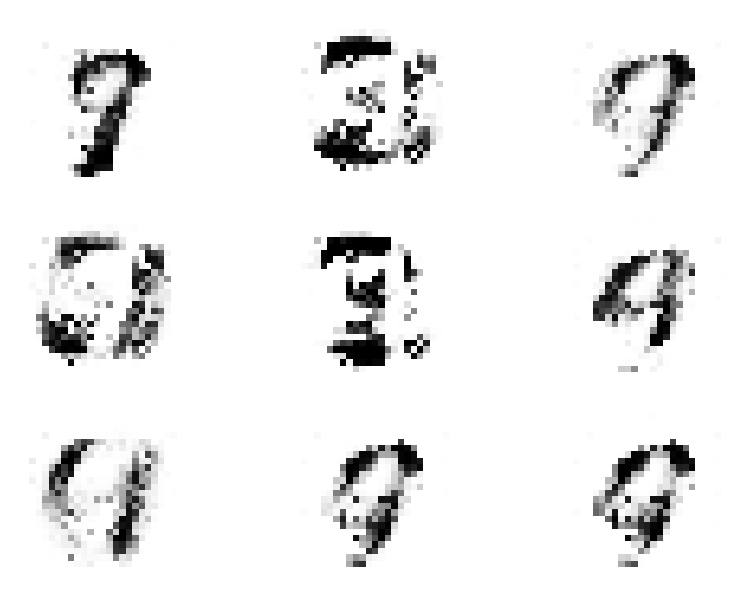

Epoch:270, Step:0, D-Loss:0.189, D-Acc:98.333, G-Loss:3.203, Wasserstein Dist:0.034
Epoch:270, Step:10, D-Loss:0.227, D-Acc:95.000, G-Loss:3.451, Wasserstein Dist:0.032
Epoch:270, Step:20, D-Loss:0.136, D-Acc:98.333, G-Loss:3.136, Wasserstein Dist:0.031
Epoch:270, Step:30, D-Loss:0.111, D-Acc:100.000, G-Loss:3.453, Wasserstein Dist:0.034
Epoch:270, Step:40, D-Loss:0.064, D-Acc:100.000, G-Loss:3.176, Wasserstein Dist:0.033
Epoch:271, Step:0, D-Loss:0.099, D-Acc:100.000, G-Loss:3.441, Wasserstein Dist:0.031
Epoch:271, Step:10, D-Loss:0.093, D-Acc:100.000, G-Loss:3.004, Wasserstein Dist:0.031
Epoch:271, Step:20, D-Loss:0.121, D-Acc:98.333, G-Loss:3.438, Wasserstein Dist:0.032
Epoch:271, Step:30, D-Loss:0.102, D-Acc:100.000, G-Loss:2.981, Wasserstein Dist:0.030
Epoch:271, Step:40, D-Loss:0.053, D-Acc:100.000, G-Loss:3.447, Wasserstein Dist:0.032
Epoch:272, Step:0, D-Loss:0.086, D-Acc:100.000, G-Loss:3.302, Wasserstein Dist:0.031
Epoch:272, Step:10, D-Loss:0.057, D-Acc:100.000, G-Loss:3.403

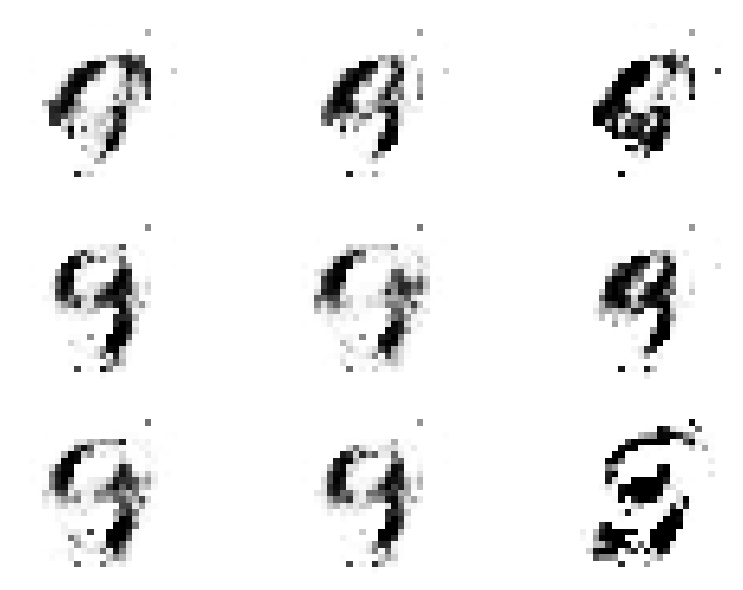

Epoch:275, Step:0, D-Loss:0.084, D-Acc:98.333, G-Loss:3.397, Wasserstein Dist:0.029
Epoch:275, Step:10, D-Loss:0.043, D-Acc:100.000, G-Loss:3.572, Wasserstein Dist:0.030
Epoch:275, Step:20, D-Loss:0.047, D-Acc:100.000, G-Loss:3.644, Wasserstein Dist:0.032
Epoch:275, Step:30, D-Loss:0.117, D-Acc:98.333, G-Loss:3.503, Wasserstein Dist:0.032
Epoch:275, Step:40, D-Loss:0.084, D-Acc:100.000, G-Loss:3.483, Wasserstein Dist:0.033
Epoch:276, Step:0, D-Loss:0.205, D-Acc:95.000, G-Loss:3.249, Wasserstein Dist:0.031
Epoch:276, Step:10, D-Loss:0.152, D-Acc:96.667, G-Loss:3.517, Wasserstein Dist:0.032
Epoch:276, Step:20, D-Loss:0.139, D-Acc:98.333, G-Loss:3.342, Wasserstein Dist:0.032
Epoch:276, Step:30, D-Loss:0.047, D-Acc:100.000, G-Loss:3.457, Wasserstein Dist:0.032
Epoch:276, Step:40, D-Loss:0.136, D-Acc:96.667, G-Loss:3.551, Wasserstein Dist:0.035
Epoch:277, Step:0, D-Loss:0.100, D-Acc:100.000, G-Loss:3.243, Wasserstein Dist:0.030
Epoch:277, Step:10, D-Loss:0.065, D-Acc:100.000, G-Loss:3.349, 

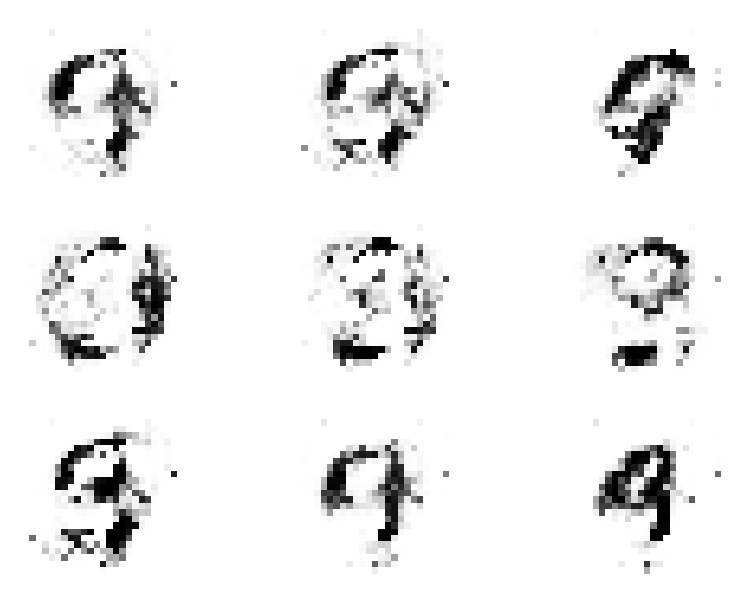

Epoch:280, Step:0, D-Loss:0.112, D-Acc:100.000, G-Loss:3.358, Wasserstein Dist:0.035
Epoch:280, Step:10, D-Loss:0.065, D-Acc:100.000, G-Loss:3.564, Wasserstein Dist:0.034
Epoch:280, Step:20, D-Loss:0.080, D-Acc:100.000, G-Loss:3.557, Wasserstein Dist:0.034
Epoch:280, Step:30, D-Loss:0.108, D-Acc:98.333, G-Loss:3.543, Wasserstein Dist:0.034
Epoch:280, Step:40, D-Loss:0.141, D-Acc:98.333, G-Loss:3.533, Wasserstein Dist:0.034
Epoch:281, Step:0, D-Loss:0.064, D-Acc:100.000, G-Loss:3.320, Wasserstein Dist:0.034
Epoch:281, Step:10, D-Loss:0.180, D-Acc:96.667, G-Loss:3.124, Wasserstein Dist:0.033
Epoch:281, Step:20, D-Loss:0.052, D-Acc:100.000, G-Loss:3.277, Wasserstein Dist:0.035
Epoch:281, Step:30, D-Loss:0.149, D-Acc:98.333, G-Loss:3.157, Wasserstein Dist:0.033
Epoch:281, Step:40, D-Loss:0.152, D-Acc:100.000, G-Loss:3.355, Wasserstein Dist:0.032
Epoch:282, Step:0, D-Loss:0.167, D-Acc:96.667, G-Loss:3.397, Wasserstein Dist:0.036
Epoch:282, Step:10, D-Loss:0.131, D-Acc:98.333, G-Loss:3.104, 

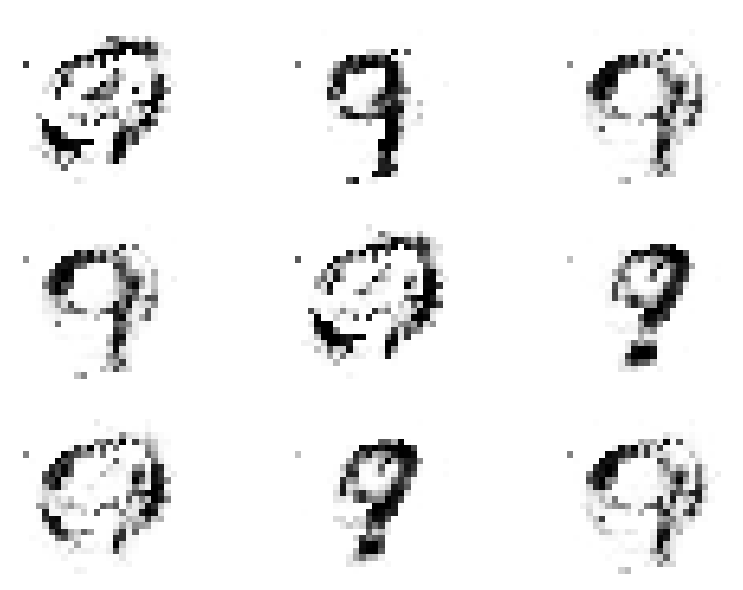

Epoch:285, Step:0, D-Loss:0.218, D-Acc:98.333, G-Loss:3.308, Wasserstein Dist:0.029
Epoch:285, Step:10, D-Loss:0.101, D-Acc:100.000, G-Loss:3.604, Wasserstein Dist:0.031
Epoch:285, Step:20, D-Loss:0.147, D-Acc:96.667, G-Loss:3.386, Wasserstein Dist:0.031
Epoch:285, Step:30, D-Loss:0.126, D-Acc:98.333, G-Loss:3.776, Wasserstein Dist:0.030
Epoch:285, Step:40, D-Loss:0.106, D-Acc:98.333, G-Loss:3.869, Wasserstein Dist:0.033
Epoch:286, Step:0, D-Loss:0.043, D-Acc:100.000, G-Loss:3.356, Wasserstein Dist:0.032
Epoch:286, Step:10, D-Loss:0.056, D-Acc:100.000, G-Loss:3.816, Wasserstein Dist:0.030
Epoch:286, Step:20, D-Loss:0.191, D-Acc:96.667, G-Loss:3.536, Wasserstein Dist:0.029
Epoch:286, Step:30, D-Loss:0.115, D-Acc:100.000, G-Loss:3.684, Wasserstein Dist:0.031
Epoch:286, Step:40, D-Loss:0.073, D-Acc:100.000, G-Loss:3.502, Wasserstein Dist:0.030
Epoch:287, Step:0, D-Loss:0.067, D-Acc:100.000, G-Loss:3.664, Wasserstein Dist:0.031
Epoch:287, Step:10, D-Loss:0.098, D-Acc:98.333, G-Loss:3.698, 

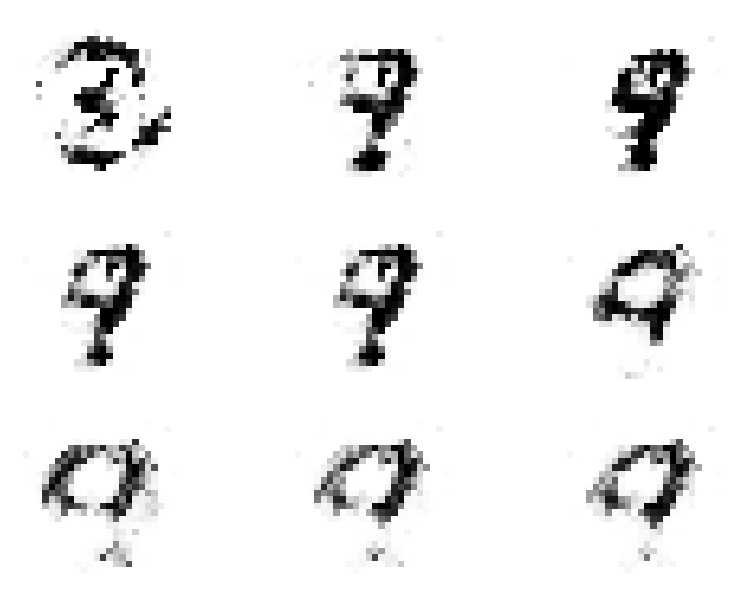

Epoch:290, Step:0, D-Loss:0.113, D-Acc:98.333, G-Loss:3.776, Wasserstein Dist:0.027
Epoch:290, Step:10, D-Loss:0.140, D-Acc:96.667, G-Loss:3.562, Wasserstein Dist:0.027
Epoch:290, Step:20, D-Loss:0.067, D-Acc:100.000, G-Loss:3.808, Wasserstein Dist:0.027
Epoch:290, Step:30, D-Loss:0.112, D-Acc:100.000, G-Loss:3.316, Wasserstein Dist:0.028
Epoch:290, Step:40, D-Loss:0.137, D-Acc:98.333, G-Loss:3.708, Wasserstein Dist:0.027
Epoch:291, Step:0, D-Loss:0.208, D-Acc:95.000, G-Loss:3.355, Wasserstein Dist:0.025
Epoch:291, Step:10, D-Loss:0.106, D-Acc:98.333, G-Loss:3.595, Wasserstein Dist:0.026
Epoch:291, Step:20, D-Loss:0.084, D-Acc:100.000, G-Loss:3.635, Wasserstein Dist:0.025
Epoch:291, Step:30, D-Loss:0.070, D-Acc:100.000, G-Loss:3.644, Wasserstein Dist:0.025
Epoch:291, Step:40, D-Loss:0.063, D-Acc:100.000, G-Loss:3.880, Wasserstein Dist:0.024
Epoch:292, Step:0, D-Loss:0.149, D-Acc:98.333, G-Loss:3.509, Wasserstein Dist:0.025
Epoch:292, Step:10, D-Loss:0.113, D-Acc:98.333, G-Loss:3.608, W

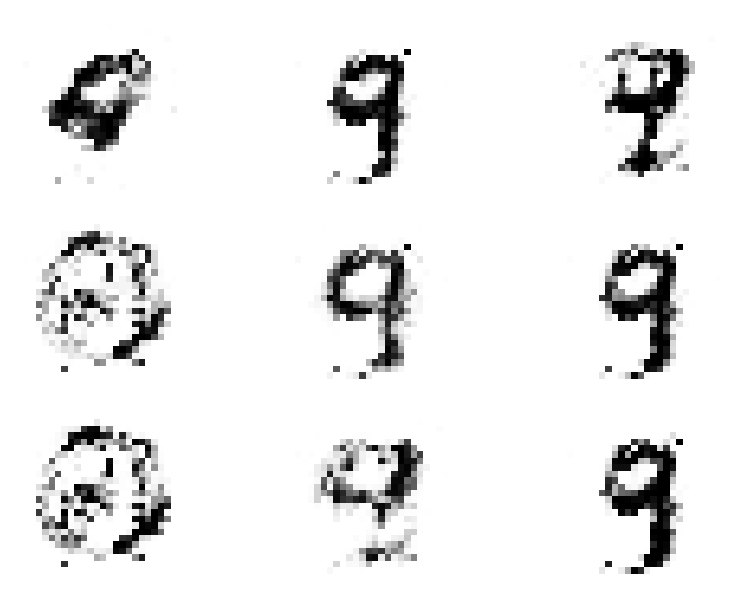

Epoch:295, Step:0, D-Loss:0.063, D-Acc:100.000, G-Loss:3.788, Wasserstein Dist:0.022
Epoch:295, Step:10, D-Loss:0.031, D-Acc:100.000, G-Loss:3.794, Wasserstein Dist:0.021
Epoch:295, Step:20, D-Loss:0.095, D-Acc:98.333, G-Loss:3.462, Wasserstein Dist:0.021
Epoch:295, Step:30, D-Loss:0.122, D-Acc:98.333, G-Loss:3.495, Wasserstein Dist:0.020
Epoch:295, Step:40, D-Loss:0.060, D-Acc:100.000, G-Loss:3.679, Wasserstein Dist:0.020
Epoch:296, Step:0, D-Loss:0.072, D-Acc:100.000, G-Loss:3.433, Wasserstein Dist:0.019
Epoch:296, Step:10, D-Loss:0.105, D-Acc:98.333, G-Loss:3.476, Wasserstein Dist:0.020
Epoch:296, Step:20, D-Loss:0.152, D-Acc:96.667, G-Loss:3.349, Wasserstein Dist:0.021
Epoch:296, Step:30, D-Loss:0.087, D-Acc:98.333, G-Loss:3.746, Wasserstein Dist:0.020
Epoch:296, Step:40, D-Loss:0.038, D-Acc:100.000, G-Loss:3.563, Wasserstein Dist:0.022
Epoch:297, Step:0, D-Loss:0.183, D-Acc:96.667, G-Loss:3.504, Wasserstein Dist:0.022
Epoch:297, Step:10, D-Loss:0.142, D-Acc:98.333, G-Loss:3.526, W

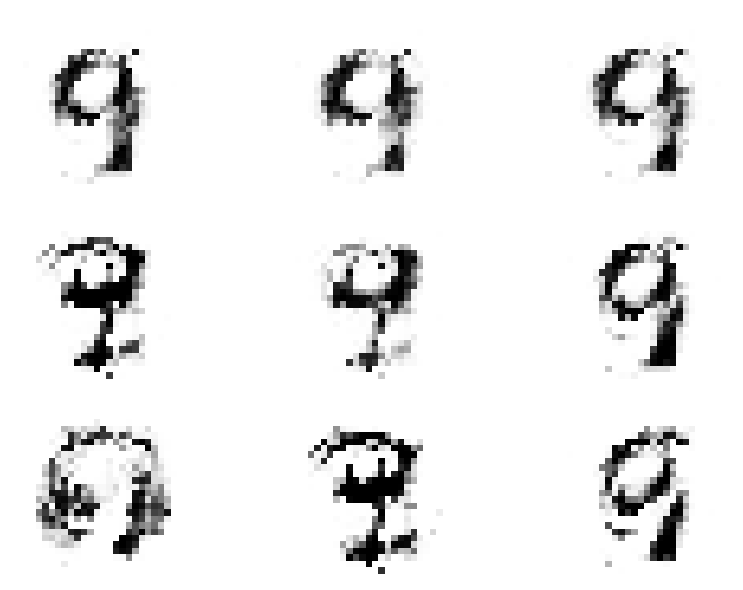

Epoch:300, Step:0, D-Loss:0.183, D-Acc:96.667, G-Loss:3.202, Wasserstein Dist:0.022
Epoch:300, Step:10, D-Loss:0.056, D-Acc:100.000, G-Loss:3.301, Wasserstein Dist:0.021
Epoch:300, Step:20, D-Loss:0.045, D-Acc:100.000, G-Loss:3.709, Wasserstein Dist:0.021
Epoch:300, Step:30, D-Loss:0.161, D-Acc:95.000, G-Loss:3.337, Wasserstein Dist:0.024
Epoch:300, Step:40, D-Loss:0.096, D-Acc:98.333, G-Loss:3.505, Wasserstein Dist:0.022
Epoch:301, Step:0, D-Loss:0.093, D-Acc:98.333, G-Loss:3.422, Wasserstein Dist:0.023
Epoch:301, Step:10, D-Loss:0.122, D-Acc:96.667, G-Loss:3.382, Wasserstein Dist:0.025
Epoch:301, Step:20, D-Loss:0.229, D-Acc:95.000, G-Loss:3.384, Wasserstein Dist:0.022
Epoch:301, Step:30, D-Loss:0.208, D-Acc:95.000, G-Loss:3.534, Wasserstein Dist:0.022
Epoch:301, Step:40, D-Loss:0.092, D-Acc:98.333, G-Loss:3.893, Wasserstein Dist:0.023
Epoch:302, Step:0, D-Loss:0.079, D-Acc:100.000, G-Loss:3.745, Wasserstein Dist:0.023
Epoch:302, Step:10, D-Loss:0.099, D-Acc:98.333, G-Loss:3.481, Was

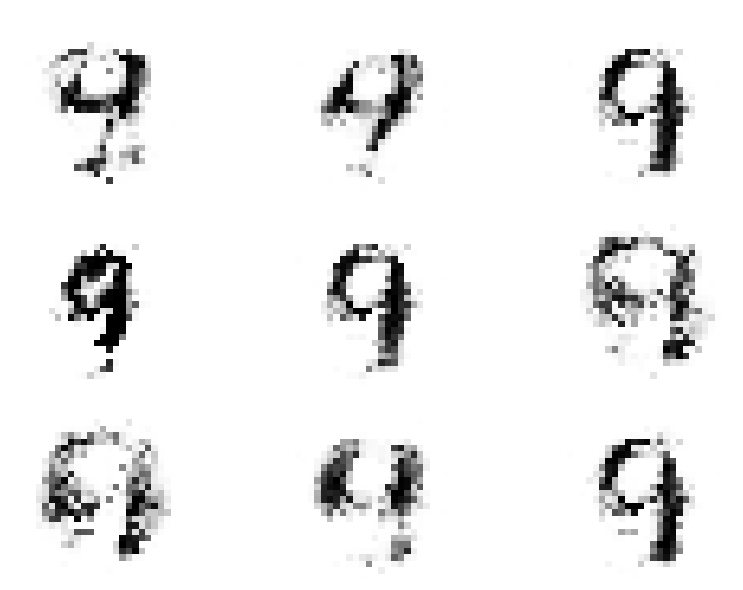

Epoch:305, Step:0, D-Loss:0.127, D-Acc:98.333, G-Loss:3.432, Wasserstein Dist:0.027
Epoch:305, Step:10, D-Loss:0.071, D-Acc:100.000, G-Loss:3.354, Wasserstein Dist:0.027
Epoch:305, Step:20, D-Loss:0.184, D-Acc:96.667, G-Loss:3.505, Wasserstein Dist:0.027
Epoch:305, Step:30, D-Loss:0.097, D-Acc:100.000, G-Loss:3.293, Wasserstein Dist:0.025
Epoch:305, Step:40, D-Loss:0.082, D-Acc:100.000, G-Loss:3.318, Wasserstein Dist:0.028
Epoch:306, Step:0, D-Loss:0.082, D-Acc:100.000, G-Loss:3.252, Wasserstein Dist:0.026
Epoch:306, Step:10, D-Loss:0.050, D-Acc:100.000, G-Loss:3.206, Wasserstein Dist:0.028
Epoch:306, Step:20, D-Loss:0.058, D-Acc:100.000, G-Loss:3.452, Wasserstein Dist:0.028
Epoch:306, Step:30, D-Loss:0.119, D-Acc:96.667, G-Loss:3.466, Wasserstein Dist:0.027
Epoch:306, Step:40, D-Loss:0.061, D-Acc:100.000, G-Loss:3.314, Wasserstein Dist:0.027
Epoch:307, Step:0, D-Loss:0.103, D-Acc:98.333, G-Loss:3.583, Wasserstein Dist:0.028
Epoch:307, Step:10, D-Loss:0.062, D-Acc:100.000, G-Loss:3.499

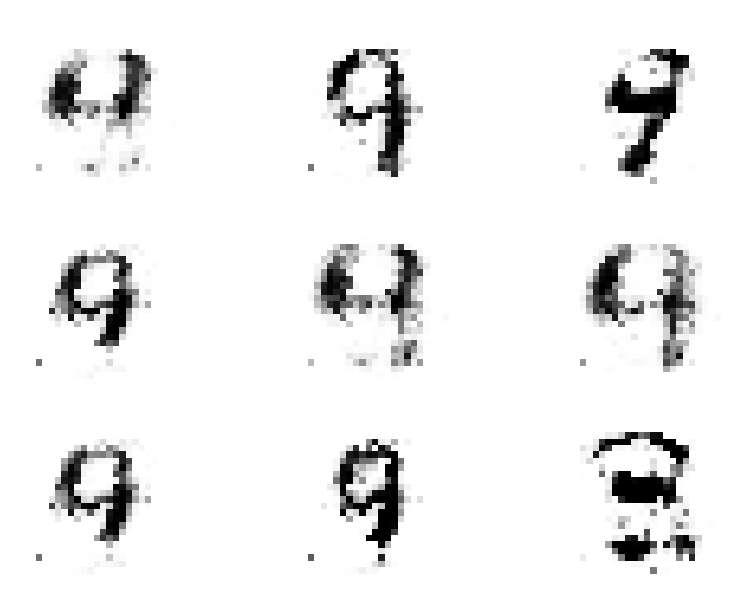

Epoch:310, Step:0, D-Loss:0.117, D-Acc:98.333, G-Loss:3.525, Wasserstein Dist:0.027
Epoch:310, Step:10, D-Loss:0.251, D-Acc:96.667, G-Loss:3.324, Wasserstein Dist:0.026
Epoch:310, Step:20, D-Loss:0.162, D-Acc:96.667, G-Loss:3.580, Wasserstein Dist:0.028
Epoch:310, Step:30, D-Loss:0.231, D-Acc:96.667, G-Loss:3.698, Wasserstein Dist:0.027
Epoch:310, Step:40, D-Loss:0.104, D-Acc:98.333, G-Loss:3.289, Wasserstein Dist:0.029
Epoch:311, Step:0, D-Loss:0.187, D-Acc:98.333, G-Loss:3.447, Wasserstein Dist:0.030
Epoch:311, Step:10, D-Loss:0.105, D-Acc:96.667, G-Loss:3.739, Wasserstein Dist:0.030
Epoch:311, Step:20, D-Loss:0.064, D-Acc:100.000, G-Loss:3.481, Wasserstein Dist:0.030
Epoch:311, Step:30, D-Loss:0.058, D-Acc:100.000, G-Loss:3.497, Wasserstein Dist:0.029
Epoch:311, Step:40, D-Loss:0.063, D-Acc:100.000, G-Loss:3.347, Wasserstein Dist:0.028
Epoch:312, Step:0, D-Loss:0.084, D-Acc:98.333, G-Loss:3.463, Wasserstein Dist:0.031
Epoch:312, Step:10, D-Loss:0.164, D-Acc:96.667, G-Loss:3.326, Was

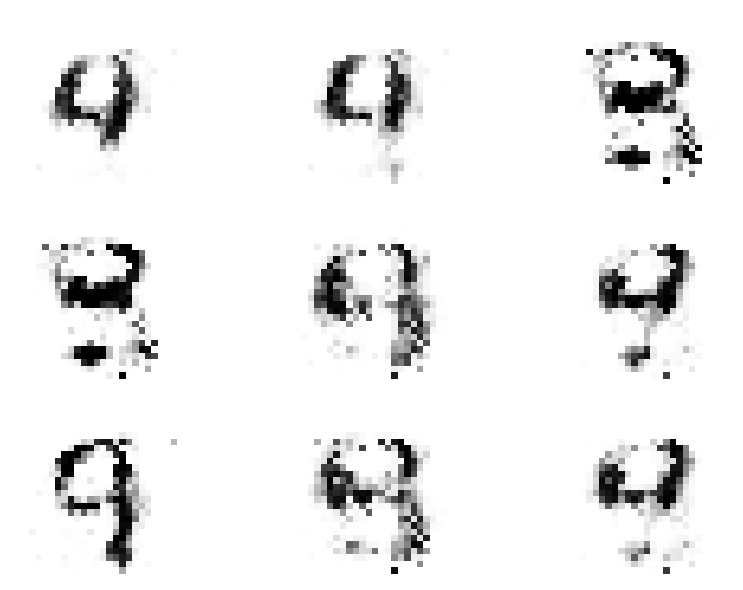

Epoch:315, Step:0, D-Loss:0.053, D-Acc:100.000, G-Loss:3.432, Wasserstein Dist:0.028
Epoch:315, Step:10, D-Loss:0.190, D-Acc:96.667, G-Loss:3.393, Wasserstein Dist:0.029
Epoch:315, Step:20, D-Loss:0.081, D-Acc:98.333, G-Loss:3.778, Wasserstein Dist:0.028
Epoch:315, Step:30, D-Loss:0.054, D-Acc:100.000, G-Loss:3.498, Wasserstein Dist:0.025
Epoch:315, Step:40, D-Loss:0.055, D-Acc:100.000, G-Loss:3.448, Wasserstein Dist:0.029
Epoch:316, Step:0, D-Loss:0.036, D-Acc:100.000, G-Loss:3.563, Wasserstein Dist:0.027
Epoch:316, Step:10, D-Loss:0.260, D-Acc:95.000, G-Loss:3.414, Wasserstein Dist:0.030
Epoch:316, Step:20, D-Loss:0.071, D-Acc:100.000, G-Loss:3.566, Wasserstein Dist:0.027
Epoch:316, Step:30, D-Loss:0.209, D-Acc:96.667, G-Loss:3.484, Wasserstein Dist:0.026
Epoch:316, Step:40, D-Loss:0.095, D-Acc:98.333, G-Loss:3.830, Wasserstein Dist:0.027
Epoch:317, Step:0, D-Loss:0.068, D-Acc:98.333, G-Loss:3.483, Wasserstein Dist:0.027
Epoch:317, Step:10, D-Loss:0.096, D-Acc:96.667, G-Loss:3.792, W

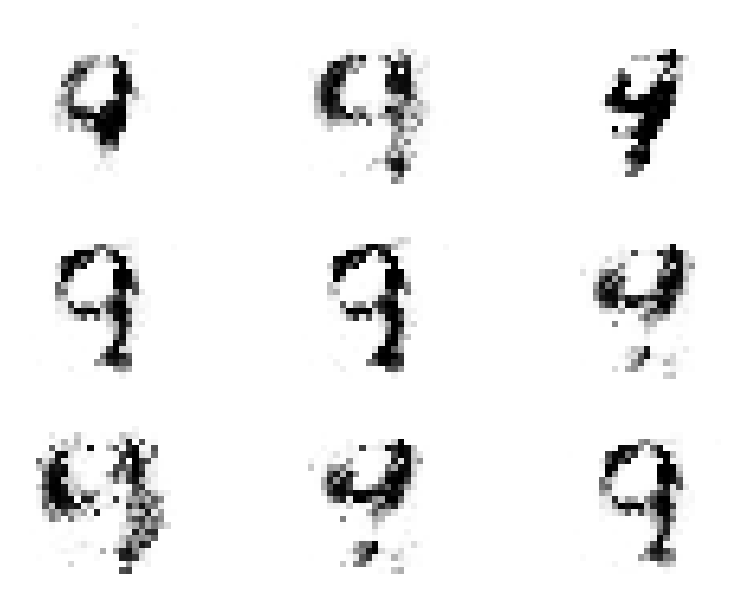

Epoch:320, Step:0, D-Loss:0.065, D-Acc:98.333, G-Loss:3.941, Wasserstein Dist:0.025
Epoch:320, Step:10, D-Loss:0.146, D-Acc:95.000, G-Loss:3.797, Wasserstein Dist:0.024
Epoch:320, Step:20, D-Loss:0.036, D-Acc:100.000, G-Loss:3.593, Wasserstein Dist:0.025
Epoch:320, Step:30, D-Loss:0.239, D-Acc:98.333, G-Loss:3.468, Wasserstein Dist:0.025
Epoch:320, Step:40, D-Loss:0.033, D-Acc:100.000, G-Loss:3.918, Wasserstein Dist:0.024
Epoch:321, Step:0, D-Loss:0.093, D-Acc:98.333, G-Loss:3.827, Wasserstein Dist:0.024
Epoch:321, Step:10, D-Loss:0.048, D-Acc:100.000, G-Loss:3.713, Wasserstein Dist:0.024
Epoch:321, Step:20, D-Loss:0.147, D-Acc:98.333, G-Loss:3.653, Wasserstein Dist:0.026
Epoch:321, Step:30, D-Loss:0.089, D-Acc:100.000, G-Loss:3.846, Wasserstein Dist:0.027
Epoch:321, Step:40, D-Loss:0.059, D-Acc:100.000, G-Loss:3.649, Wasserstein Dist:0.023
Epoch:322, Step:0, D-Loss:0.148, D-Acc:96.667, G-Loss:3.919, Wasserstein Dist:0.025
Epoch:322, Step:10, D-Loss:0.132, D-Acc:98.333, G-Loss:3.414, W

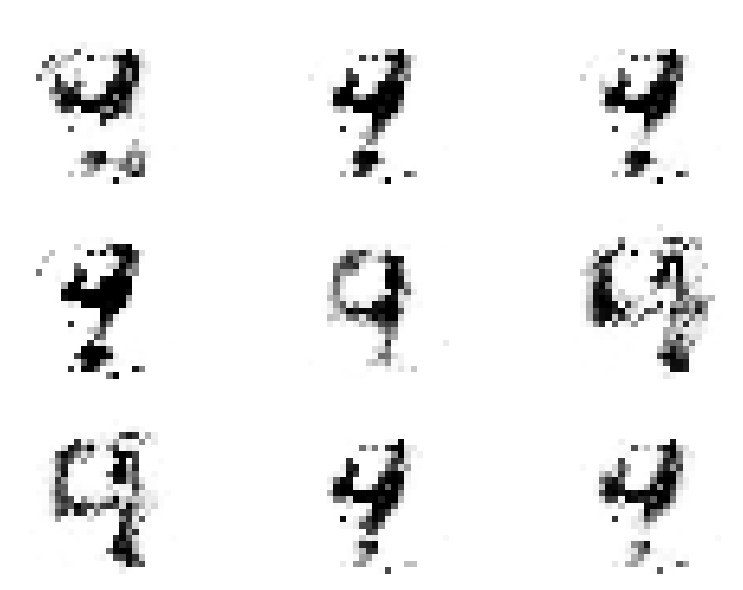

Epoch:325, Step:0, D-Loss:0.041, D-Acc:100.000, G-Loss:3.950, Wasserstein Dist:0.028
Epoch:325, Step:10, D-Loss:0.037, D-Acc:100.000, G-Loss:3.770, Wasserstein Dist:0.028
Epoch:325, Step:20, D-Loss:0.045, D-Acc:100.000, G-Loss:3.984, Wasserstein Dist:0.026
Epoch:325, Step:30, D-Loss:0.128, D-Acc:96.667, G-Loss:3.688, Wasserstein Dist:0.026
Epoch:325, Step:40, D-Loss:0.040, D-Acc:100.000, G-Loss:3.674, Wasserstein Dist:0.029
Epoch:326, Step:0, D-Loss:0.071, D-Acc:98.333, G-Loss:4.011, Wasserstein Dist:0.027
Epoch:326, Step:10, D-Loss:0.132, D-Acc:98.333, G-Loss:3.998, Wasserstein Dist:0.027
Epoch:326, Step:20, D-Loss:0.122, D-Acc:98.333, G-Loss:3.903, Wasserstein Dist:0.029
Epoch:326, Step:30, D-Loss:0.031, D-Acc:100.000, G-Loss:3.835, Wasserstein Dist:0.027
Epoch:326, Step:40, D-Loss:0.040, D-Acc:100.000, G-Loss:3.948, Wasserstein Dist:0.028
Epoch:327, Step:0, D-Loss:0.090, D-Acc:98.333, G-Loss:3.520, Wasserstein Dist:0.029
Epoch:327, Step:10, D-Loss:0.176, D-Acc:95.000, G-Loss:3.602, 

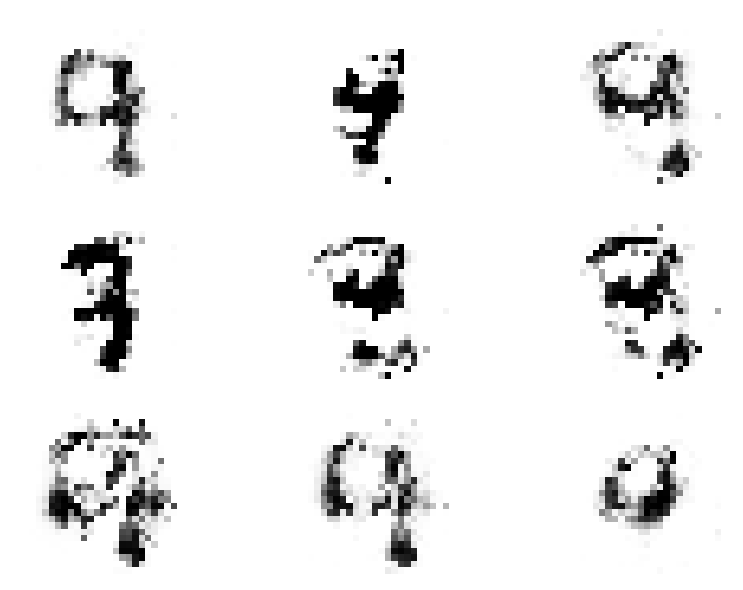

Epoch:330, Step:0, D-Loss:0.028, D-Acc:100.000, G-Loss:3.946, Wasserstein Dist:0.029
Epoch:330, Step:10, D-Loss:0.152, D-Acc:98.333, G-Loss:3.863, Wasserstein Dist:0.030
Epoch:330, Step:20, D-Loss:0.053, D-Acc:100.000, G-Loss:4.054, Wasserstein Dist:0.030
Epoch:330, Step:30, D-Loss:0.148, D-Acc:96.667, G-Loss:4.056, Wasserstein Dist:0.031
Epoch:330, Step:40, D-Loss:0.251, D-Acc:96.667, G-Loss:3.730, Wasserstein Dist:0.030
Epoch:331, Step:0, D-Loss:0.054, D-Acc:100.000, G-Loss:3.494, Wasserstein Dist:0.032
Epoch:331, Step:10, D-Loss:0.043, D-Acc:100.000, G-Loss:3.944, Wasserstein Dist:0.033
Epoch:331, Step:20, D-Loss:0.103, D-Acc:98.333, G-Loss:3.433, Wasserstein Dist:0.031
Epoch:331, Step:30, D-Loss:0.053, D-Acc:100.000, G-Loss:3.725, Wasserstein Dist:0.031
Epoch:331, Step:40, D-Loss:0.052, D-Acc:100.000, G-Loss:3.805, Wasserstein Dist:0.033
Epoch:332, Step:0, D-Loss:0.137, D-Acc:98.333, G-Loss:3.519, Wasserstein Dist:0.032
Epoch:332, Step:10, D-Loss:0.113, D-Acc:98.333, G-Loss:3.734, 

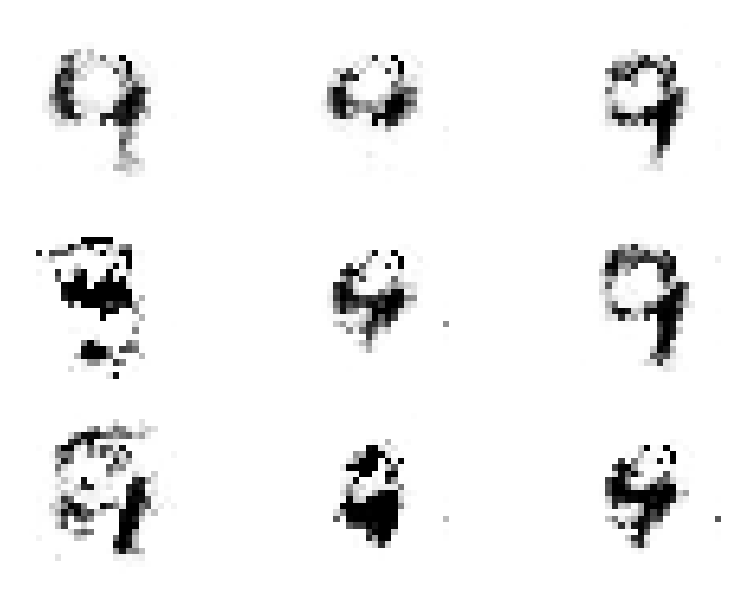

Epoch:335, Step:0, D-Loss:0.057, D-Acc:100.000, G-Loss:3.649, Wasserstein Dist:0.031
Epoch:335, Step:10, D-Loss:0.079, D-Acc:100.000, G-Loss:3.456, Wasserstein Dist:0.033
Epoch:335, Step:20, D-Loss:0.083, D-Acc:98.333, G-Loss:3.436, Wasserstein Dist:0.033
Epoch:335, Step:30, D-Loss:0.043, D-Acc:100.000, G-Loss:3.881, Wasserstein Dist:0.032
Epoch:335, Step:40, D-Loss:0.078, D-Acc:98.333, G-Loss:3.509, Wasserstein Dist:0.032
Epoch:336, Step:0, D-Loss:0.051, D-Acc:100.000, G-Loss:3.681, Wasserstein Dist:0.033
Epoch:336, Step:10, D-Loss:0.073, D-Acc:100.000, G-Loss:3.821, Wasserstein Dist:0.030
Epoch:336, Step:20, D-Loss:0.061, D-Acc:100.000, G-Loss:3.304, Wasserstein Dist:0.032
Epoch:336, Step:30, D-Loss:0.095, D-Acc:98.333, G-Loss:3.537, Wasserstein Dist:0.031
Epoch:336, Step:40, D-Loss:0.067, D-Acc:98.333, G-Loss:3.640, Wasserstein Dist:0.033
Epoch:337, Step:0, D-Loss:0.049, D-Acc:100.000, G-Loss:3.714, Wasserstein Dist:0.030
Epoch:337, Step:10, D-Loss:0.071, D-Acc:100.000, G-Loss:3.465

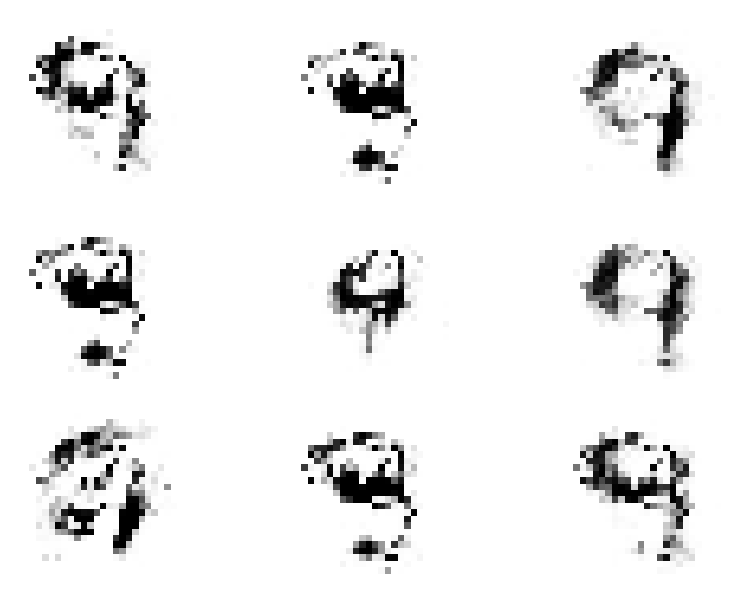

Epoch:340, Step:0, D-Loss:0.069, D-Acc:100.000, G-Loss:3.646, Wasserstein Dist:0.031
Epoch:340, Step:10, D-Loss:0.090, D-Acc:98.333, G-Loss:3.472, Wasserstein Dist:0.032
Epoch:340, Step:20, D-Loss:0.082, D-Acc:100.000, G-Loss:3.743, Wasserstein Dist:0.029
Epoch:340, Step:30, D-Loss:0.072, D-Acc:98.333, G-Loss:3.940, Wasserstein Dist:0.029
Epoch:340, Step:40, D-Loss:0.042, D-Acc:100.000, G-Loss:3.667, Wasserstein Dist:0.032
Epoch:341, Step:0, D-Loss:0.176, D-Acc:96.667, G-Loss:3.819, Wasserstein Dist:0.029
Epoch:341, Step:10, D-Loss:0.105, D-Acc:98.333, G-Loss:3.651, Wasserstein Dist:0.029
Epoch:341, Step:20, D-Loss:0.102, D-Acc:98.333, G-Loss:4.016, Wasserstein Dist:0.029
Epoch:341, Step:30, D-Loss:0.101, D-Acc:96.667, G-Loss:3.630, Wasserstein Dist:0.029
Epoch:341, Step:40, D-Loss:0.030, D-Acc:100.000, G-Loss:3.789, Wasserstein Dist:0.029
Epoch:342, Step:0, D-Loss:0.044, D-Acc:100.000, G-Loss:3.755, Wasserstein Dist:0.027
Epoch:342, Step:10, D-Loss:0.059, D-Acc:98.333, G-Loss:3.917, W

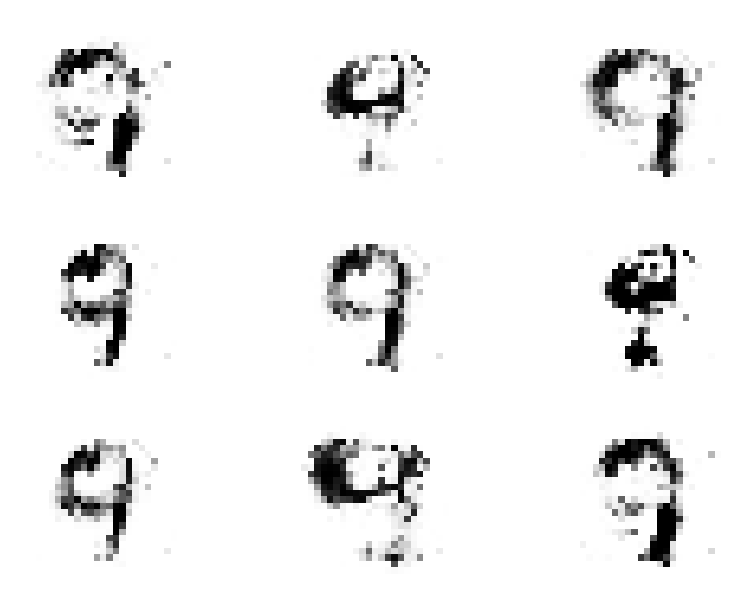

Epoch:345, Step:0, D-Loss:0.035, D-Acc:100.000, G-Loss:3.552, Wasserstein Dist:0.026
Epoch:345, Step:10, D-Loss:0.075, D-Acc:100.000, G-Loss:3.815, Wasserstein Dist:0.029
Epoch:345, Step:20, D-Loss:0.149, D-Acc:96.667, G-Loss:3.806, Wasserstein Dist:0.025
Epoch:345, Step:30, D-Loss:0.204, D-Acc:96.667, G-Loss:3.549, Wasserstein Dist:0.026
Epoch:345, Step:40, D-Loss:0.044, D-Acc:100.000, G-Loss:3.710, Wasserstein Dist:0.025
Epoch:346, Step:0, D-Loss:0.059, D-Acc:100.000, G-Loss:3.741, Wasserstein Dist:0.025
Epoch:346, Step:10, D-Loss:0.073, D-Acc:100.000, G-Loss:3.817, Wasserstein Dist:0.027
Epoch:346, Step:20, D-Loss:0.061, D-Acc:98.333, G-Loss:3.637, Wasserstein Dist:0.026
Epoch:346, Step:30, D-Loss:0.049, D-Acc:100.000, G-Loss:3.758, Wasserstein Dist:0.024
Epoch:346, Step:40, D-Loss:0.064, D-Acc:100.000, G-Loss:4.002, Wasserstein Dist:0.027
Epoch:347, Step:0, D-Loss:0.096, D-Acc:98.333, G-Loss:3.910, Wasserstein Dist:0.027
Epoch:347, Step:10, D-Loss:0.082, D-Acc:100.000, G-Loss:3.839

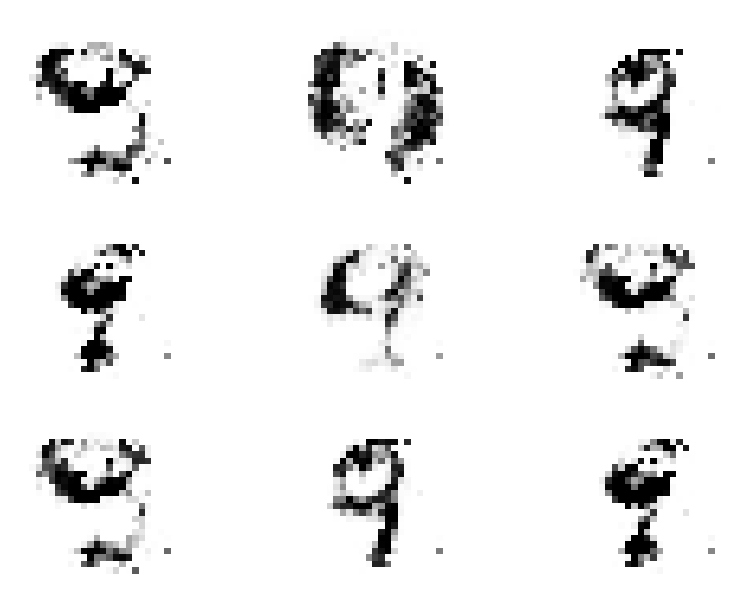

Epoch:350, Step:0, D-Loss:0.054, D-Acc:100.000, G-Loss:3.569, Wasserstein Dist:0.029
Epoch:350, Step:10, D-Loss:0.034, D-Acc:100.000, G-Loss:3.913, Wasserstein Dist:0.028
Epoch:350, Step:20, D-Loss:0.059, D-Acc:100.000, G-Loss:3.867, Wasserstein Dist:0.026
Epoch:350, Step:30, D-Loss:0.091, D-Acc:98.333, G-Loss:3.763, Wasserstein Dist:0.030
Epoch:350, Step:40, D-Loss:0.090, D-Acc:98.333, G-Loss:3.583, Wasserstein Dist:0.029
Epoch:351, Step:0, D-Loss:0.041, D-Acc:100.000, G-Loss:3.626, Wasserstein Dist:0.029
Epoch:351, Step:10, D-Loss:0.072, D-Acc:98.333, G-Loss:3.839, Wasserstein Dist:0.028
Epoch:351, Step:20, D-Loss:0.061, D-Acc:98.333, G-Loss:3.471, Wasserstein Dist:0.031
Epoch:351, Step:30, D-Loss:0.125, D-Acc:98.333, G-Loss:3.936, Wasserstein Dist:0.032
Epoch:351, Step:40, D-Loss:0.076, D-Acc:100.000, G-Loss:3.828, Wasserstein Dist:0.030
Epoch:352, Step:0, D-Loss:0.075, D-Acc:100.000, G-Loss:3.760, Wasserstein Dist:0.033
Epoch:352, Step:10, D-Loss:0.085, D-Acc:98.333, G-Loss:3.792, 

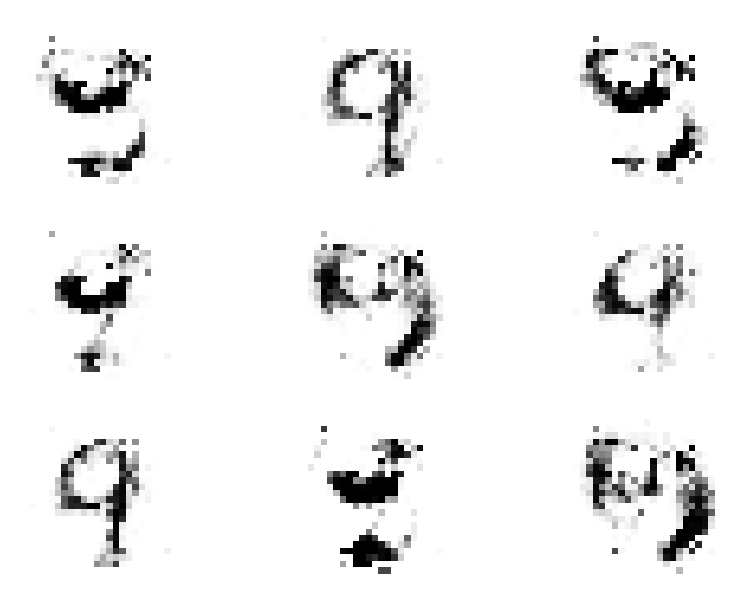

Epoch:355, Step:0, D-Loss:0.098, D-Acc:100.000, G-Loss:3.648, Wasserstein Dist:0.035
Epoch:355, Step:10, D-Loss:0.051, D-Acc:100.000, G-Loss:3.880, Wasserstein Dist:0.035
Epoch:355, Step:20, D-Loss:0.071, D-Acc:100.000, G-Loss:3.905, Wasserstein Dist:0.035
Epoch:355, Step:30, D-Loss:0.077, D-Acc:98.333, G-Loss:3.910, Wasserstein Dist:0.037
Epoch:355, Step:40, D-Loss:0.056, D-Acc:100.000, G-Loss:3.735, Wasserstein Dist:0.035
Epoch:356, Step:0, D-Loss:0.126, D-Acc:96.667, G-Loss:3.576, Wasserstein Dist:0.037
Epoch:356, Step:10, D-Loss:0.056, D-Acc:98.333, G-Loss:3.906, Wasserstein Dist:0.037
Epoch:356, Step:20, D-Loss:0.031, D-Acc:100.000, G-Loss:4.021, Wasserstein Dist:0.038
Epoch:356, Step:30, D-Loss:0.091, D-Acc:98.333, G-Loss:3.728, Wasserstein Dist:0.038
Epoch:356, Step:40, D-Loss:0.040, D-Acc:100.000, G-Loss:3.864, Wasserstein Dist:0.041
Epoch:357, Step:0, D-Loss:0.033, D-Acc:100.000, G-Loss:3.577, Wasserstein Dist:0.037
Epoch:357, Step:10, D-Loss:0.064, D-Acc:100.000, G-Loss:3.713

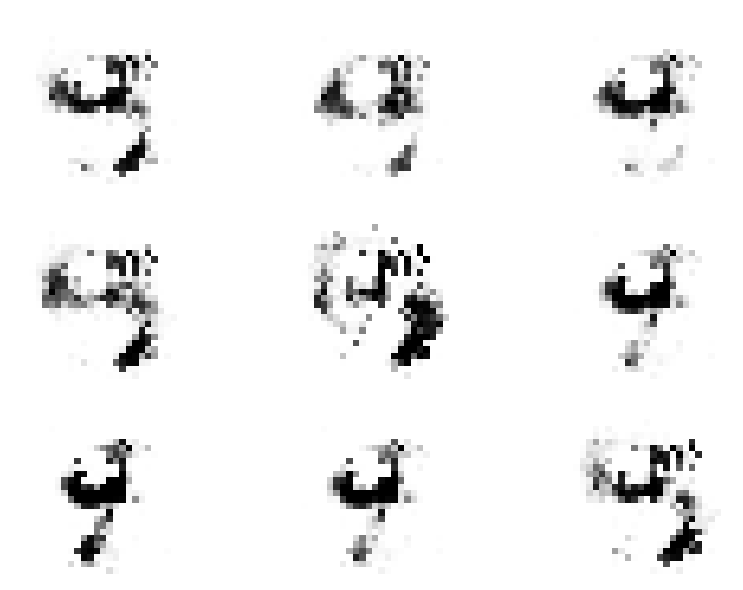

Epoch:360, Step:0, D-Loss:0.122, D-Acc:98.333, G-Loss:3.631, Wasserstein Dist:0.041
Epoch:360, Step:10, D-Loss:0.040, D-Acc:100.000, G-Loss:3.880, Wasserstein Dist:0.042
Epoch:360, Step:20, D-Loss:0.043, D-Acc:100.000, G-Loss:3.890, Wasserstein Dist:0.039
Epoch:360, Step:30, D-Loss:0.097, D-Acc:100.000, G-Loss:3.866, Wasserstein Dist:0.041
Epoch:360, Step:40, D-Loss:0.057, D-Acc:100.000, G-Loss:3.794, Wasserstein Dist:0.041
Epoch:361, Step:0, D-Loss:0.046, D-Acc:100.000, G-Loss:3.770, Wasserstein Dist:0.042
Epoch:361, Step:10, D-Loss:0.088, D-Acc:100.000, G-Loss:3.829, Wasserstein Dist:0.039
Epoch:361, Step:20, D-Loss:0.060, D-Acc:100.000, G-Loss:3.790, Wasserstein Dist:0.039
Epoch:361, Step:30, D-Loss:0.095, D-Acc:98.333, G-Loss:3.678, Wasserstein Dist:0.040
Epoch:361, Step:40, D-Loss:0.080, D-Acc:98.333, G-Loss:3.798, Wasserstein Dist:0.041
Epoch:362, Step:0, D-Loss:0.148, D-Acc:96.667, G-Loss:3.560, Wasserstein Dist:0.042
Epoch:362, Step:10, D-Loss:0.051, D-Acc:100.000, G-Loss:3.908

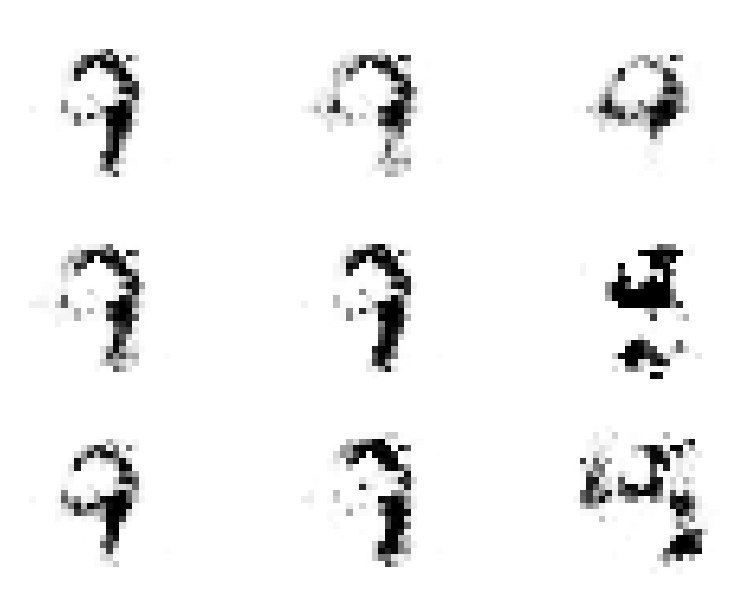

Epoch:365, Step:0, D-Loss:0.067, D-Acc:100.000, G-Loss:3.860, Wasserstein Dist:0.044
Epoch:365, Step:10, D-Loss:0.064, D-Acc:98.333, G-Loss:3.839, Wasserstein Dist:0.042
Epoch:365, Step:20, D-Loss:0.036, D-Acc:100.000, G-Loss:3.997, Wasserstein Dist:0.042
Epoch:365, Step:30, D-Loss:0.141, D-Acc:96.667, G-Loss:3.500, Wasserstein Dist:0.042
Epoch:365, Step:40, D-Loss:0.061, D-Acc:100.000, G-Loss:3.671, Wasserstein Dist:0.044
Epoch:366, Step:0, D-Loss:0.068, D-Acc:100.000, G-Loss:3.681, Wasserstein Dist:0.042
Epoch:366, Step:10, D-Loss:0.124, D-Acc:98.333, G-Loss:3.751, Wasserstein Dist:0.044
Epoch:366, Step:20, D-Loss:0.038, D-Acc:100.000, G-Loss:3.754, Wasserstein Dist:0.041
Epoch:366, Step:30, D-Loss:0.121, D-Acc:98.333, G-Loss:3.522, Wasserstein Dist:0.041
Epoch:366, Step:40, D-Loss:0.047, D-Acc:100.000, G-Loss:3.655, Wasserstein Dist:0.042
Epoch:367, Step:0, D-Loss:0.048, D-Acc:100.000, G-Loss:3.984, Wasserstein Dist:0.042
Epoch:367, Step:10, D-Loss:0.033, D-Acc:100.000, G-Loss:3.980

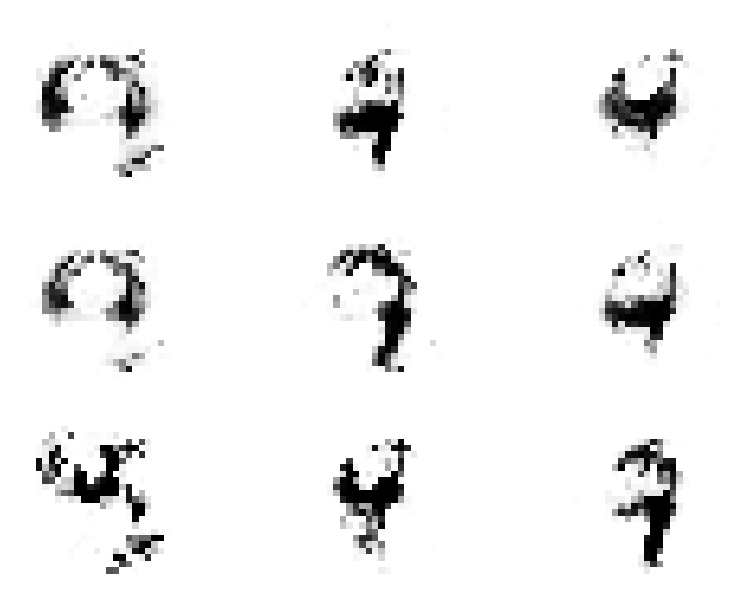

Epoch:370, Step:0, D-Loss:0.050, D-Acc:100.000, G-Loss:3.715, Wasserstein Dist:0.041
Epoch:370, Step:10, D-Loss:0.054, D-Acc:100.000, G-Loss:3.815, Wasserstein Dist:0.041
Epoch:370, Step:20, D-Loss:0.092, D-Acc:100.000, G-Loss:3.712, Wasserstein Dist:0.042
Epoch:370, Step:30, D-Loss:0.031, D-Acc:100.000, G-Loss:4.084, Wasserstein Dist:0.042
Epoch:370, Step:40, D-Loss:0.039, D-Acc:100.000, G-Loss:3.841, Wasserstein Dist:0.042
Epoch:371, Step:0, D-Loss:0.057, D-Acc:100.000, G-Loss:3.866, Wasserstein Dist:0.043
Epoch:371, Step:10, D-Loss:0.029, D-Acc:100.000, G-Loss:4.033, Wasserstein Dist:0.043
Epoch:371, Step:20, D-Loss:0.032, D-Acc:100.000, G-Loss:3.969, Wasserstein Dist:0.040
Epoch:371, Step:30, D-Loss:0.191, D-Acc:98.333, G-Loss:3.878, Wasserstein Dist:0.041
Epoch:371, Step:40, D-Loss:0.055, D-Acc:100.000, G-Loss:3.856, Wasserstein Dist:0.042
Epoch:372, Step:0, D-Loss:0.044, D-Acc:100.000, G-Loss:3.921, Wasserstein Dist:0.042
Epoch:372, Step:10, D-Loss:0.041, D-Acc:100.000, G-Loss:3.

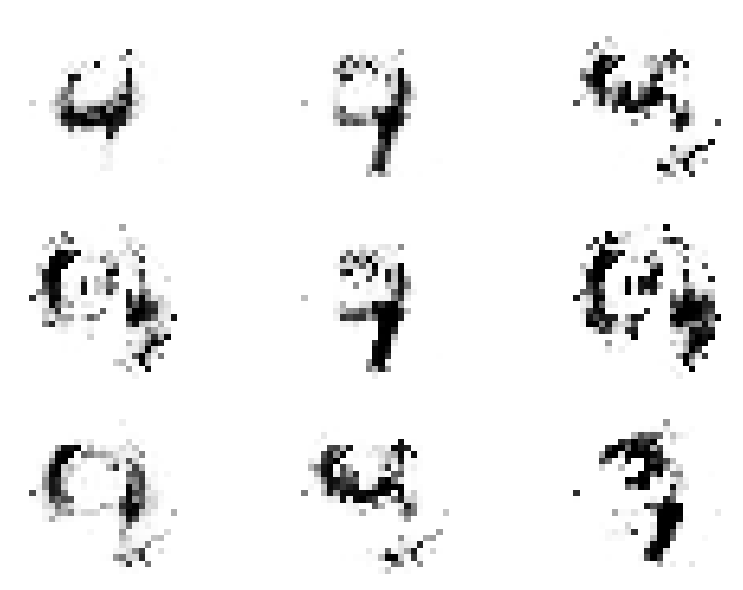

Epoch:375, Step:0, D-Loss:0.046, D-Acc:100.000, G-Loss:4.130, Wasserstein Dist:0.042
Epoch:375, Step:10, D-Loss:0.051, D-Acc:100.000, G-Loss:3.727, Wasserstein Dist:0.047
Epoch:375, Step:20, D-Loss:0.028, D-Acc:100.000, G-Loss:3.761, Wasserstein Dist:0.045
Epoch:375, Step:30, D-Loss:0.046, D-Acc:100.000, G-Loss:4.001, Wasserstein Dist:0.044
Epoch:375, Step:40, D-Loss:0.064, D-Acc:100.000, G-Loss:3.841, Wasserstein Dist:0.046
Epoch:376, Step:0, D-Loss:0.049, D-Acc:100.000, G-Loss:3.962, Wasserstein Dist:0.043
Epoch:376, Step:10, D-Loss:0.028, D-Acc:100.000, G-Loss:3.855, Wasserstein Dist:0.045
Epoch:376, Step:20, D-Loss:0.030, D-Acc:100.000, G-Loss:3.928, Wasserstein Dist:0.044
Epoch:376, Step:30, D-Loss:0.071, D-Acc:98.333, G-Loss:4.033, Wasserstein Dist:0.043
Epoch:376, Step:40, D-Loss:0.067, D-Acc:100.000, G-Loss:3.926, Wasserstein Dist:0.045
Epoch:377, Step:0, D-Loss:0.068, D-Acc:100.000, G-Loss:3.983, Wasserstein Dist:0.042
Epoch:377, Step:10, D-Loss:0.052, D-Acc:100.000, G-Loss:4.

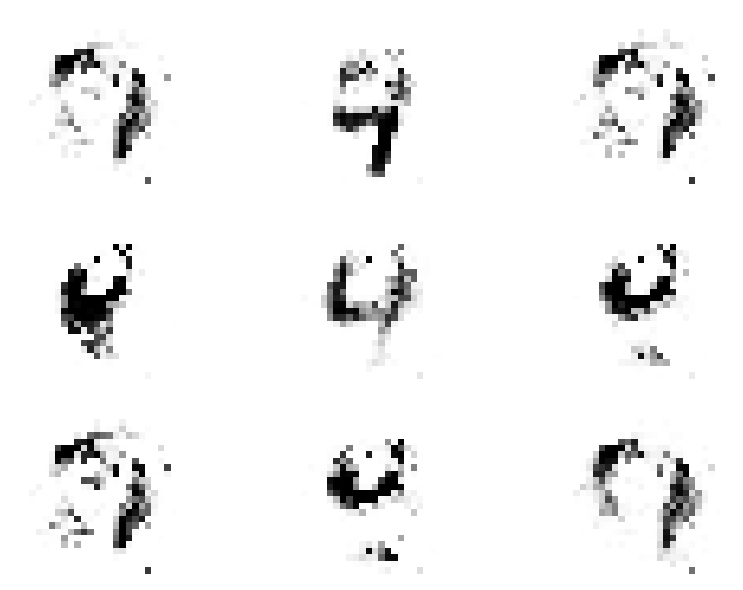

Epoch:380, Step:0, D-Loss:0.048, D-Acc:100.000, G-Loss:3.611, Wasserstein Dist:0.041
Epoch:380, Step:10, D-Loss:0.077, D-Acc:100.000, G-Loss:3.691, Wasserstein Dist:0.044
Epoch:380, Step:20, D-Loss:0.139, D-Acc:96.667, G-Loss:3.980, Wasserstein Dist:0.043
Epoch:380, Step:30, D-Loss:0.035, D-Acc:100.000, G-Loss:3.807, Wasserstein Dist:0.042
Epoch:380, Step:40, D-Loss:0.071, D-Acc:98.333, G-Loss:3.743, Wasserstein Dist:0.042
Epoch:381, Step:0, D-Loss:0.060, D-Acc:100.000, G-Loss:3.915, Wasserstein Dist:0.042
Epoch:381, Step:10, D-Loss:0.094, D-Acc:100.000, G-Loss:3.855, Wasserstein Dist:0.043
Epoch:381, Step:20, D-Loss:0.066, D-Acc:100.000, G-Loss:3.789, Wasserstein Dist:0.042
Epoch:381, Step:30, D-Loss:0.075, D-Acc:98.333, G-Loss:3.703, Wasserstein Dist:0.039
Epoch:381, Step:40, D-Loss:0.067, D-Acc:100.000, G-Loss:4.020, Wasserstein Dist:0.042
Epoch:382, Step:0, D-Loss:0.056, D-Acc:100.000, G-Loss:4.061, Wasserstein Dist:0.041
Epoch:382, Step:10, D-Loss:0.040, D-Acc:100.000, G-Loss:4.12

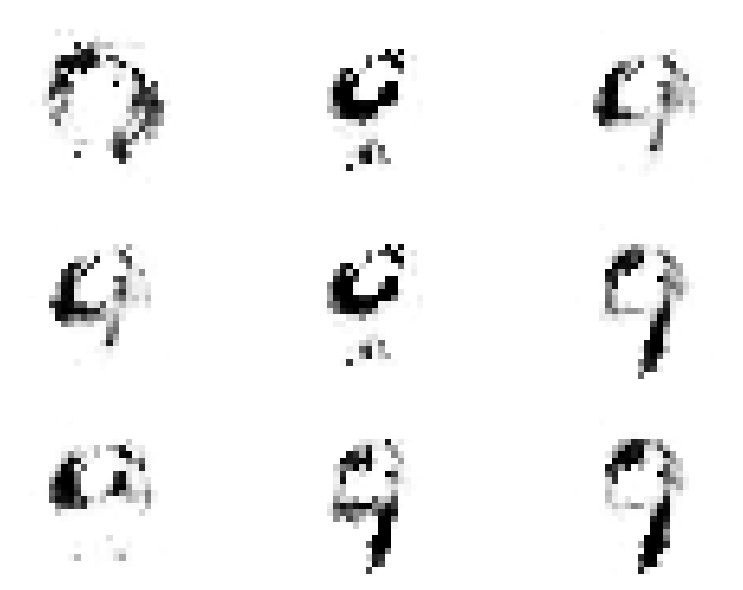

Epoch:385, Step:0, D-Loss:0.036, D-Acc:100.000, G-Loss:4.062, Wasserstein Dist:0.040
Epoch:385, Step:10, D-Loss:0.075, D-Acc:98.333, G-Loss:4.023, Wasserstein Dist:0.041
Epoch:385, Step:20, D-Loss:0.049, D-Acc:100.000, G-Loss:3.886, Wasserstein Dist:0.043
Epoch:385, Step:30, D-Loss:0.178, D-Acc:95.000, G-Loss:4.286, Wasserstein Dist:0.043
Epoch:385, Step:40, D-Loss:0.102, D-Acc:98.333, G-Loss:3.950, Wasserstein Dist:0.043
Epoch:386, Step:0, D-Loss:0.090, D-Acc:98.333, G-Loss:3.939, Wasserstein Dist:0.042
Epoch:386, Step:10, D-Loss:0.046, D-Acc:100.000, G-Loss:4.049, Wasserstein Dist:0.044
Epoch:386, Step:20, D-Loss:0.089, D-Acc:98.333, G-Loss:4.024, Wasserstein Dist:0.044
Epoch:386, Step:30, D-Loss:0.045, D-Acc:100.000, G-Loss:4.433, Wasserstein Dist:0.046
Epoch:386, Step:40, D-Loss:0.156, D-Acc:96.667, G-Loss:4.099, Wasserstein Dist:0.046
Epoch:387, Step:0, D-Loss:0.078, D-Acc:98.333, G-Loss:3.931, Wasserstein Dist:0.044
Epoch:387, Step:10, D-Loss:0.032, D-Acc:100.000, G-Loss:4.206, W

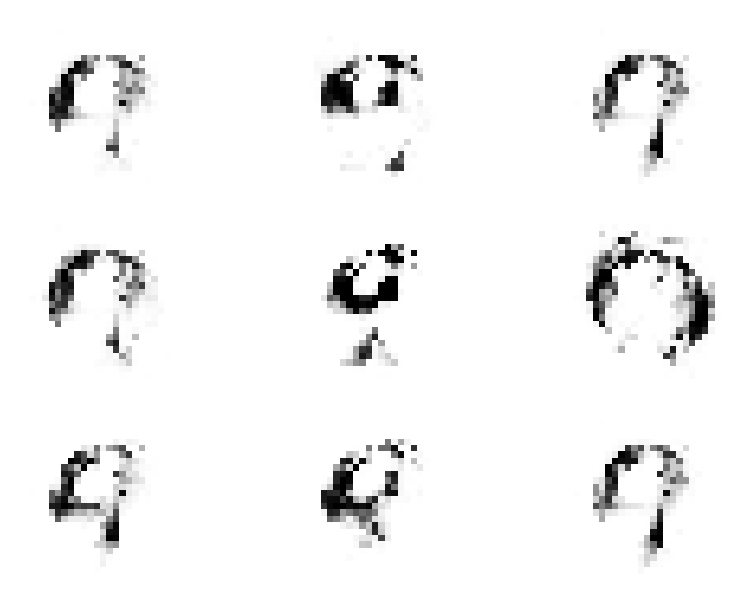

Epoch:390, Step:0, D-Loss:0.046, D-Acc:100.000, G-Loss:4.675, Wasserstein Dist:0.048
Epoch:390, Step:10, D-Loss:0.084, D-Acc:98.333, G-Loss:4.417, Wasserstein Dist:0.045
Epoch:390, Step:20, D-Loss:0.035, D-Acc:100.000, G-Loss:4.277, Wasserstein Dist:0.045
Epoch:390, Step:30, D-Loss:0.055, D-Acc:100.000, G-Loss:4.326, Wasserstein Dist:0.047
Epoch:390, Step:40, D-Loss:0.029, D-Acc:100.000, G-Loss:4.189, Wasserstein Dist:0.045
Epoch:391, Step:0, D-Loss:0.107, D-Acc:98.333, G-Loss:4.329, Wasserstein Dist:0.047
Epoch:391, Step:10, D-Loss:0.075, D-Acc:98.333, G-Loss:4.295, Wasserstein Dist:0.047
Epoch:391, Step:20, D-Loss:0.036, D-Acc:100.000, G-Loss:4.497, Wasserstein Dist:0.049
Epoch:391, Step:30, D-Loss:0.059, D-Acc:100.000, G-Loss:4.213, Wasserstein Dist:0.045
Epoch:391, Step:40, D-Loss:0.030, D-Acc:100.000, G-Loss:4.525, Wasserstein Dist:0.046
Epoch:392, Step:0, D-Loss:0.026, D-Acc:100.000, G-Loss:4.640, Wasserstein Dist:0.047
Epoch:392, Step:10, D-Loss:0.040, D-Acc:100.000, G-Loss:4.42

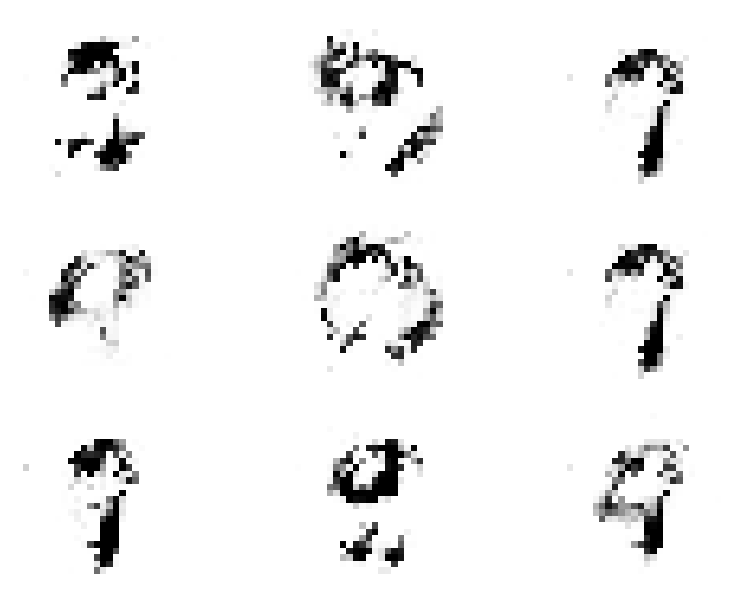

Epoch:395, Step:0, D-Loss:0.072, D-Acc:98.333, G-Loss:4.480, Wasserstein Dist:0.045
Epoch:395, Step:10, D-Loss:0.077, D-Acc:98.333, G-Loss:4.474, Wasserstein Dist:0.044
Epoch:395, Step:20, D-Loss:0.240, D-Acc:95.000, G-Loss:4.252, Wasserstein Dist:0.048
Epoch:395, Step:30, D-Loss:0.024, D-Acc:100.000, G-Loss:4.156, Wasserstein Dist:0.044
Epoch:395, Step:40, D-Loss:0.044, D-Acc:100.000, G-Loss:4.043, Wasserstein Dist:0.046
Epoch:396, Step:0, D-Loss:0.020, D-Acc:100.000, G-Loss:4.273, Wasserstein Dist:0.043
Epoch:396, Step:10, D-Loss:0.096, D-Acc:98.333, G-Loss:4.381, Wasserstein Dist:0.045
Epoch:396, Step:20, D-Loss:0.035, D-Acc:100.000, G-Loss:4.347, Wasserstein Dist:0.044
Epoch:396, Step:30, D-Loss:0.029, D-Acc:100.000, G-Loss:4.250, Wasserstein Dist:0.043
Epoch:396, Step:40, D-Loss:0.027, D-Acc:100.000, G-Loss:4.227, Wasserstein Dist:0.044
Epoch:397, Step:0, D-Loss:0.085, D-Acc:98.333, G-Loss:4.095, Wasserstein Dist:0.046
Epoch:397, Step:10, D-Loss:0.060, D-Acc:100.000, G-Loss:4.133,

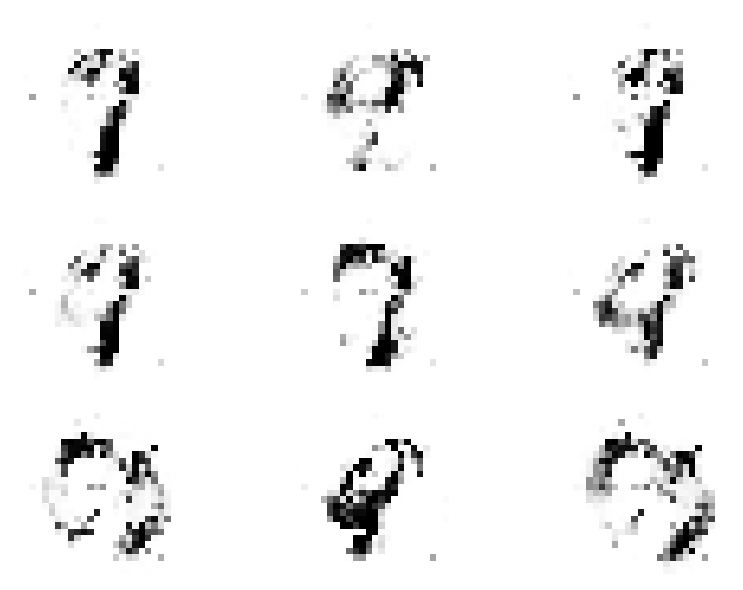

Epoch:400, Step:0, D-Loss:0.033, D-Acc:100.000, G-Loss:4.305, Wasserstein Dist:0.043
Epoch:400, Step:10, D-Loss:0.035, D-Acc:100.000, G-Loss:4.265, Wasserstein Dist:0.044
Epoch:400, Step:20, D-Loss:0.024, D-Acc:100.000, G-Loss:4.316, Wasserstein Dist:0.042
Epoch:400, Step:30, D-Loss:0.040, D-Acc:100.000, G-Loss:4.050, Wasserstein Dist:0.046
Epoch:400, Step:40, D-Loss:0.186, D-Acc:96.667, G-Loss:4.118, Wasserstein Dist:0.043
Epoch:401, Step:0, D-Loss:0.033, D-Acc:100.000, G-Loss:4.573, Wasserstein Dist:0.045
Epoch:401, Step:10, D-Loss:0.033, D-Acc:100.000, G-Loss:4.298, Wasserstein Dist:0.044
Epoch:401, Step:20, D-Loss:0.022, D-Acc:100.000, G-Loss:4.343, Wasserstein Dist:0.042
Epoch:401, Step:30, D-Loss:0.120, D-Acc:98.333, G-Loss:4.307, Wasserstein Dist:0.041
Epoch:401, Step:40, D-Loss:0.031, D-Acc:100.000, G-Loss:4.207, Wasserstein Dist:0.043
Epoch:402, Step:0, D-Loss:0.052, D-Acc:98.333, G-Loss:4.634, Wasserstein Dist:0.041
Epoch:402, Step:10, D-Loss:0.028, D-Acc:100.000, G-Loss:4.19

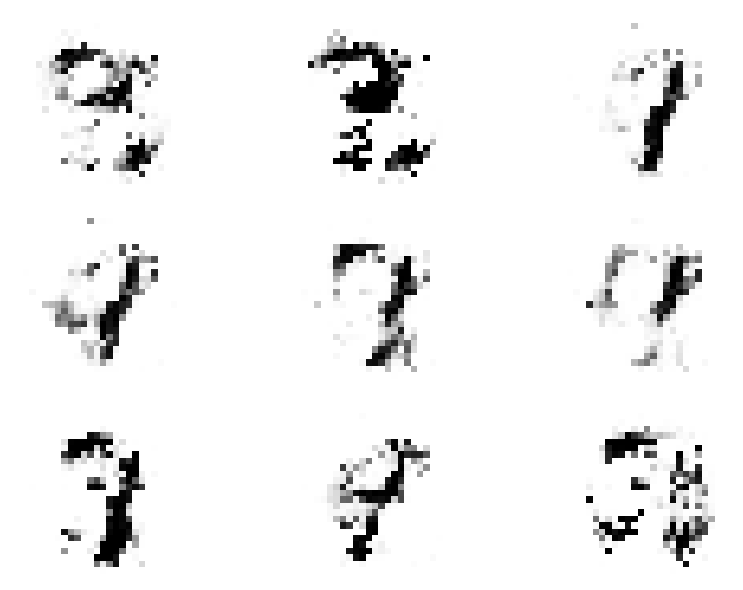

Epoch:405, Step:0, D-Loss:0.030, D-Acc:100.000, G-Loss:4.069, Wasserstein Dist:0.042
Epoch:405, Step:10, D-Loss:0.036, D-Acc:100.000, G-Loss:4.494, Wasserstein Dist:0.044
Epoch:405, Step:20, D-Loss:0.030, D-Acc:100.000, G-Loss:4.432, Wasserstein Dist:0.043
Epoch:405, Step:30, D-Loss:0.038, D-Acc:100.000, G-Loss:4.076, Wasserstein Dist:0.042
Epoch:405, Step:40, D-Loss:0.018, D-Acc:100.000, G-Loss:4.403, Wasserstein Dist:0.045
Epoch:406, Step:0, D-Loss:0.028, D-Acc:100.000, G-Loss:4.455, Wasserstein Dist:0.042
Epoch:406, Step:10, D-Loss:0.049, D-Acc:100.000, G-Loss:4.339, Wasserstein Dist:0.043
Epoch:406, Step:20, D-Loss:0.047, D-Acc:100.000, G-Loss:4.172, Wasserstein Dist:0.042
Epoch:406, Step:30, D-Loss:0.032, D-Acc:100.000, G-Loss:4.152, Wasserstein Dist:0.041
Epoch:406, Step:40, D-Loss:0.041, D-Acc:100.000, G-Loss:4.303, Wasserstein Dist:0.044
Epoch:407, Step:0, D-Loss:0.037, D-Acc:100.000, G-Loss:4.505, Wasserstein Dist:0.044
Epoch:407, Step:10, D-Loss:0.036, D-Acc:100.000, G-Loss:4

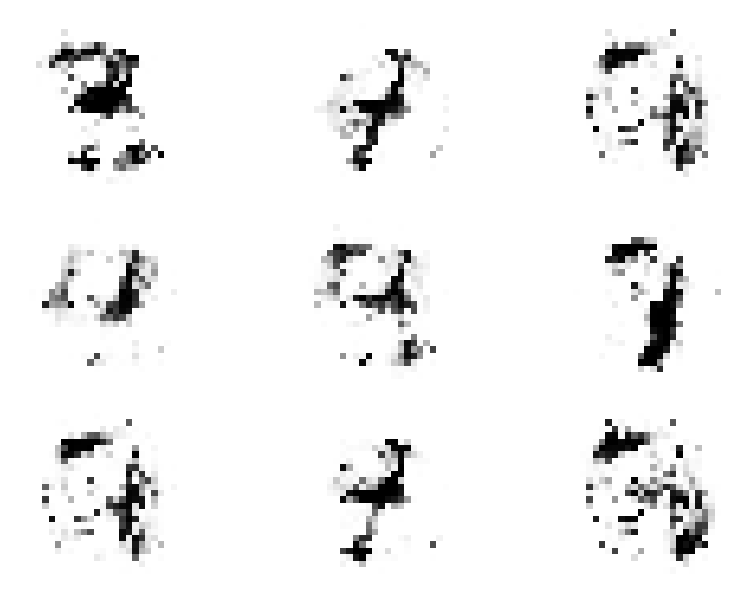

Epoch:410, Step:0, D-Loss:0.043, D-Acc:100.000, G-Loss:4.452, Wasserstein Dist:0.044
Epoch:410, Step:10, D-Loss:0.051, D-Acc:100.000, G-Loss:4.169, Wasserstein Dist:0.045
Epoch:410, Step:20, D-Loss:0.038, D-Acc:100.000, G-Loss:4.383, Wasserstein Dist:0.042
Epoch:410, Step:30, D-Loss:0.019, D-Acc:100.000, G-Loss:4.300, Wasserstein Dist:0.042
Epoch:410, Step:40, D-Loss:0.026, D-Acc:100.000, G-Loss:4.697, Wasserstein Dist:0.043
Epoch:411, Step:0, D-Loss:0.032, D-Acc:100.000, G-Loss:4.745, Wasserstein Dist:0.044
Epoch:411, Step:10, D-Loss:0.024, D-Acc:100.000, G-Loss:4.447, Wasserstein Dist:0.043
Epoch:411, Step:20, D-Loss:0.053, D-Acc:100.000, G-Loss:4.286, Wasserstein Dist:0.042
Epoch:411, Step:30, D-Loss:0.038, D-Acc:100.000, G-Loss:4.473, Wasserstein Dist:0.044
Epoch:411, Step:40, D-Loss:0.035, D-Acc:100.000, G-Loss:4.497, Wasserstein Dist:0.045
Epoch:412, Step:0, D-Loss:0.072, D-Acc:98.333, G-Loss:4.479, Wasserstein Dist:0.043
Epoch:412, Step:10, D-Loss:0.026, D-Acc:100.000, G-Loss:4.

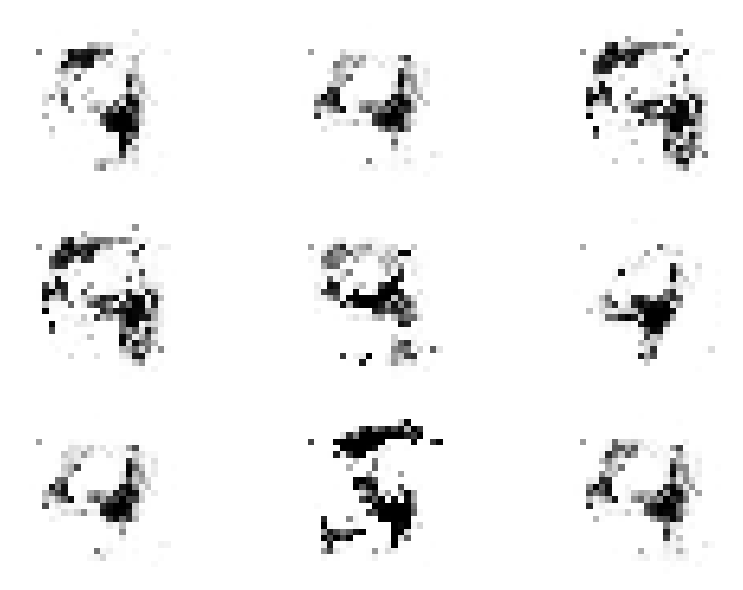

Epoch:415, Step:0, D-Loss:0.032, D-Acc:100.000, G-Loss:4.114, Wasserstein Dist:0.038
Epoch:415, Step:10, D-Loss:0.027, D-Acc:100.000, G-Loss:4.548, Wasserstein Dist:0.038
Epoch:415, Step:20, D-Loss:0.051, D-Acc:100.000, G-Loss:4.283, Wasserstein Dist:0.039
Epoch:415, Step:30, D-Loss:0.021, D-Acc:100.000, G-Loss:4.648, Wasserstein Dist:0.037
Epoch:415, Step:40, D-Loss:0.024, D-Acc:100.000, G-Loss:4.487, Wasserstein Dist:0.035
Epoch:416, Step:0, D-Loss:0.022, D-Acc:100.000, G-Loss:4.470, Wasserstein Dist:0.038
Epoch:416, Step:10, D-Loss:0.035, D-Acc:100.000, G-Loss:4.331, Wasserstein Dist:0.035
Epoch:416, Step:20, D-Loss:0.035, D-Acc:100.000, G-Loss:4.460, Wasserstein Dist:0.034
Epoch:416, Step:30, D-Loss:0.210, D-Acc:96.667, G-Loss:4.364, Wasserstein Dist:0.035
Epoch:416, Step:40, D-Loss:0.070, D-Acc:98.333, G-Loss:3.987, Wasserstein Dist:0.035
Epoch:417, Step:0, D-Loss:0.027, D-Acc:100.000, G-Loss:4.298, Wasserstein Dist:0.034
Epoch:417, Step:10, D-Loss:0.016, D-Acc:100.000, G-Loss:4.3

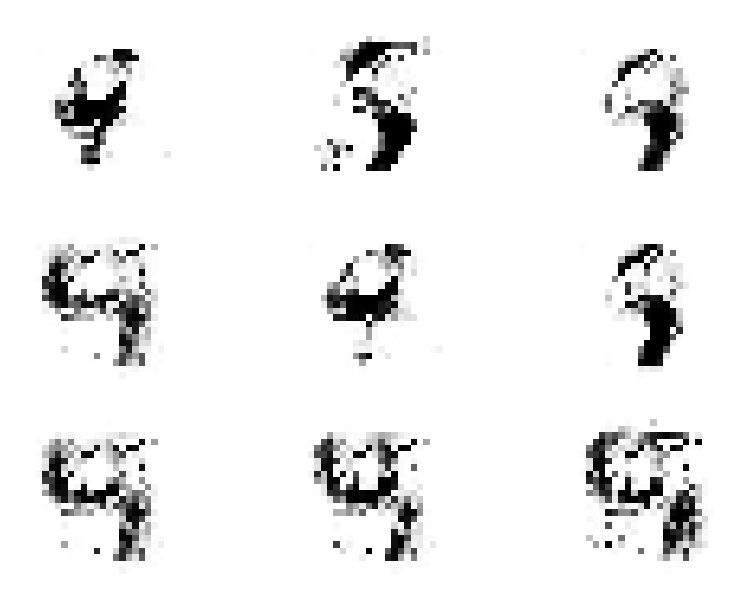

Epoch:420, Step:0, D-Loss:0.027, D-Acc:100.000, G-Loss:4.104, Wasserstein Dist:0.029
Epoch:420, Step:10, D-Loss:0.034, D-Acc:100.000, G-Loss:4.610, Wasserstein Dist:0.031
Epoch:420, Step:20, D-Loss:0.038, D-Acc:100.000, G-Loss:4.715, Wasserstein Dist:0.034
Epoch:420, Step:30, D-Loss:0.051, D-Acc:100.000, G-Loss:4.423, Wasserstein Dist:0.032
Epoch:420, Step:40, D-Loss:0.158, D-Acc:98.333, G-Loss:3.879, Wasserstein Dist:0.032
Epoch:421, Step:0, D-Loss:0.027, D-Acc:100.000, G-Loss:4.129, Wasserstein Dist:0.031
Epoch:421, Step:10, D-Loss:0.050, D-Acc:98.333, G-Loss:4.585, Wasserstein Dist:0.030
Epoch:421, Step:20, D-Loss:0.024, D-Acc:100.000, G-Loss:4.342, Wasserstein Dist:0.031
Epoch:421, Step:30, D-Loss:0.054, D-Acc:100.000, G-Loss:4.414, Wasserstein Dist:0.030
Epoch:421, Step:40, D-Loss:0.031, D-Acc:100.000, G-Loss:4.150, Wasserstein Dist:0.034
Epoch:422, Step:0, D-Loss:0.048, D-Acc:100.000, G-Loss:4.292, Wasserstein Dist:0.033
Epoch:422, Step:10, D-Loss:0.068, D-Acc:100.000, G-Loss:3.9

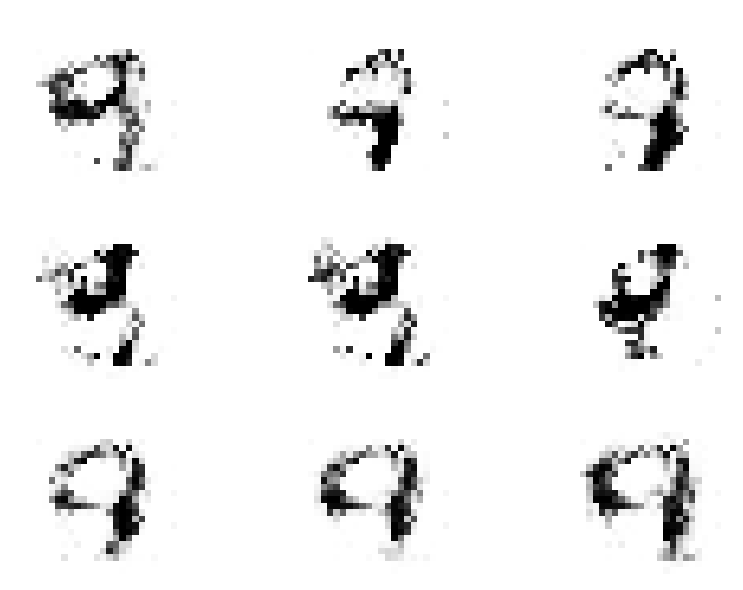

Epoch:425, Step:0, D-Loss:0.045, D-Acc:100.000, G-Loss:4.162, Wasserstein Dist:0.028
Epoch:425, Step:10, D-Loss:0.047, D-Acc:100.000, G-Loss:3.978, Wasserstein Dist:0.029
Epoch:425, Step:20, D-Loss:0.038, D-Acc:100.000, G-Loss:4.403, Wasserstein Dist:0.027
Epoch:425, Step:30, D-Loss:0.033, D-Acc:100.000, G-Loss:4.022, Wasserstein Dist:0.028
Epoch:425, Step:40, D-Loss:0.029, D-Acc:100.000, G-Loss:4.061, Wasserstein Dist:0.028
Epoch:426, Step:0, D-Loss:0.065, D-Acc:98.333, G-Loss:4.233, Wasserstein Dist:0.025
Epoch:426, Step:10, D-Loss:0.048, D-Acc:100.000, G-Loss:4.246, Wasserstein Dist:0.028
Epoch:426, Step:20, D-Loss:0.049, D-Acc:100.000, G-Loss:4.479, Wasserstein Dist:0.027
Epoch:426, Step:30, D-Loss:0.038, D-Acc:100.000, G-Loss:4.081, Wasserstein Dist:0.029
Epoch:426, Step:40, D-Loss:0.046, D-Acc:100.000, G-Loss:4.108, Wasserstein Dist:0.025
Epoch:427, Step:0, D-Loss:0.057, D-Acc:100.000, G-Loss:4.232, Wasserstein Dist:0.027
Epoch:427, Step:10, D-Loss:0.036, D-Acc:100.000, G-Loss:3.

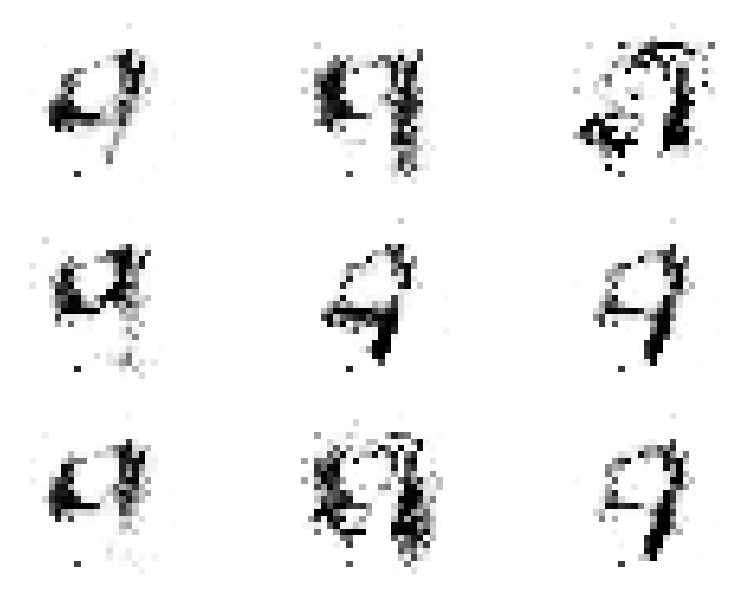

Epoch:430, Step:0, D-Loss:0.090, D-Acc:96.667, G-Loss:4.410, Wasserstein Dist:0.024
Epoch:430, Step:10, D-Loss:0.034, D-Acc:100.000, G-Loss:4.410, Wasserstein Dist:0.027
Epoch:430, Step:20, D-Loss:0.030, D-Acc:100.000, G-Loss:4.035, Wasserstein Dist:0.027
Epoch:430, Step:30, D-Loss:0.044, D-Acc:100.000, G-Loss:4.338, Wasserstein Dist:0.026
Epoch:430, Step:40, D-Loss:0.025, D-Acc:100.000, G-Loss:4.142, Wasserstein Dist:0.022
Epoch:431, Step:0, D-Loss:0.033, D-Acc:100.000, G-Loss:4.063, Wasserstein Dist:0.028
Epoch:431, Step:10, D-Loss:0.023, D-Acc:100.000, G-Loss:4.668, Wasserstein Dist:0.025
Epoch:431, Step:20, D-Loss:0.041, D-Acc:100.000, G-Loss:4.674, Wasserstein Dist:0.027
Epoch:431, Step:30, D-Loss:0.024, D-Acc:100.000, G-Loss:4.510, Wasserstein Dist:0.025
Epoch:431, Step:40, D-Loss:0.046, D-Acc:100.000, G-Loss:4.569, Wasserstein Dist:0.026
Epoch:432, Step:0, D-Loss:0.036, D-Acc:100.000, G-Loss:4.383, Wasserstein Dist:0.023
Epoch:432, Step:10, D-Loss:0.036, D-Acc:100.000, G-Loss:4.

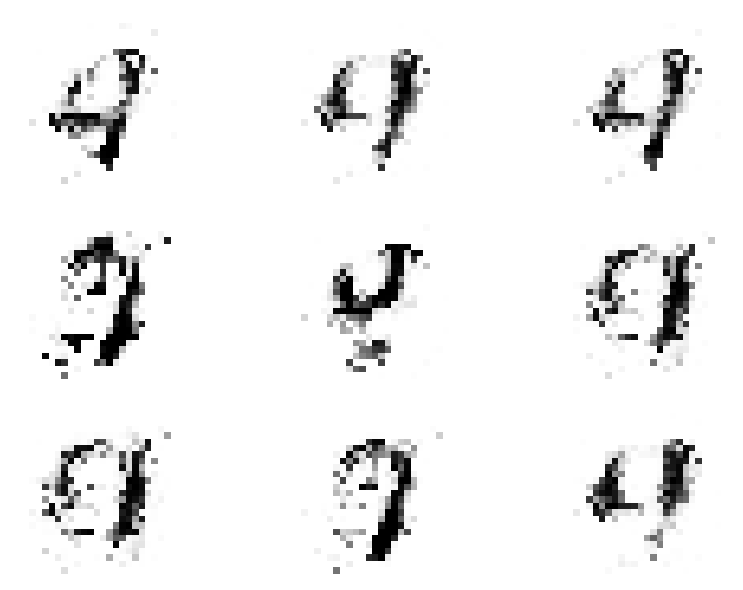

Epoch:435, Step:0, D-Loss:0.037, D-Acc:100.000, G-Loss:4.280, Wasserstein Dist:0.025
Epoch:435, Step:10, D-Loss:0.017, D-Acc:100.000, G-Loss:4.531, Wasserstein Dist:0.024
Epoch:435, Step:20, D-Loss:0.017, D-Acc:100.000, G-Loss:4.671, Wasserstein Dist:0.026
Epoch:435, Step:30, D-Loss:0.018, D-Acc:100.000, G-Loss:4.675, Wasserstein Dist:0.025
Epoch:435, Step:40, D-Loss:0.031, D-Acc:100.000, G-Loss:4.500, Wasserstein Dist:0.024
Epoch:436, Step:0, D-Loss:0.098, D-Acc:98.333, G-Loss:4.523, Wasserstein Dist:0.025
Epoch:436, Step:10, D-Loss:0.120, D-Acc:98.333, G-Loss:4.341, Wasserstein Dist:0.025
Epoch:436, Step:20, D-Loss:0.061, D-Acc:98.333, G-Loss:4.498, Wasserstein Dist:0.023
Epoch:436, Step:30, D-Loss:0.024, D-Acc:100.000, G-Loss:4.823, Wasserstein Dist:0.025
Epoch:436, Step:40, D-Loss:0.034, D-Acc:100.000, G-Loss:4.218, Wasserstein Dist:0.024
Epoch:437, Step:0, D-Loss:0.031, D-Acc:100.000, G-Loss:4.509, Wasserstein Dist:0.025
Epoch:437, Step:10, D-Loss:0.026, D-Acc:100.000, G-Loss:4.54

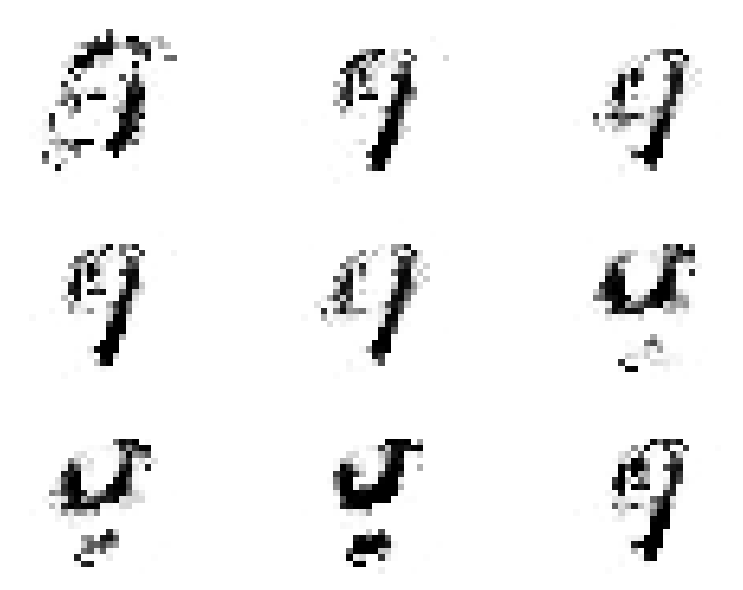

Epoch:440, Step:0, D-Loss:0.033, D-Acc:100.000, G-Loss:4.801, Wasserstein Dist:0.029
Epoch:440, Step:10, D-Loss:0.018, D-Acc:100.000, G-Loss:5.016, Wasserstein Dist:0.028
Epoch:440, Step:20, D-Loss:0.026, D-Acc:100.000, G-Loss:5.008, Wasserstein Dist:0.029
Epoch:440, Step:30, D-Loss:0.022, D-Acc:100.000, G-Loss:4.671, Wasserstein Dist:0.027
Epoch:440, Step:40, D-Loss:0.014, D-Acc:100.000, G-Loss:4.664, Wasserstein Dist:0.028
Epoch:441, Step:0, D-Loss:0.050, D-Acc:98.333, G-Loss:4.491, Wasserstein Dist:0.030
Epoch:441, Step:10, D-Loss:0.048, D-Acc:100.000, G-Loss:4.842, Wasserstein Dist:0.031
Epoch:441, Step:20, D-Loss:0.079, D-Acc:98.333, G-Loss:4.682, Wasserstein Dist:0.028
Epoch:441, Step:30, D-Loss:0.058, D-Acc:98.333, G-Loss:4.695, Wasserstein Dist:0.029
Epoch:441, Step:40, D-Loss:0.025, D-Acc:100.000, G-Loss:4.730, Wasserstein Dist:0.030
Epoch:442, Step:0, D-Loss:0.026, D-Acc:100.000, G-Loss:4.954, Wasserstein Dist:0.029
Epoch:442, Step:10, D-Loss:0.042, D-Acc:100.000, G-Loss:4.24

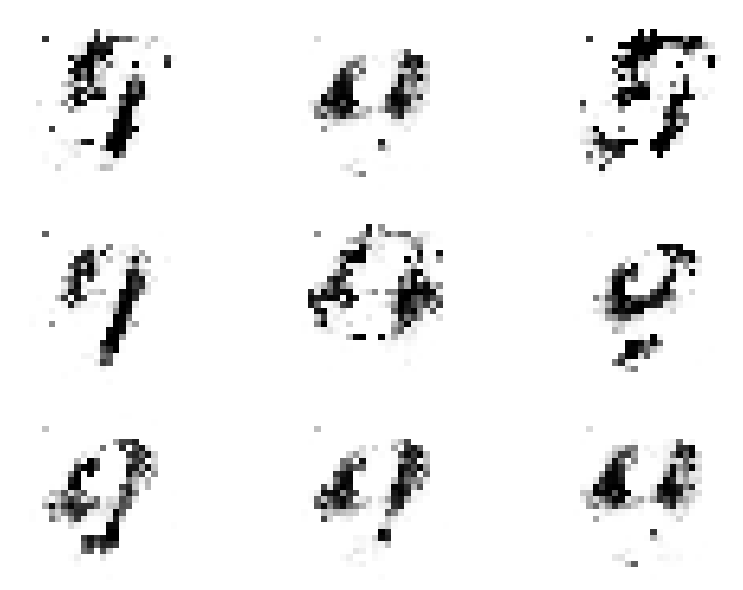

Epoch:445, Step:0, D-Loss:0.061, D-Acc:100.000, G-Loss:4.184, Wasserstein Dist:0.030
Epoch:445, Step:10, D-Loss:0.051, D-Acc:100.000, G-Loss:4.508, Wasserstein Dist:0.030
Epoch:445, Step:20, D-Loss:0.030, D-Acc:100.000, G-Loss:4.626, Wasserstein Dist:0.029
Epoch:445, Step:30, D-Loss:0.031, D-Acc:100.000, G-Loss:4.802, Wasserstein Dist:0.028
Epoch:445, Step:40, D-Loss:0.023, D-Acc:100.000, G-Loss:4.310, Wasserstein Dist:0.030
Epoch:446, Step:0, D-Loss:0.048, D-Acc:100.000, G-Loss:4.757, Wasserstein Dist:0.028
Epoch:446, Step:10, D-Loss:0.025, D-Acc:100.000, G-Loss:4.608, Wasserstein Dist:0.029
Epoch:446, Step:20, D-Loss:0.119, D-Acc:98.333, G-Loss:4.767, Wasserstein Dist:0.028
Epoch:446, Step:30, D-Loss:0.027, D-Acc:100.000, G-Loss:4.744, Wasserstein Dist:0.027
Epoch:446, Step:40, D-Loss:0.014, D-Acc:100.000, G-Loss:5.009, Wasserstein Dist:0.028
Epoch:447, Step:0, D-Loss:0.060, D-Acc:98.333, G-Loss:4.466, Wasserstein Dist:0.030
Epoch:447, Step:10, D-Loss:0.020, D-Acc:100.000, G-Loss:4.9

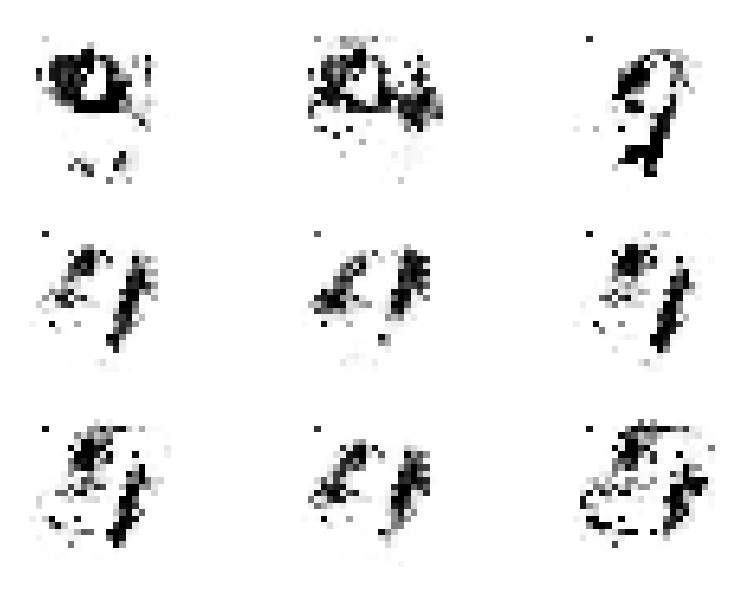

Epoch:450, Step:0, D-Loss:0.062, D-Acc:98.333, G-Loss:4.981, Wasserstein Dist:0.026
Epoch:450, Step:10, D-Loss:0.041, D-Acc:98.333, G-Loss:5.096, Wasserstein Dist:0.028
Epoch:450, Step:20, D-Loss:0.014, D-Acc:100.000, G-Loss:4.985, Wasserstein Dist:0.025
Epoch:450, Step:30, D-Loss:0.029, D-Acc:100.000, G-Loss:4.797, Wasserstein Dist:0.027
Epoch:450, Step:40, D-Loss:0.014, D-Acc:100.000, G-Loss:4.683, Wasserstein Dist:0.026
Epoch:451, Step:0, D-Loss:0.017, D-Acc:100.000, G-Loss:4.614, Wasserstein Dist:0.027
Epoch:451, Step:10, D-Loss:0.023, D-Acc:100.000, G-Loss:5.083, Wasserstein Dist:0.027
Epoch:451, Step:20, D-Loss:0.030, D-Acc:100.000, G-Loss:4.820, Wasserstein Dist:0.027
Epoch:451, Step:30, D-Loss:0.033, D-Acc:100.000, G-Loss:4.956, Wasserstein Dist:0.028
Epoch:451, Step:40, D-Loss:0.031, D-Acc:100.000, G-Loss:4.910, Wasserstein Dist:0.026
Epoch:452, Step:0, D-Loss:0.016, D-Acc:100.000, G-Loss:4.860, Wasserstein Dist:0.024
Epoch:452, Step:10, D-Loss:0.016, D-Acc:100.000, G-Loss:4.7

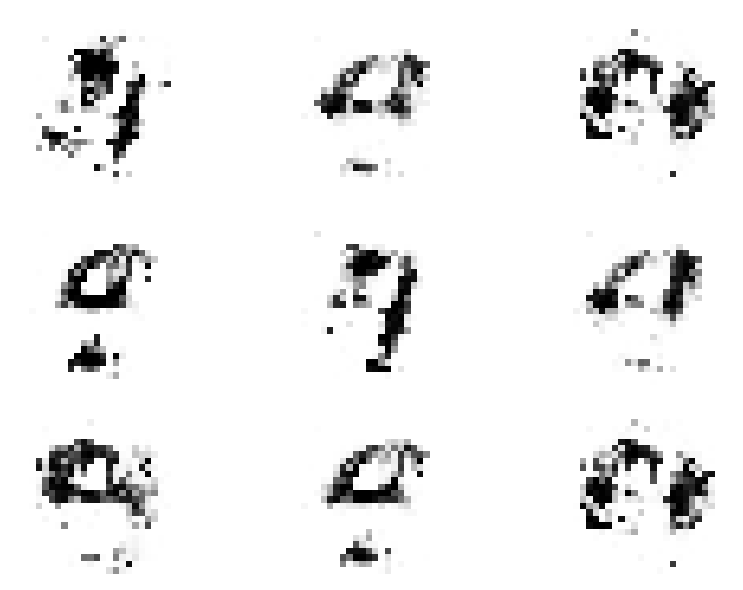

Epoch:455, Step:0, D-Loss:0.076, D-Acc:98.333, G-Loss:4.837, Wasserstein Dist:0.026
Epoch:455, Step:10, D-Loss:0.028, D-Acc:100.000, G-Loss:4.660, Wasserstein Dist:0.025
Epoch:455, Step:20, D-Loss:0.130, D-Acc:98.333, G-Loss:4.524, Wasserstein Dist:0.027
Epoch:455, Step:30, D-Loss:0.023, D-Acc:100.000, G-Loss:4.615, Wasserstein Dist:0.028
Epoch:455, Step:40, D-Loss:0.016, D-Acc:100.000, G-Loss:4.430, Wasserstein Dist:0.025
Epoch:456, Step:0, D-Loss:0.039, D-Acc:100.000, G-Loss:4.496, Wasserstein Dist:0.024
Epoch:456, Step:10, D-Loss:0.032, D-Acc:100.000, G-Loss:4.841, Wasserstein Dist:0.025
Epoch:456, Step:20, D-Loss:0.047, D-Acc:100.000, G-Loss:4.916, Wasserstein Dist:0.027
Epoch:456, Step:30, D-Loss:0.079, D-Acc:98.333, G-Loss:4.792, Wasserstein Dist:0.026
Epoch:456, Step:40, D-Loss:0.031, D-Acc:100.000, G-Loss:4.413, Wasserstein Dist:0.028
Epoch:457, Step:0, D-Loss:0.042, D-Acc:100.000, G-Loss:4.256, Wasserstein Dist:0.026
Epoch:457, Step:10, D-Loss:0.040, D-Acc:100.000, G-Loss:4.71

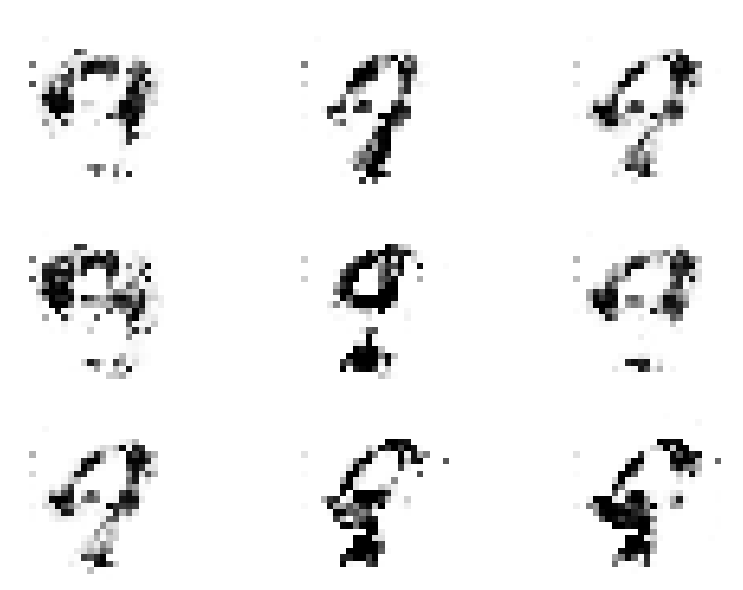

Epoch:460, Step:0, D-Loss:0.033, D-Acc:100.000, G-Loss:4.387, Wasserstein Dist:0.024
Epoch:460, Step:10, D-Loss:0.018, D-Acc:100.000, G-Loss:4.715, Wasserstein Dist:0.025
Epoch:460, Step:20, D-Loss:0.137, D-Acc:98.333, G-Loss:4.745, Wasserstein Dist:0.026
Epoch:460, Step:30, D-Loss:0.020, D-Acc:100.000, G-Loss:4.421, Wasserstein Dist:0.028
Epoch:460, Step:40, D-Loss:0.016, D-Acc:100.000, G-Loss:4.796, Wasserstein Dist:0.027
Epoch:461, Step:0, D-Loss:0.023, D-Acc:100.000, G-Loss:4.984, Wasserstein Dist:0.028
Epoch:461, Step:10, D-Loss:0.025, D-Acc:100.000, G-Loss:4.957, Wasserstein Dist:0.031
Epoch:461, Step:20, D-Loss:0.017, D-Acc:100.000, G-Loss:4.904, Wasserstein Dist:0.027
Epoch:461, Step:30, D-Loss:0.012, D-Acc:100.000, G-Loss:5.197, Wasserstein Dist:0.029
Epoch:461, Step:40, D-Loss:0.032, D-Acc:100.000, G-Loss:4.789, Wasserstein Dist:0.029
Epoch:462, Step:0, D-Loss:0.029, D-Acc:100.000, G-Loss:4.553, Wasserstein Dist:0.030
Epoch:462, Step:10, D-Loss:0.019, D-Acc:100.000, G-Loss:4.

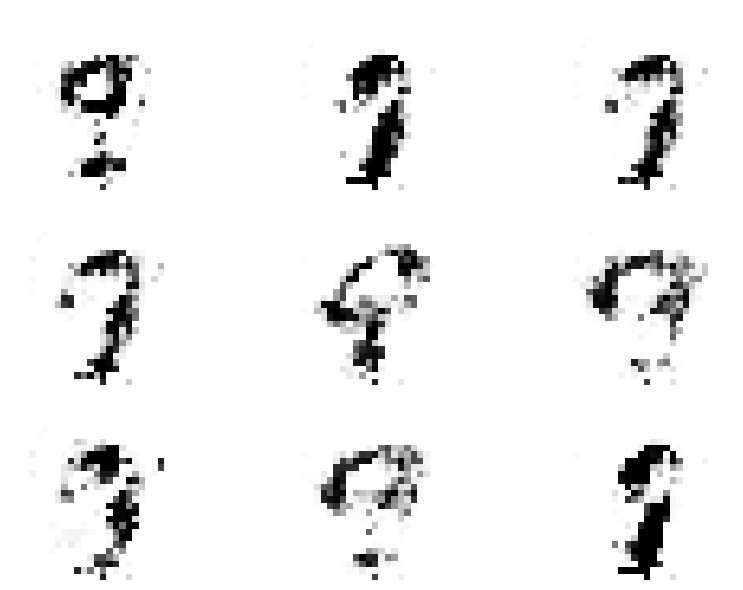

Epoch:465, Step:0, D-Loss:0.048, D-Acc:98.333, G-Loss:5.169, Wasserstein Dist:0.031
Epoch:465, Step:10, D-Loss:0.027, D-Acc:100.000, G-Loss:4.990, Wasserstein Dist:0.035
Epoch:465, Step:20, D-Loss:0.020, D-Acc:100.000, G-Loss:4.923, Wasserstein Dist:0.032
Epoch:465, Step:30, D-Loss:0.023, D-Acc:100.000, G-Loss:4.878, Wasserstein Dist:0.033
Epoch:465, Step:40, D-Loss:0.061, D-Acc:98.333, G-Loss:4.642, Wasserstein Dist:0.031
Epoch:466, Step:0, D-Loss:0.026, D-Acc:100.000, G-Loss:4.328, Wasserstein Dist:0.033
Epoch:466, Step:10, D-Loss:0.015, D-Acc:100.000, G-Loss:4.919, Wasserstein Dist:0.032
Epoch:466, Step:20, D-Loss:0.025, D-Acc:100.000, G-Loss:4.528, Wasserstein Dist:0.032
Epoch:466, Step:30, D-Loss:0.030, D-Acc:100.000, G-Loss:4.766, Wasserstein Dist:0.034
Epoch:466, Step:40, D-Loss:0.018, D-Acc:100.000, G-Loss:4.959, Wasserstein Dist:0.034
Epoch:467, Step:0, D-Loss:0.026, D-Acc:100.000, G-Loss:4.535, Wasserstein Dist:0.035
Epoch:467, Step:10, D-Loss:0.041, D-Acc:100.000, G-Loss:4.6

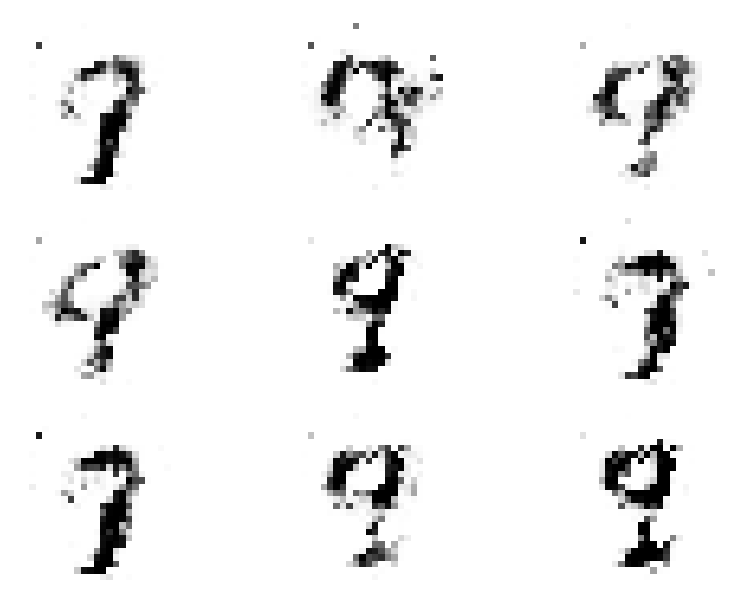

Epoch:470, Step:0, D-Loss:0.035, D-Acc:100.000, G-Loss:4.513, Wasserstein Dist:0.035
Epoch:470, Step:10, D-Loss:0.055, D-Acc:100.000, G-Loss:4.300, Wasserstein Dist:0.034
Epoch:470, Step:20, D-Loss:0.057, D-Acc:98.333, G-Loss:4.170, Wasserstein Dist:0.036
Epoch:470, Step:30, D-Loss:0.158, D-Acc:98.333, G-Loss:3.790, Wasserstein Dist:0.035
Epoch:470, Step:40, D-Loss:0.038, D-Acc:100.000, G-Loss:3.719, Wasserstein Dist:0.033
Epoch:471, Step:0, D-Loss:0.030, D-Acc:100.000, G-Loss:4.203, Wasserstein Dist:0.033
Epoch:471, Step:10, D-Loss:0.057, D-Acc:100.000, G-Loss:4.399, Wasserstein Dist:0.033
Epoch:471, Step:20, D-Loss:0.094, D-Acc:98.333, G-Loss:4.202, Wasserstein Dist:0.039
Epoch:471, Step:30, D-Loss:0.150, D-Acc:98.333, G-Loss:3.799, Wasserstein Dist:0.035
Epoch:471, Step:40, D-Loss:0.028, D-Acc:100.000, G-Loss:4.128, Wasserstein Dist:0.037
Epoch:472, Step:0, D-Loss:0.070, D-Acc:100.000, G-Loss:4.012, Wasserstein Dist:0.038
Epoch:472, Step:10, D-Loss:0.077, D-Acc:98.333, G-Loss:3.917,

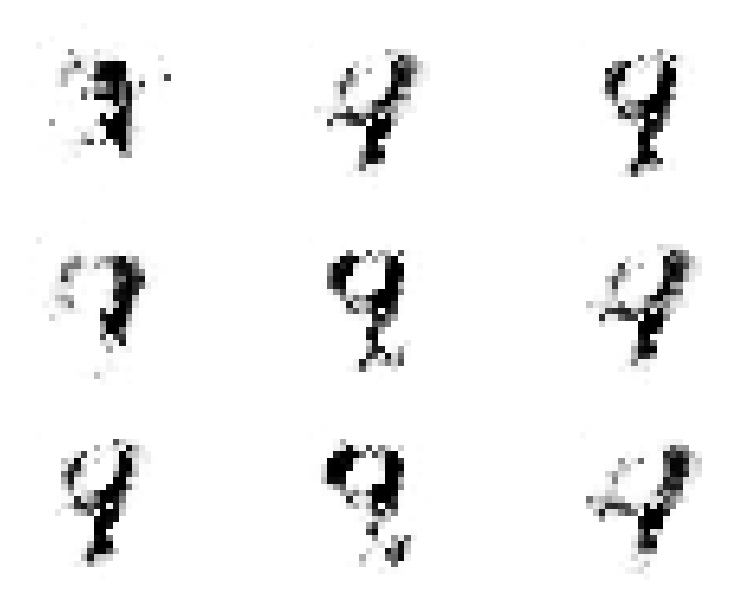

Epoch:475, Step:0, D-Loss:0.043, D-Acc:100.000, G-Loss:3.960, Wasserstein Dist:0.042
Epoch:475, Step:10, D-Loss:0.043, D-Acc:100.000, G-Loss:3.980, Wasserstein Dist:0.043
Epoch:475, Step:20, D-Loss:0.032, D-Acc:100.000, G-Loss:3.876, Wasserstein Dist:0.043
Epoch:475, Step:30, D-Loss:0.053, D-Acc:100.000, G-Loss:4.253, Wasserstein Dist:0.044
Epoch:475, Step:40, D-Loss:0.056, D-Acc:98.333, G-Loss:4.077, Wasserstein Dist:0.044
Epoch:476, Step:0, D-Loss:0.088, D-Acc:98.333, G-Loss:3.982, Wasserstein Dist:0.044
Epoch:476, Step:10, D-Loss:0.036, D-Acc:100.000, G-Loss:4.422, Wasserstein Dist:0.046
Epoch:476, Step:20, D-Loss:0.035, D-Acc:100.000, G-Loss:4.109, Wasserstein Dist:0.042
Epoch:476, Step:30, D-Loss:0.030, D-Acc:100.000, G-Loss:3.928, Wasserstein Dist:0.042
Epoch:476, Step:40, D-Loss:0.064, D-Acc:100.000, G-Loss:4.089, Wasserstein Dist:0.044
Epoch:477, Step:0, D-Loss:0.065, D-Acc:100.000, G-Loss:4.100, Wasserstein Dist:0.043
Epoch:477, Step:10, D-Loss:0.040, D-Acc:100.000, G-Loss:4.1

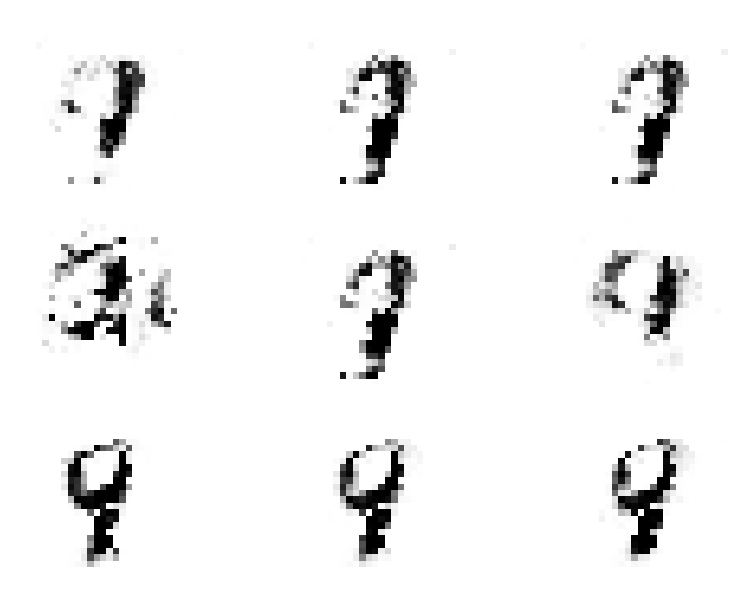

Epoch:480, Step:0, D-Loss:0.082, D-Acc:98.333, G-Loss:4.019, Wasserstein Dist:0.043
Epoch:480, Step:10, D-Loss:0.141, D-Acc:98.333, G-Loss:4.178, Wasserstein Dist:0.045
Epoch:480, Step:20, D-Loss:0.042, D-Acc:98.333, G-Loss:4.392, Wasserstein Dist:0.042
Epoch:480, Step:30, D-Loss:0.034, D-Acc:100.000, G-Loss:4.338, Wasserstein Dist:0.044
Epoch:480, Step:40, D-Loss:0.090, D-Acc:98.333, G-Loss:3.962, Wasserstein Dist:0.046
Epoch:481, Step:0, D-Loss:0.040, D-Acc:100.000, G-Loss:4.171, Wasserstein Dist:0.045
Epoch:481, Step:10, D-Loss:0.035, D-Acc:100.000, G-Loss:4.302, Wasserstein Dist:0.041
Epoch:481, Step:20, D-Loss:0.108, D-Acc:98.333, G-Loss:4.126, Wasserstein Dist:0.043
Epoch:481, Step:30, D-Loss:0.029, D-Acc:100.000, G-Loss:4.602, Wasserstein Dist:0.044
Epoch:481, Step:40, D-Loss:0.016, D-Acc:100.000, G-Loss:4.457, Wasserstein Dist:0.042
Epoch:482, Step:0, D-Loss:0.105, D-Acc:98.333, G-Loss:4.693, Wasserstein Dist:0.042
Epoch:482, Step:10, D-Loss:0.076, D-Acc:98.333, G-Loss:4.393, W

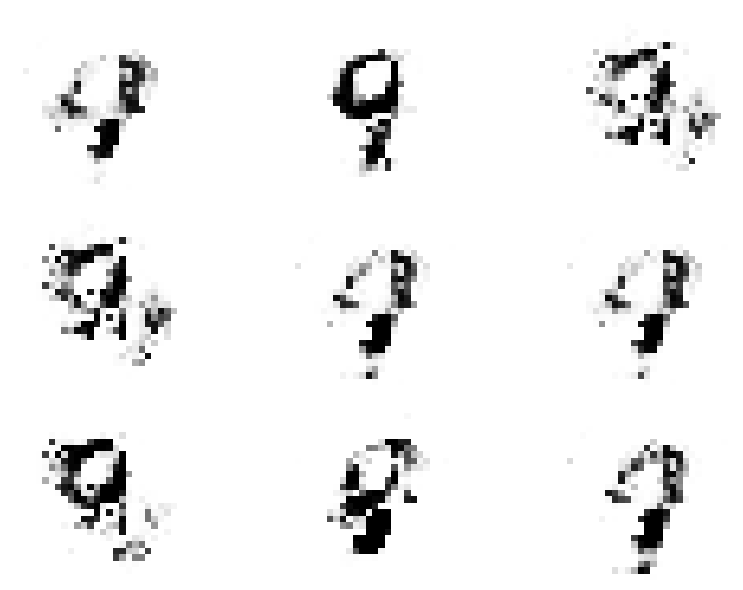

Epoch:485, Step:0, D-Loss:0.031, D-Acc:100.000, G-Loss:4.354, Wasserstein Dist:0.040
Epoch:485, Step:10, D-Loss:0.116, D-Acc:98.333, G-Loss:4.408, Wasserstein Dist:0.045
Epoch:485, Step:20, D-Loss:0.040, D-Acc:100.000, G-Loss:4.271, Wasserstein Dist:0.041
Epoch:485, Step:30, D-Loss:0.063, D-Acc:100.000, G-Loss:4.192, Wasserstein Dist:0.043
Epoch:485, Step:40, D-Loss:0.065, D-Acc:98.333, G-Loss:4.199, Wasserstein Dist:0.043
Epoch:486, Step:0, D-Loss:0.086, D-Acc:98.333, G-Loss:4.175, Wasserstein Dist:0.042
Epoch:486, Step:10, D-Loss:0.086, D-Acc:98.333, G-Loss:4.379, Wasserstein Dist:0.040
Epoch:486, Step:20, D-Loss:0.063, D-Acc:98.333, G-Loss:4.336, Wasserstein Dist:0.040
Epoch:486, Step:30, D-Loss:0.018, D-Acc:100.000, G-Loss:4.692, Wasserstein Dist:0.040
Epoch:486, Step:40, D-Loss:0.043, D-Acc:100.000, G-Loss:4.412, Wasserstein Dist:0.039
Epoch:487, Step:0, D-Loss:0.092, D-Acc:100.000, G-Loss:4.168, Wasserstein Dist:0.039
Epoch:487, Step:10, D-Loss:0.049, D-Acc:100.000, G-Loss:4.160,

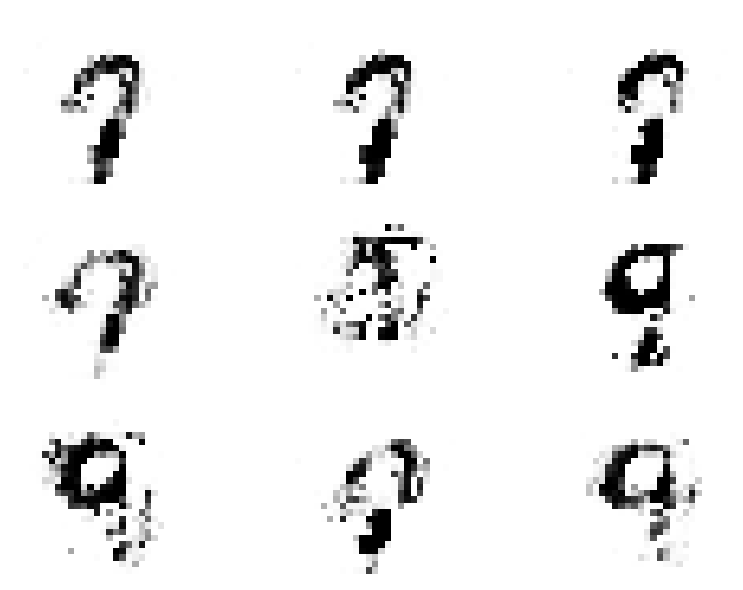

Epoch:490, Step:0, D-Loss:0.043, D-Acc:100.000, G-Loss:4.138, Wasserstein Dist:0.034
Epoch:490, Step:10, D-Loss:0.040, D-Acc:100.000, G-Loss:4.136, Wasserstein Dist:0.032
Epoch:490, Step:20, D-Loss:0.045, D-Acc:100.000, G-Loss:4.332, Wasserstein Dist:0.033
Epoch:490, Step:30, D-Loss:0.073, D-Acc:98.333, G-Loss:4.039, Wasserstein Dist:0.033
Epoch:490, Step:40, D-Loss:0.054, D-Acc:100.000, G-Loss:4.461, Wasserstein Dist:0.031
Epoch:491, Step:0, D-Loss:0.174, D-Acc:96.667, G-Loss:3.994, Wasserstein Dist:0.030
Epoch:491, Step:10, D-Loss:0.035, D-Acc:100.000, G-Loss:4.438, Wasserstein Dist:0.030
Epoch:491, Step:20, D-Loss:0.053, D-Acc:100.000, G-Loss:4.453, Wasserstein Dist:0.031
Epoch:491, Step:30, D-Loss:0.023, D-Acc:100.000, G-Loss:4.522, Wasserstein Dist:0.030
Epoch:491, Step:40, D-Loss:0.036, D-Acc:100.000, G-Loss:3.986, Wasserstein Dist:0.033
Epoch:492, Step:0, D-Loss:0.064, D-Acc:100.000, G-Loss:4.529, Wasserstein Dist:0.034
Epoch:492, Step:10, D-Loss:0.094, D-Acc:98.333, G-Loss:4.26

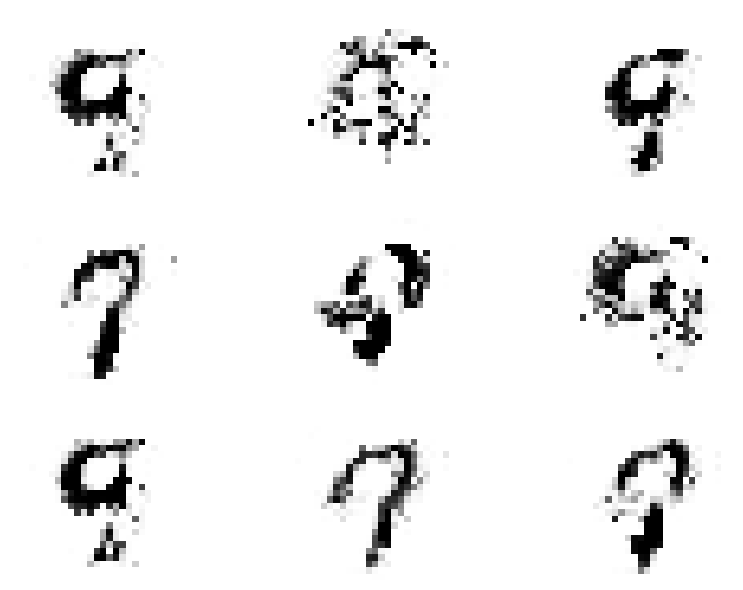

Epoch:495, Step:0, D-Loss:0.061, D-Acc:100.000, G-Loss:4.116, Wasserstein Dist:0.028
Epoch:495, Step:10, D-Loss:0.176, D-Acc:95.000, G-Loss:4.025, Wasserstein Dist:0.029
Epoch:495, Step:20, D-Loss:0.047, D-Acc:100.000, G-Loss:4.052, Wasserstein Dist:0.027
Epoch:495, Step:30, D-Loss:0.046, D-Acc:100.000, G-Loss:4.322, Wasserstein Dist:0.027
Epoch:495, Step:40, D-Loss:0.134, D-Acc:96.667, G-Loss:4.017, Wasserstein Dist:0.030
Epoch:496, Step:0, D-Loss:0.030, D-Acc:100.000, G-Loss:4.091, Wasserstein Dist:0.028
Epoch:496, Step:10, D-Loss:0.057, D-Acc:100.000, G-Loss:4.333, Wasserstein Dist:0.025
Epoch:496, Step:20, D-Loss:0.165, D-Acc:96.667, G-Loss:3.982, Wasserstein Dist:0.027
Epoch:496, Step:30, D-Loss:0.086, D-Acc:98.333, G-Loss:4.466, Wasserstein Dist:0.028
Epoch:496, Step:40, D-Loss:0.057, D-Acc:100.000, G-Loss:4.320, Wasserstein Dist:0.029
Epoch:497, Step:0, D-Loss:0.027, D-Acc:100.000, G-Loss:4.497, Wasserstein Dist:0.030
Epoch:497, Step:10, D-Loss:0.031, D-Acc:100.000, G-Loss:4.687

In [7]:
# 记录损失和Wasserstein距离
losses_d = []
losses_g = []
wasserstein_distances = []

# 训练循环
for i in range(epochs):
    if i % 5 == 0:
        show_generator_results(generator, noise_std)
    
    for j in range(steps):
        # 训练判别器
        discriminator.zero_grad()
        
        # 真实样本
        real_samples = get_real_samples(batch_size//2)
        real_labels = torch.ones(batch_size//2, 1, device=device)
        real_output = discriminator(real_samples)
        d_loss_real = criterion(real_output, real_labels)
        
        # 假样本
        fake_samples = get_fake_samples(generator, batch_size//2, noise_size, noise_std)
        fake_labels = torch.zeros(batch_size//2, 1, device=device)
        fake_output = discriminator(fake_samples)
        d_loss_fake = criterion(fake_output, fake_labels)
        
        # 判别器总损失
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()
        
        # 计算判别器准确度
        d_acc = (torch.sum((real_output > 0.5).float()) + 
                torch.sum((fake_output < 0.5).float())) / (batch_size)
        
        # 训练生成器
        generator.zero_grad()
        
        # 生成新的假样本
        noise = get_random_noise(batch_size, noise_size)
        fake_samples = generator(noise)
        
        # 让判别器认为这些是真实样本
        fake_output = discriminator(fake_samples)
        g_loss = criterion(fake_output, torch.ones(batch_size, 1, device=device))
        
        g_loss.backward()
        optimizer_g.step()
        
        # 记录损失
        losses_d.append(d_loss.item())
        losses_g.append(g_loss.item())
        
        # 每10步计算一次Wasserstein距离
        if j % 10 == 0:
            with torch.no_grad():
                fake_samples_batch = get_fake_samples(generator, 1000, noise_size, noise_std)
                fake_samples_flat = fake_samples_batch.view(-1).cpu().numpy()
                
                real_samples_batch = get_real_samples(1000)
                real_samples_flat = real_samples_batch.view(-1).cpu().numpy()
                
                wasserstein_dist = wasserstein_distance(fake_samples_flat, real_samples_flat)
                wasserstein_distances.append(wasserstein_dist)
                
                print(f"Epoch:{i}, Step:{j}, D-Loss:{d_loss.item():.3f}, D-Acc:{d_acc.item()*100:.3f}, G-Loss:{g_loss.item():.3f}, Wasserstein Dist:{wasserstein_dist:.3f}")
    
    # 更新噪声强度
    if i > 0 and len(wasserstein_distances) > 1:
        prev_wasserstein_dist = wasserstein_distances[-2]
        current_wasserstein_dist = wasserstein_distances[-1]
        delta_wasserstein = abs(prev_wasserstein_dist - current_wasserstein_dist)
        
        if delta_wasserstein < noise_change_threshold:
            if noise_std < noise_std_max:
                noise_std *= noise_increase_factor
        else:
            if noise_std > noise_std_min:
                noise_std *= noise_decrease_factor
        
        noise_std = min(max(noise_std, noise_std_min), noise_std_max)

# 输出最佳噪声强度
print(f"Best Noise Std: {noise_std:.4f}")

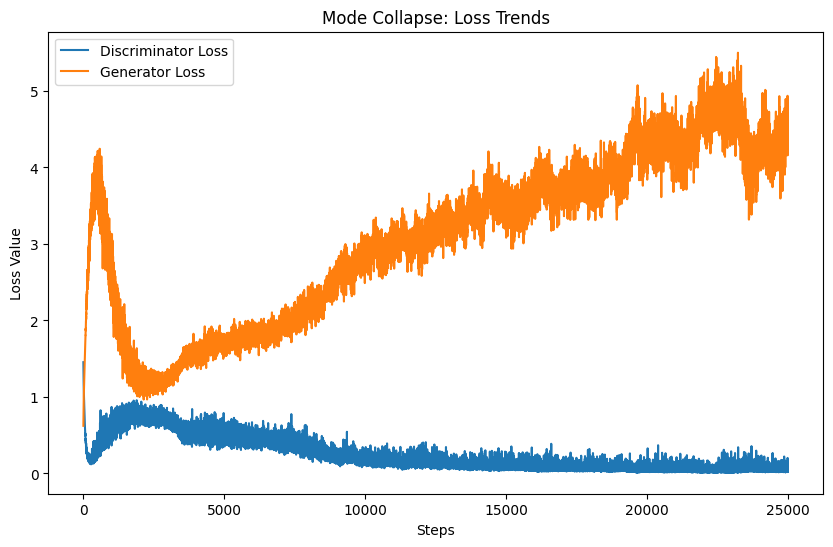

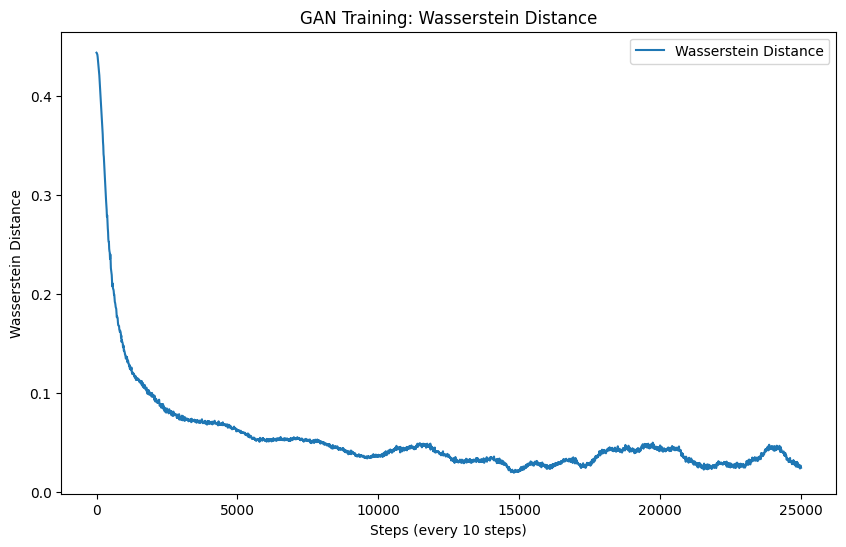

In [8]:
# 绘制损失曲线
steps = [i for i in range(len(losses_d))]
plt.figure(figsize=(10, 6))
plt.plot(losses_d)
plt.plot(losses_g)
plt.xlabel('Steps')
plt.ylabel('Loss Value')
plt.title("Mode Collapse: Loss Trends")
plt.legend(['Discriminator Loss', 'Generator Loss'])
plt.show()

# 绘制Wasserstein距离曲线
plt.figure(figsize=(10, 6))
plt.plot(range(0, len(wasserstein_distances)*10, 10), wasserstein_distances, label='Wasserstein Distance')
plt.xlabel('Steps (every 10 steps)')
plt.ylabel('Wasserstein Distance')
plt.title("GAN Training: Wasserstein Distance")
plt.legend()
plt.show()